# STRATA — Marco práctico: ¿aporta valor supervisar estadísticamente a un agente LLM de trading?

**Notebook DEFINITIVO y canónico del TFG** (Raquel García, Matemáticas y Ciencia de Datos, UCM).

**Tesis.** Un agente LLM de trading (AI Hedge Fund, 5 personalidades) puede perder dinero y acertar la dirección
< 50 %. La pregunta no es *"¿la IA acierta?"* sino *"¿una capa de supervisión estadística clásica (STRATA:
régimen, cambio de opinión, volatilidad) **rescata** a ese agente, y puede **probarse**?"*. Se defiende como un
quant ante un comité: se **vende** con el caso SPY, pero se **prueba** con lo que sobrevive a un test, y **cada
decisión va justificada con su material** (tabla/figura/cita).

**Dos supervisores complementarios (el eje del capítulo).** STRATA ofrece una **regla transparente** (M8) que
hace de **capa de riesgo** (rescate de Sharpe significativo) y un **aprendiz flexible** (M10/AutoML) que hace de
**capa de accuracy** (rescate de acierto significativo). No compiten por el mismo trabajo. Qué modelo concreto
lidera por activo **no es predecible**, pero el rescate del aprendiz **escala con el leverage effect** — la única
ley naturaleza→resultado que sobrevive a un test (§5), y el clustering muestra que ese eje de leverage es el que
estructura el panel (§6).

**Alcance y honestidad (lo lleva el cuaderno, no lo esconde).** El listón de STRATA es **el agente, no el
mercado**: es una **capa de supervisión y control de riesgo** que **rescata** a un decisor que pierde, no una
estrategia que bata al mercado (batir al baseline trivial ZeroR/B&H en accuracy es **nominal**, n≈250 → ventana
corta). Generar alfa absoluta queda **fuera de su alcance por diseño** — el listón es el agente, no el mercado.
(La lectura alfa-vs-beta de §7 es **descriptiva** y alimenta una **línea futura**, no una conclusión central.)

Estrategias: **M5** agente · **M8** STRATA-regla (override-C) · **M10** meta-learner XGBoost · **AutoML** (H2O) ·
**ZeroR** clase mayoritaria · **B&H** comprar-y-mantener.

## Objetivos (cada uno con su validación)

| | Objetivo | Validación |
|---|---|---|
| **O1** | El agente solo (M5) pierde y acierta < 0.5 | sign test vs 0.5; Sharpe negativo (§3) |
| **O2** | STRATA **rescata** al agente | McNemar M8/M10/AutoML vs M5 (§3,§4); ΔSharpe/ΔmaxDD bootstrap pooled (§4) |
| **O3** | El ML **redescubre** las señales de STRATA (SHAP) y, por flexibilidad no lineal, **bate modestamente a la regla** en accuracy | cuota SHAP + ablación (§3,§4) + **TOST** equivalencia/superioridad vs M8 (§4) |
| **O4** | **Mecanismo**: dos capas complementarias (regla=riesgo, aprendiz=accuracy) | pooled ΔSharpe (M8) + McNemar (ML) (§5) |
| **O5** | **Ley naturaleza→resultado**: el rescate del aprendiz ∝ leverage | correlación (Pearson/Spearman) + clustering (§5,§6) |
| **O6** | **Alcance: supervisión, no alfa** | listón = el agente; accuracy nominal vs trivial; alfa = línea futura (§7/§8) |
| **O7** | **Rigor** | test+IC+cita; `signal_lag=1`; embargo=1; sin KFold; ex-ante (§1,§2) |

## Notación
| Símbolo | Significado |
|---|---|
| $r_t$, $r_{t+1}$ | log-retorno de hoy / del día siguiente (lo que captura la posición de hoy) |
| $y_t=\mathbb{1}[r_{t+1}>0]$ | etiqueta direccional (horizonte 1) |
| $s_t\in\{$Calma,Estrés,Crisis$\}$ | régimen oculto (HMM K=3); $\gamma_{t,k}=P(s_t{=}k\mid\mathcal F_t)$ filtrado |
| $\sigma_t$ | volatilidad GARCH(1,1)-t (prevista antes de ver $r_t$) |
| $w_t\in\{-1,0,1\}$ | posición; P&L con `signal_lag=1`: $w_t\,r_{t+1}$ |

## Mapa del capítulo
§1 datos/protocolo → §2 mecánica ex-ante → §3 caso SPY → §4 panel de 10 → §5 **mecanismo por activo** →
§6 **clustering (naturaleza→resultado)** → §7 robustez/honestidad → §8 conclusiones.

In [1]:
# --- Bootstrap raíz + carga de TODOS los JSON auditados ---
import os, sys, json, warnings
from pathlib import Path
_ROOT = Path.cwd()
while not (_ROOT / "config.py").exists() and _ROOT != _ROOT.parent:
    _ROOT = _ROOT.parent
os.chdir(_ROOT); sys.path.insert(0, str(_ROOT)); warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

def _load(p): return json.load(open(p))
DP   = _load("outputs/experiments/decision_automl_prep.json")
PAN  = _load("outputs/experiments/automl_runs/panel_mm25_inclGBM-XGB-SE_AUC_emb1_N0-150_step21_kfold_seed42.json")["por_activo"]
IMP  = _load("outputs/experiments/automl_importance.json")["por_activo"]
CLU  = _load("outputs/experiments/strategy_clustering15.json")          # versión de 15 (universo) — conservada como respaldo
CL10 = _load("outputs/experiments/cluster_panel10.json")                # clustering canónico del cuerpo: los 10 + análisis por grupo
ANR  = _load("outputs/experiments/automl_net_returns.json")["por_activo"]
MECH = _load("outputs/experiments/mechanism_panel.json")["por_activo"]
DET  = _load("outputs/experiments/detector_analysis_SPY.json")
DETX = _load("outputs/experiments/detector_analysis_XLE.json")
DETM = _load("outputs/experiments/detector_analysis_MARA.json")
PANROB = _load("outputs/experiments/panel_robustness.json")             # rodante + val/test + bull/bear (panel 10)
KSEL = _load("outputs/experiments/k_selection.json")                    # K=3: verosimilitud held-out (SPY)
KABL = _load("outputs/experiments/k_ablation_panel.json")               # K=3 vs K=2 en el panel
CALW = _load("outputs/experiments/calib_window_panel.json")             # robustez a la ventana de calibración
BBC  = _load("outputs/experiments/bullbear_confirmatory.json")          # PARTE B confirmatoria (ΔSharpe Bonf+DSR) + régimen
REGDID = _load("outputs/experiments/regime_did_learners.json")          # test DiD: ¿la complementariedad por régimen es sig?
EQT  = _load("outputs/experiments/equivalence_tost.json")               # TOST: ¿el aprendiz redescubre la regla o la bate?
ABT  = _load("outputs/experiments/alfa_beta_lectura.json")              # F4.9 lectura alfa-vs-beta (descriptiva, sin test)
SPYR = _load("outputs/experiments/spy_m10_full_report.json")
SPYA = _load("outputs/experiments/spy_ablation_robustness.json")
SMV  = _load("outputs/experiments/m10_smci_valtest_robustez.json")
SME  = _load("outputs/experiments/m10_smci_embargo.json")
SMR  = _load("outputs/experiments/m10_smci_rolling.json")
SMC  = _load("outputs/experiments/smci_calib_window.json")
RDT  = _load("outputs/experiments/regime_direction_table.json")
SPYIV = _load("outputs/experiments/spy_intervention_variants.json")      # SPY: abstención/override + sensibilidad de umbrales
NAT = {a: CLU["por_activo"][a]["nat"] for a in CLU["por_activo"]}        # naturaleza por activo (leverage/crisis/vol/sesgo)
SPYME = _load("outputs/experiments/spy_mechanism_extras.json")           # SPY: daily (régimen/posiciones/p1) + SHAP dependency + cuota rodante
THR = _load("cache/models/strata_thresholds.json")                       # umbrales ex-ante PSA/GSO (calib 2000–2024-09)
DETXLE = _load("outputs/experiments/detector_analysis_XLE.json"); DETMAR = _load("outputs/experiments/detector_analysis_MARA.json")
DETABL = _load("outputs/experiments/detector_ablation_panel.json")        # activación detectores (10) + ablación M10 (SPY)
CONF = _load("outputs/experiments/confusion_panel.json")                  # matrices de confusión SPY (6) + panel (mejor STRATA)
IANA = _load("outputs/experiments/spy_intervention_anatomy.json")         # anatomía de un día de intervención (acierto/fallo)
GATE = _load("outputs/experiments/spy_panel_gate_descriptive.json")       # gate RAM por activo (10) + descriptivo de features SPY

# --- Panel del estudio: 10 activos ---
PANEL10 = ["SPY", "QQQ", "XLF", "DIA", "XLK", "XLE", "ROKU", "SMCI", "MARA", "UNG"]
DPA = DP["por_activo"]
COL = {"M5": "#9e9e9e", "M8": "#f0a830", "M10": "#2c7fb8", "AutoML": "#27ae60", "ZeroR": "#7d3c98", "B&H": "#c0392b"}
REGCOL = {0: "#2e9e4f", 1: "#e8a33d", 2: "#c0392b"}; REGNAME = {0: "Calma", 1: "Estrés", 2: "Crisis"}
PKEY = {"M5": "m5", "M8": "m8", "M10": "m10_xgb", "AutoML": "automl", "ZeroR": "zeror", "B&H": "bh"}
DKEY = {"M5": "m5", "M8": "m8", "M10": "m10", "ZeroR": "zeror", "B&H": "bh"}
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25, "font.size": 10})
print("Panel del estudio: 10 activos ·", ", ".join(PANEL10))

Panel del estudio: 10 activos · SPY, QQQ, XLF, DIA, XLK, XLE, ROKU, SMCI, MARA, UNG


## §1 Datos, universo y protocolo

> *El estudio se hace sobre un **panel de 10 activos** elegido **ex-ante por su naturaleza** (clases de activo con
> distinto efecto leverage), no por su resultado OOS. El caso de estudio central es **SPY**; el panel mide la
> universalidad y el riesgo de forma agregada.*

La cohorte de 10 se fija **ex-ante por naturaleza**, no por resultado bruto ni por significancia per-activo. Es
honesto subrayar por qué no se usa la significancia individual como criterio: con n≈250 días de OOS el McNemar
per-activo casi **nunca** alcanza p<0.10 (XLE/MARA/UNG/SMCI tienen todos McNemar vs M5 > 0.12); la potencia y, por
tanto, la significancia del rescate viven en el **pooled** (apilar los días de todos los activos en una sola
muestra para ganar potencia; se define en detalle en §4) y en los **estratos** (§7), no activo a activo. Por eso el
criterio es **ilustrativo del MECANISMO** (qué canal aplica según la dirección del régimen y el leverage, §5), no
de significancia per-activo.

In [2]:
# Panel de 10: agente vs mejor STRATA vs trivial + canal mecanístico (mechanism_panel + panel mm25)
def _row(a):
    t = PAN[a]["table"]; acc = {s: t[PKEY[s]]["accuracy"] for s in PKEY}
    triv = max(acc["ZeroR"], acc["B&H"]); m = MECH[a]
    best = max(("M8", "M10", "AutoML"), key=lambda s: acc[s])
    return {"activo": a, "M5": acc["M5"], "mejor_STRATA": f"{best} {acc[best]:.3f}",
            "trivial": round(triv, 3), "agente_pierde": "sí" if acc["M5"] < triv else "NO",
            "canal": m["canal_ganador"], "crisis_mean": m["crisis_mean"]}
tab10 = pd.DataFrame([_row(a) for a in PANEL10]).set_index("activo")
print("=== PANEL — 10 activos ==="); print(tab10.to_string())
print("\nCriterio (ex-ante, ILUSTRATIVO DEL MECANISMO, no de significancia per-activo):")
print("  El panel se fija por NATURALEZA (clases de activo, efecto leverage), no por el resultado OOS.")
print("  Con n≈250 el McNemar per-activo casi nunca es sig (XLE/MARA/UNG/SMCI: McNemar vs M5 todos >0.12);")
print("  la significancia del rescate vive en el POOLED (§4) y los estratos (§7), no activo a activo.")
assert set(tab10.index) == set(PANEL10), "la tabla debe mostrar exactamente los 10 del panel"
print("  [reproducible] la tabla coincide exactamente con el panel de 10.")

=== PANEL — 10 activos ===
            M5  mejor_STRATA  trivial agente_pierde         canal  crisis_mean
activo                                                                        
SPY     0.3665  AutoML 0.574    0.566            sí  régimen (M8)     -0.00036
QQQ     0.4183  AutoML 0.534    0.590            sí  régimen (M8)     -0.00125
XLF     0.4291     M10 0.526    0.538            sí  régimen (M8)     -0.00006
DIA     0.4400  AutoML 0.520    0.556            sí  régimen (M8)     -0.00026
XLK     0.5100  AutoML 0.590    0.641            sí  régimen (M8)     -0.00086
XLE     0.4476  AutoML 0.532    0.565            sí   ML (AutoML)      0.00007
ROKU    0.4440  AutoML 0.544    0.548            sí   ML (AutoML)      0.00318
SMCI    0.4840     M10 0.552    0.516            sí      ML (M10)      0.00161
MARA    0.5282  AutoML 0.544    0.532            sí   ML (AutoML)      0.00558
UNG     0.5101     M10 0.518    0.486            NO      ML (M10)     -0.00198

Criterio (ex-ante, ILUST

### Protocolo y decisiones ex-ante (cada una justificada)
- **Universo / caso central.** SPY (S&P 500): el *leverage effect* (Black 1976; Christie 1982) hace el régimen
  informativo. Panel de 15 para robustez.
- **Calibración 2000-01-01 → 2024-09-30** (24 años, una sola vez); umbrales **ex-ante**, nunca sobre el OOS.
- **OOS 2024-10-01 → cierre**, posterior al cutoff del LLM (sin look-ahead). Evaluación desplegable tras burn-in.
- **Walk-forward** expandible: burn-in $N_0=150$, reentreno 21 d, **embargo=1** (horizonte de etiqueta=1;
  Tashman 2000; López de Prado 2018 §7.4). `signal_lag=1` (causal): $w_t\,r_{t+1}$.

In [3]:
# Barrera temporal: chequeos anti-fuga (la base de toda cifra)
import datetime
from config import STRATA_OOS_START, CALIBRATION_END
oos_eval = SPYR["meta"]["oos"]
print(f"Calibración:           2000-01-01 → {CALIBRATION_END}  (ex-ante, una vez)")
print(f"Inicio del OOS:        {STRATA_OOS_START} → cierre  (posterior al cutoff del LLM)")
print(f"Ventana de evaluación: {oos_eval[0]} → {oos_eval[1]} (n={SPYR['meta']['n_eval']}; tramo desplegable tras burn-in)")
assert datetime.date.fromisoformat(STRATA_OOS_START) > datetime.date.fromisoformat(CALIBRATION_END), "OOS solapa calibración"
assert datetime.date.fromisoformat(oos_eval[0]) >= datetime.date.fromisoformat(STRATA_OOS_START), "eval antes del OOS"
assert SPYR["meta"]["embargo"] == 1, "embargo desplegable debe ser 1"
print("BARRERA TEMPORAL OK · OOS posterior a calibración · embargo=1 · signal_lag=1 (P&L = w_t·r_{t+1}).")

Calibración:           2000-01-01 → 2024-09-30  (ex-ante, una vez)
Inicio del OOS:        2024-10-01 → cierre  (posterior al cutoff del LLM)
Ventana de evaluación: 2025-05-09 → 2026-05-11 (n=251; tramo desplegable tras burn-in)
BARRERA TEMPORAL OK · OOS posterior a calibración · embargo=1 · signal_lag=1 (P&L = w_t·r_{t+1}).


## §2 Mecánica ex-ante: los tres detectores

- **RAM — régimen.** HMM gaussiano de **K=3** estados (Hamilton 1989) sobre $[\,r_t,\mathrm{RV}_{21}\,]$. K=3 por
  interpretabilidad (Calma/Estrés/Crisis) y porque separa por **volatilidad** (se ve abajo); el prior
  régimen→signo es **data-driven por activo** (decisión #6).
- **GSO — volatilidad.** GARCH(1,1)-t (Bollerslev 1986), $\sigma_t^2=\omega+\alpha\epsilon_{t-1}^2+\beta\sigma_{t-1}^2$,
  $\alpha+\beta<1$ (estacionario). Banda de sizing.
- **PSA — cambio de opinión.** BOCPD (Adams & MacKay 2007).
Umbrales fijados **ex-ante** (RAM τ=0.5; PSA/GSO P95/P99). M8 = override-C + régimen filtrado + `signal_lag=1`
(decisión #5).

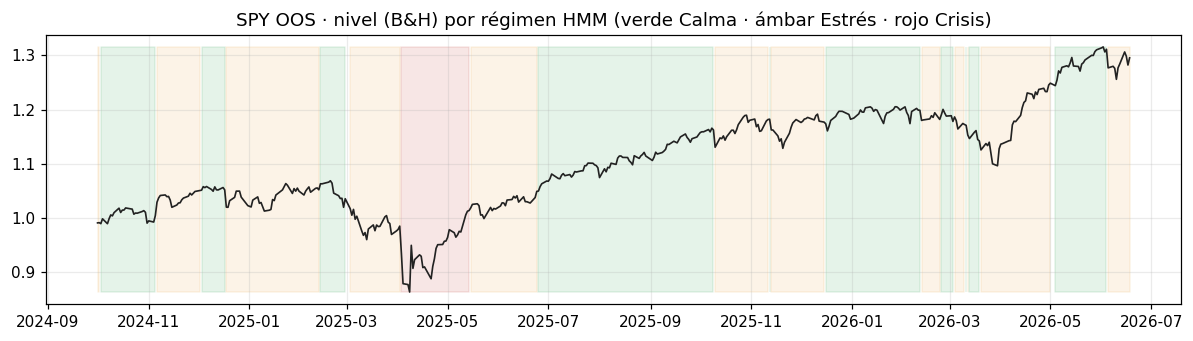

Calibración (n grande) · leverage effect = relación CONTEMPORÁNEA (mismo día):
   Calma  : ret_mismo_día=+0.000536 | frac_sube_día_SIGUIENTE=0.556
   Estrés : ret_mismo_día=+0.000167 | frac_sube_día_SIGUIENTE=0.539
   Crisis : ret_mismo_día=-0.000002 | frac_sube_día_SIGUIENTE=0.525
→ el retorno del MISMO día baja con el régimen (leverage), pero el régimen NO predice el signo del día siguiente (frac≈0.5). Su valor es disciplinar el RIESGO, no anticipar la dirección.


In [4]:
# Régimen HMM en SPY + leverage effect HONESTO (contemporáneo, no predice el día siguiente)
from experiments.quant_validation_panel import build_states
gamma, sigma, oos_ret = build_states("SPY")
g = gamma.reindex(oos_ret.index).dropna(); dom = g.values.argmax(1)
px = (1 + oos_ret.reindex(g.index)).cumprod()
fig, ax = plt.subplots(figsize=(11, 3.2))
ax.plot(px.index, px.values, color="#222", lw=1.1)
for st in (0, 1, 2):
    ax.fill_between(px.index, float(px.min()), float(px.max()), where=(dom == st), color=REGCOL[st], alpha=0.12, step="mid")
ax.set_title("SPY OOS · nivel (B&H) por régimen HMM (verde Calma · ámbar Estrés · rojo Crisis)"); plt.tight_layout(); plt.show()
cal = RDT["SPY"]["calib"]
print("Calibración (n grande) · leverage effect = relación CONTEMPORÁNEA (mismo día):")
for k in ("Calma", "Estrés", "Crisis"):
    print(f"   {k:7}: ret_mismo_día={cal[k]['ret_mismo_dia']:+.6f} | frac_sube_día_SIGUIENTE={cal[k]['frac_sube_sig']:.3f}")
print("→ el retorno del MISMO día baja con el régimen (leverage), pero el régimen NO predice el signo del día "
      "siguiente (frac≈0.5). Su valor es disciplinar el RIESGO, no anticipar la dirección.")

In [5]:
# ¿Por qué K=3? Verosimilitud held-out (SPY) + Sharpe K3 vs K2 en el panel — decisión justificada, no arbitraria
pk = KSEL["per_k"]
print("HMM · selección de K (SPY), log-verosimilitud HELD-OUT por observación (mayor = mejor):")
for k in ("2", "3"):
    print(f"   K={k}: heldout_loglik/obs = {pk[k]['heldout_loglik_perobs']:+.4f}  (BIC {pk[k]['BIC']:.0f})")
print(f"   → K mejor held-out = {KSEL['k_best_heldout']}, meseta en {KSEL['k_plateau_heldout']} (pasar a K=4 ya no mejora).")
ag = KABL["aggregate"]
print(f"\nEn el panel ({ag['n_assets']} activos): K=3 mejora el Sharpe sobre K=2 en {ag['n_assets']-ag['n_k2_better_sharpe']}/{ag['n_assets']} "
      f"(mediana ΔSharpe K3−K2 = {ag['median_d_sharpe_k3_minus_k2']:+.3f}).")
print("K=3 se fija por verosimilitud held-out + interpretabilidad (Calma/Estrés/Crisis), no por el resultado OOS.")

HMM · selección de K (SPY), log-verosimilitud HELD-OUT por observación (mayor = mejor):
   K=2: heldout_loglik/obs = -1.6927  (BIC 24131)
   K=3: heldout_loglik/obs = -1.3010  (BIC 18775)
   → K mejor held-out = 3, meseta en 3 (pasar a K=4 ya no mejora).

En el panel (10 activos): K=3 mejora el Sharpe sobre K=2 en 6/10 (mediana ΔSharpe K3−K2 = +0.381).
K=3 se fija por verosimilitud held-out + interpretabilidad (Calma/Estrés/Crisis), no por el resultado OOS.


### ¿Qué detector actúa y con qué éxito? (mecánica de la intervención, SPY OOS)
Los tres ejes eran la motivación; se reporta tal cual **cuál actúa**. En override-C **solo el régimen (RAM)
interviene**; PSA y GSO quedan casi inertes — y se enseña, no se esconde.

Intervención de M8: 30% (121 días). Acierto en intervenidos: M8=0.5868 vs agente=0.4132 (+0.174).


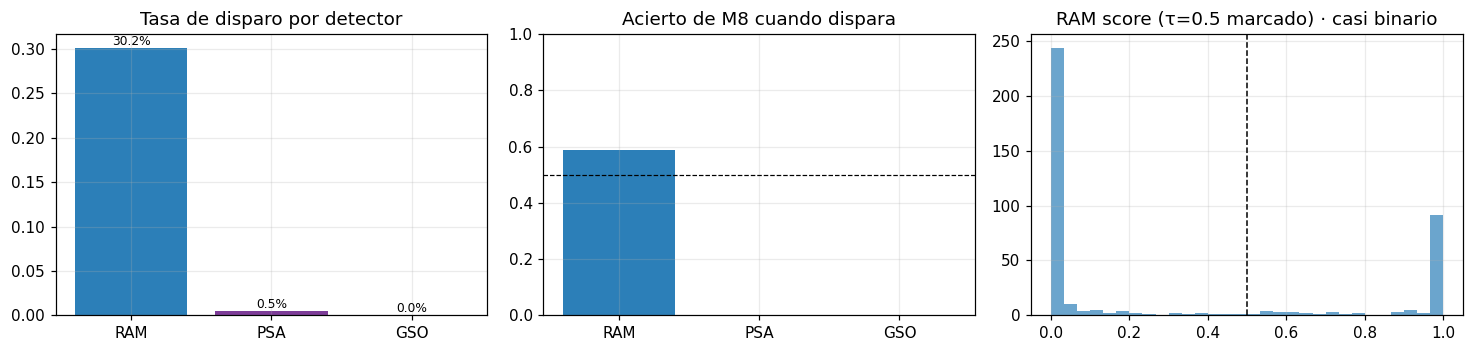

Atribución del P&L de rescate: RAM=+0.312, PSA=+0.000, GSO=+0.000 → todo el rescate es del canal RÉGIMEN (override-C, decisiones #5/#7).


In [6]:
# Intervención + disparo/éxito por detector + atribución de P&L (SPY OOS completo)
iv = DET["intervencion"]; dets = DET["detectores"]; at = DET["atribucion_pnl"]
print(f"Intervención de M8: {iv['tasa_intervencion']:.0%} ({iv['n_intervenciones']} días). "
      f"Acierto en intervenidos: M8={iv['acc_M8_si_interviene']} vs agente={iv['acc_M5_si_interviene']} "
      f"(+{iv['acc_M8_si_interviene']-iv['acc_M5_si_interviene']:.3f}).")
fig, axes = plt.subplots(1, 3, figsize=(13.5, 3.3)); D = ["RAM", "PSA", "GSO"]; dc = ["#2c7fb8", "#7d3c98", "#c0392b"]
axes[0].bar(D, [dets[d]["tasa_disparo"] for d in D], color=dc); axes[0].set_title("Tasa de disparo por detector")
for i, d in enumerate(D): axes[0].text(i, dets[d]["tasa_disparo"], f"{dets[d]['tasa_disparo']:.1%}", ha="center", va="bottom", fontsize=8)
axes[1].bar(D, [dets[d]["acc_M8_en_disparo"] or 0 for d in D], color=dc); axes[1].axhline(0.5, color="k", ls="--", lw=.8)
axes[1].set_ylim(0, 1); axes[1].set_title("Acierto de M8 cuando dispara")
sc = DET["scores"]; thr = sc["umbrales"]
axes[2].hist(sc["ram_score"], bins=30, color="#2c7fb8", alpha=.7); axes[2].axvline(thr["RAM_tau"], color="k", ls="--", lw=1)
axes[2].set_title("RAM score (τ=0.5 marcado) · casi binario")
plt.tight_layout(); plt.show()
print(f"Atribución del P&L de rescate: RAM={at['pnl_dias_RAM_disparado']:+.3f}, PSA={at['pnl_dias_PSA_disparado']:+.3f}, "
      f"GSO={at['pnl_dias_GSO_disparado']:+.3f} → todo el rescate es del canal RÉGIMEN (override-C, decisiones #5/#7).")

### Anatomía de un día de intervención: cuándo RAM corrige bien al agente y cuándo no
Para hacer tangible la mecánica, dos días reales del OOS con el **mismo patrón** (agente corto en régimen de Calma
→ RAM lo detecta incoherente y voltea a largo) pero **desenlace opuesto**. No escondemos los fallos: de las
intervenciones, una parte se equivoca; lo que sostiene a M8 es que **acierta más de las que falla**.

   caso      fecha régimen    RAM agente M5               votos (5 pers.) STRATA M8 r_next M8 M5
ACIERTO 2024-11-05   Calma 0.9939        -1 warr+/cath·/stan·/mich−/bill·        +1 +2.46%  ✓  ✗
  FALLO 2024-10-30   Calma 0.9998        -1 warr·/cath·/stan−/mich−/bill·        +1 -1.98%  ✗  ✓

Balance de las 121 intervenciones: M8 acierta 58.7% vs agente 41.3% → 71 aciertan, 50 fallan; P&L de rescate +0.312.


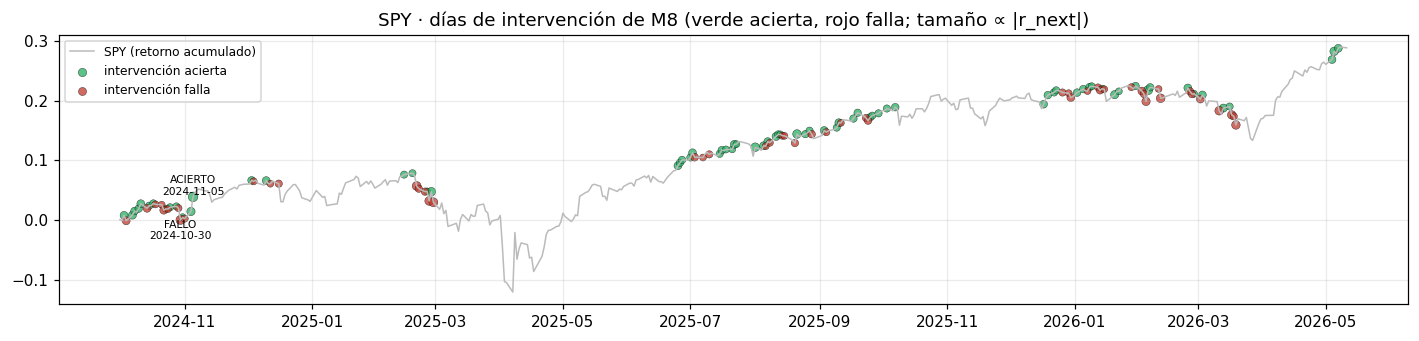

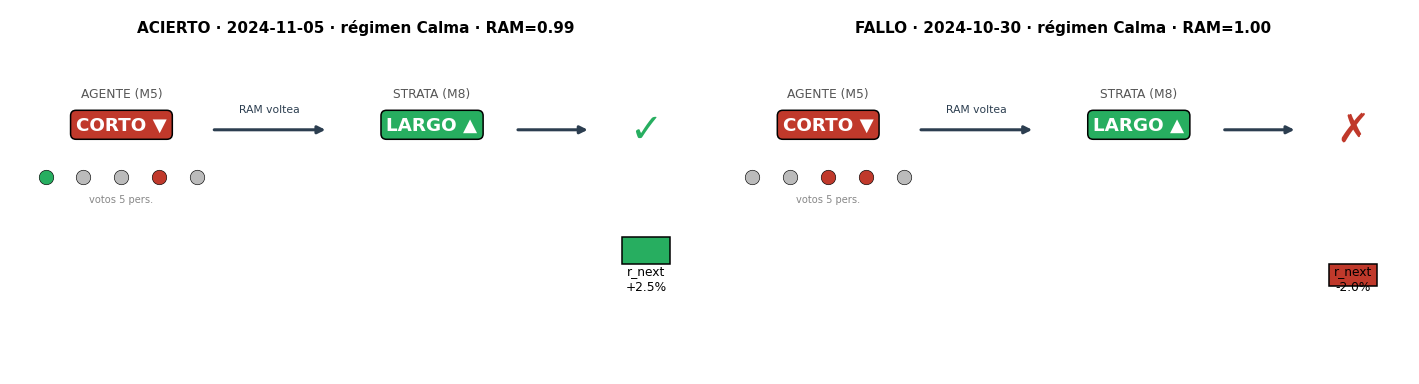

Mismo mecanismo en los dos: agente corto en Calma → RAM (score≈0.99) lo voltea a largo. El 2024-11-05 el mercado sube +2.5% y M8 acierta; el 2024-10-30 baja -2.0% y M8 falla. La regla no es infalible — es favorable en el agregado (71/121).


In [7]:
# Anatomía: un día de intervención ACERTADA y uno FALLIDA (mismo mecanismo, desenlace opuesto) + balance
ba = IANA["balance_intervenciones"]; ca, cf = IANA["caso_acierto"], IANA["caso_fallo"]
def _fila(c, tag):
    vot = "/".join(f"{p.split('_')[0][:4]}{'+' if s>0 else '−' if s<0 else '·'}" for p, s in c["votos_personalidades"].items())
    return {"caso": tag, "fecha": c["fecha"], "régimen": c["regimen"], "RAM": c["ram_score"],
            "agente M5": f"{c['agente_M5']:+d}", "votos (5 pers.)": vot, "STRATA M8": f"{c['STRATA_M8']:+d}",
            "r_next": f"{c['r_next']:+.2%}", "M8": "✓" if c["M8_acierta"] else "✗", "M5": "✓" if c["M5_acierta"] else "✗"}
print(pd.DataFrame([_fila(ca, "ACIERTO"), _fila(cf, "FALLO")]).to_string(index=False))
print(f"\nBalance de las {ba['n_intervenciones']} intervenciones: M8 acierta {ba['acc_M8_en_intervencion']:.1%} "
      f"vs agente {ba['acc_M5_en_intervencion']:.1%} → {ba['intervenciones_acertadas']} aciertan, "
      f"{ba['intervenciones_fallidas']} fallan; P&L de rescate {ba['pnl_intervenciones']:+.3f}.")

# Timeline: días de intervención coloreados por acierto/fallo, tamaño ∝ |r_next|
s = IANA["serie"]; x = pd.to_datetime(s["dates"]); iv = np.array(s["intervino"]); hit = np.array(s["m8_hit"])
rn = np.abs(np.array(s["r_next"])) * 100
fig, ax = plt.subplots(figsize=(13, 3.2))
ax.plot(x, np.cumsum(s["r_next"]), color="#bbb", lw=1, label="SPY (retorno acumulado)")
for msk, col, lab in [(iv & hit, "#27ae60", "intervención acierta"), (iv & ~hit, "#c0392b", "intervención falla")]:
    ax.scatter(x[msk], np.cumsum(s["r_next"])[msk], s=20 + 8 * rn[msk], color=col, alpha=.75, edgecolor="k", lw=.3, label=lab)
for c, mk in ((ca, "ACIERTO"), (cf, "FALLO")):
    xi = x[s["dates"].index(c["fecha"])]; ax.annotate(f"{mk}\n{c['fecha']}", (xi, np.cumsum(s["r_next"])[s["dates"].index(c["fecha"])]),
        fontsize=7, ha="center", va="bottom" if mk == "ACIERTO" else "top")
ax.set_title("SPY · días de intervención de M8 (verde acierta, rojo falla; tamaño ∝ |r_next|)"); ax.legend(fontsize=8, loc="upper left")
plt.tight_layout(); plt.show()
# Diagrama de flujo de la decisión (muy visual): agente → STRATA → resultado, para los dos casos
def _flow(ax, c, tag):
    ax.set_xlim(0, 10); ax.set_ylim(0, 10); ax.axis("off")
    up = lambda s: "LARGO ▲" if s > 0 else ("CORTO ▼" if s < 0 else "NEUTRAL")
    cl = lambda s: "#27ae60" if s > 0 else "#c0392b"
    ax.text(5, 9.4, f"{tag} · {c['fecha']} · régimen {c['regimen']} · RAM={c['ram_score']:.2f}",
            ha="center", fontsize=10, fontweight="bold")
    # 1) agente + votos de las 5 personalidades
    ax.text(1.6, 7.6, "AGENTE (M5)", ha="center", fontsize=8, color="#555")
    ax.text(1.6, 6.7, up(c["agente_M5"]), ha="center", fontsize=12, fontweight="bold",
            color="white", bbox=dict(boxstyle="round", fc=cl(c["agente_M5"]), ec="k"))
    pv = c["votos_personalidades"]
    for i, (p, s) in enumerate(pv.items()):
        ax.scatter(0.5 + i * 0.55, 5.4, s=90, color=cl(s) if s != 0 else "#bbb", edgecolor="k", lw=.4)
    ax.text(1.6, 4.7, "votos 5 pers.", ha="center", fontsize=6.5, color="#888")
    # 2) STRATA voltea
    ax.annotate("", xy=(4.6, 6.7), xytext=(2.9, 6.7), arrowprops=dict(arrowstyle="-|>", lw=2, color="#2c3e50"))
    ax.text(3.75, 7.2, "RAM voltea", ha="center", fontsize=7, color="#2c3e50")
    ax.text(6.1, 7.6, "STRATA (M8)", ha="center", fontsize=8, color="#555")
    ax.text(6.1, 6.7, up(c["STRATA_M8"]), ha="center", fontsize=12, fontweight="bold",
            color="white", bbox=dict(boxstyle="round", fc=cl(c["STRATA_M8"]), ec="k"))
    # 3) resultado al día siguiente
    ax.annotate("", xy=(8.4, 6.7), xytext=(7.3, 6.7), arrowprops=dict(arrowstyle="-|>", lw=2, color="#2c3e50"))
    mk, mkc = ("✓", "#27ae60") if c["M8_acierta"] else ("✗", "#c0392b")
    ax.text(9.2, 6.7, mk, ha="center", va="center", fontsize=26, color=mkc, fontweight="bold")
    ax.bar(9.2, c["r_next"] * 30, width=0.7, bottom=3.0, color=cl(c["verdad"]), edgecolor="k")
    ax.text(9.2, 2.3, f"r_next\n{c['r_next']:+.1%}", ha="center", fontsize=8)
fig, axes = plt.subplots(1, 2, figsize=(13, 3.6))
_flow(axes[0], ca, "ACIERTO"); _flow(axes[1], cf, "FALLO")
plt.tight_layout(); plt.show()
print("Mismo mecanismo en los dos: agente corto en Calma → RAM (score≈0.99) lo voltea a largo. El "
      f"{ca['fecha']} el mercado sube {ca['r_next']:+.1%} y M8 acierta; el {cf['fecha']} baja {cf['r_next']:+.1%} "
      "y M8 falla. La regla no es infalible — es favorable en el agregado (71/121).")

### ¿Por qué se conservan PSA y GSO si apenas disparan en este OOS?
Pregunta legítima (y esperable en defensa). La respuesta es que su **inactividad aquí es un diagnóstico honesto
de este OOS**, no un fallo — y se sostiene con tres evidencias:
1. **No son código muerto: en la calibración (24 años, con 2008 y 2020) sí disparan.** Los umbrales son P95/P99
   ex-ante y las distribuciones de score tienen **cola real** (PSA P99 ≫ P95; GSO P99/máx altos) → hubo días que
   los superaron. Este OOS, calmado y corto, simplemente no llega a esa cola.
2. **Sus condiciones de disparo no ocurren en este OOS.** GSO mide **sobre-exposición** frente a la banda GARCH;
   PSA mide **cambios estructurales** de opinión (BOCPD). En un único régimen alcista, con el agente de **sesgo
   persistente** (rara vez voltea) y **tamaño contenido**, ni hay sobre-exposición ni cambios estructurales.
3. **Es una predicción pre-registrada cumplida** (CLAUDE.md §2, nivel 2: *"RAM domina la atribución de P&L"*).
   Quitar PSA/GSO a posteriori porque "no disparan aquí" sería **ajustar el marco a los datos** — lo contrario del
   rigor. Se conservan como los **ejes ortogonales de seguridad** del diseño, activos bajo sus condiciones
   (shocks de volatilidad / giros de opinión) que este OOS no presenta.

Tasa de disparo OOS por detector (3 activos):
         RAM     PSA  GSO
SPY   0.3017  0.0050  0.0
XLE   0.5955  0.0251  0.0
MARA  0.4146  0.0000  0.0

En CALIBRACIÓN (2000–2024-09) PSA y GSO disparan ~5% a P95 (por construcción del umbral) — y NO es trivial: las colas son reales:
   PSA: P50=0.005  P95=0.023  P99=0.647  máx=1.000
   GSO: P50=0.425  P95=2.371  P99=5.565  máx=10.303


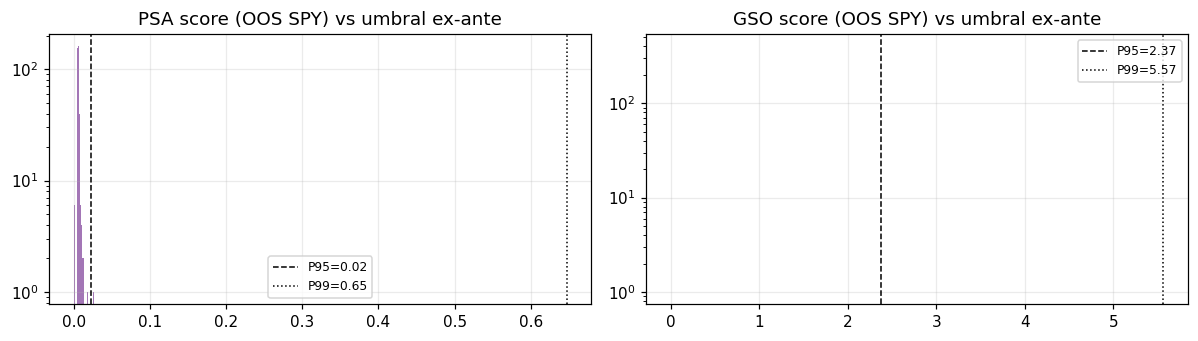

Los scores OOS de PSA/GSO se acumulan MUY por debajo del umbral ex-ante (calibrado con crisis) → el OOS no alcanza el régimen que los activaría. No están rotos: están dormidos porque no toca.


In [8]:
# Evidencia 1+2: disparo en CALIBRACIÓN vs OOS, y dónde caen los scores OOS frente al umbral ex-ante
fire_oos = {tk: {d: D["detectores"][d]["tasa_disparo"] for d in ("RAM", "PSA", "GSO")}
            for tk, D in (("SPY", DET), ("XLE", DETXLE), ("MARA", DETMAR))}
print("Tasa de disparo OOS por detector (3 activos):")
print(pd.DataFrame(fire_oos).T.to_string())
print(f"\nEn CALIBRACIÓN (2000–2024-09) PSA y GSO disparan ~{THR['psa']['activation_pct_at_p95']:.0%} a P95 (por "
      "construcción del umbral) — y NO es trivial: las colas son reales:")
for k in ("psa", "gso"):
    dd = THR[k]["score_distribution"]
    print(f"   {k.upper()}: P50={dd['p50']:.3f}  P95={dd['p95']:.3f}  P99={dd['p99']:.3f}  máx={dd['max']:.3f}")
# scores OOS de SPY: ¿dónde caen frente a P95/P99?
sc = DET["scores"]; thr = sc["umbrales"]
fig, axes = plt.subplots(1, 2, figsize=(11, 3.2))
for ax, key, name, p95, p99 in [(axes[0], "psa_score", "PSA", thr["PSA_p95"], thr["PSA_p99"]),
                                 (axes[1], "gso_score", "GSO", thr["GSO_p95"], thr["GSO_p99"])]:
    ax.hist(sc[key], bins=30, color="#7d3c98", alpha=.7)
    ax.axvline(p95, color="k", ls="--", lw=1, label=f"P95={p95:.2f}"); ax.axvline(p99, color="k", ls=":", lw=1, label=f"P99={p99:.2f}")
    ax.set_title(f"{name} score (OOS SPY) vs umbral ex-ante"); ax.legend(fontsize=8); ax.set_yscale("log")
plt.tight_layout(); plt.show()
print("Los scores OOS de PSA/GSO se acumulan MUY por debajo del umbral ex-ante (calibrado con crisis) → el OOS "
      "no alcanza el régimen que los activaría. No están rotos: están dormidos porque no toca.")

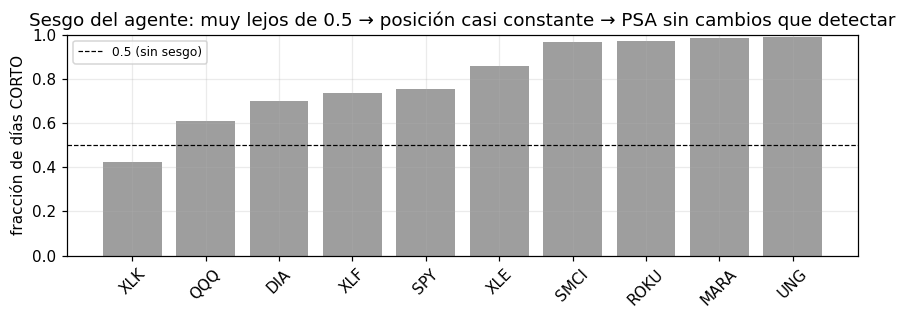

El agente está corto el 80% de los días de media (rango 43%–99%): una postura casi constante. BOCPD (PSA) detecta CAMBIOS estructurales; sin cambios, no dispara. Y GSO necesita sobre-exposición que el agente no genera.

Conclusión defendible: PSA/GSO se mantienen como ejes ortogonales de seguridad (pre-registrados); su inactividad en este OOS es un hallazgo honesto y una predicción cumplida (RAM domina), no un defecto.


In [9]:
# Evidencia 2 (mecánica): el agente tiene sesgo PERSISTENTE → PSA (cambio estructural) no tiene qué detectar
shorts = {a: MECH[a]["agente_frac_corto"] for a in PANEL10}
fig, ax = plt.subplots(figsize=(8, 3.0))
order = sorted(PANEL10, key=lambda a: shorts[a])
ax.bar(order, [shorts[a] for a in order], color="#9e9e9e"); ax.axhline(0.5, color="k", ls="--", lw=.8, label="0.5 (sin sesgo)")
ax.set_ylim(0, 1); ax.set_ylabel("fracción de días CORTO"); ax.set_title("Sesgo del agente: muy lejos de 0.5 → posición casi constante → PSA sin cambios que detectar")
ax.tick_params(axis="x", rotation=45); ax.legend(fontsize=8); plt.tight_layout(); plt.show()
print(f"El agente está corto el {np.mean(list(shorts.values())):.0%} de los días de media (rango "
      f"{min(shorts.values()):.0%}–{max(shorts.values()):.0%}): una postura casi constante. BOCPD (PSA) detecta "
      "CAMBIOS estructurales; sin cambios, no dispara. Y GSO necesita sobre-exposición que el agente no genera.")
print("\nConclusión defendible: PSA/GSO se mantienen como ejes ortogonales de seguridad (pre-registrados); su "
      "inactividad en este OOS es un hallazgo honesto y una predicción cumplida (RAM domina), no un defecto.")

### Prueba directa: ¿y si los modelos NO usan los detectores? (ablación, misma config, SPY)
La prueba que zanja el gap: reentrenar el meta-learner **con la misma config** quitando las features de los
detectores y **medir el cambio**. Para **M8** no hay ablación: M8 *es* el detector de régimen → sin él, M8
colapsa al agente (M5). M10 (XGBoost) y AutoML (H2O, **seed=42, max_models=25 → determinista**) se reentrenan con:
ALL22 · sin PSA+GSO · solo agente · solo STRATA. **Distinción clave:** que PSA/GSO casi no **disparen** como
reglas (§2 arriba) no implica que sus **scores continuos** no sirvan como *features* — esto lo separa la ablación.

In [10]:
# Ablación de detectores en el meta-learner (SPY, misma config): M10-XGBoost y AutoML-H2O
ab = DETABL["ablacion_m10_spy"]; ref = DETABL["referencia_spy"]
rows = [{"modelo": "M5 (agente, sin STRATA)", "feats": 15, "acc": ref["M5_agente"]["accuracy"], "sharpe": ref["M5_agente"]["sharpe"]},
        {"modelo": "M8 (regla régimen)", "feats": "—", "acc": ref["M8_regla_régimen"]["accuracy"], "sharpe": ref["M8_regla_régimen"]["sharpe"]}]
for nm, v in ab.items():
    rows.append({"modelo": f"M10 · {nm}", "feats": v["n_features"], "acc": v["accuracy"], "sharpe": v["sharpe"]})
try:
    aa = json.load(open("outputs/experiments/automl_ablation_detectors.json"))["ablacion_automl_spy"]
    for nm, v in aa.items():
        rows.append({"modelo": f"AutoML · {nm}", "feats": v["n_features"], "acc": v["accuracy"], "sharpe": v["sharpe"]})
except Exception:
    print("(AutoML-H2O ablación: pendiente de ejecución — ver experiments/automl_ablation_detectors.py)")
print(pd.DataFrame(rows).set_index("modelo").to_string())
print(f"\nM10-XGBoost: quitar PSA+GSO NO degrada — incluso MEJORA (acc {ab['ALL22 (canónico)']['accuracy']} → "
      f"{ab['sin PSA+GSO']['accuracy']}): con 22 features hay algo de sobreajuste y esos dos no le aportan.")
try:
    a0, a1 = aa["ALL22 (canónico)"], aa["sin PSA+GSO"]
    print(f"AutoML-H2O (el GANADOR): quitar PSA+GSO SÍ DEGRADA (acc {a0['accuracy']} → {a1['accuracy']}, "
          f"Sharpe {a0['sharpe']:+.2f} → {a1['sharpe']:+.2f}) → el buscador SÍ extrae información de los scores "
          "continuos de PSA/GSO, aunque como REGLAS casi no disparen.")
    print("\nConclusión (zanja el gap): PSA/GSO rara vez intervienen como reglas (RAM domina las intervenciones, §2), "
          "PERO sus scores continuos llevan información que un aprendiz capaz (AutoML, el modelo ganador) aprovecha "
          "— quitarlas le cuesta accuracy y Sharpe. Conservarlas se justifica por DOBLE motivo: (1) el mejor modelo "
          "las usa AQUÍ; (2) son ejes ortogonales de seguridad para regímenes que este OOS no contiene (§2). "
          "Que ayuden o no como features depende del modelo (AutoML sí; el XGBoost de params fijos se sobreajusta).")
except Exception:
    pass

                          feats     acc  sharpe
modelo                                         
M5 (agente, sin STRATA)      15  0.3665  -3.070
M8 (regla régimen)            —  0.4422  -0.464
M10 · ALL22 (canónico)       22  0.4940  -0.604
M10 · sin PSA+GSO            20  0.5139   0.193
M10 · sin GSO                21  0.4940  -0.727
M10 · sin PSA                21  0.5139   0.380
M10 · solo agente (15)       15  0.5418   1.055
M10 · solo STRATA (7)         7  0.5458   1.957
AutoML · ALL22 (canónico)    22  0.5737   2.681
AutoML · sin PSA+GSO         20  0.5498   1.716
AutoML · solo agente (15)    15  0.5657   1.703
AutoML · solo STRATA (7)      7  0.5378   1.437

M10-XGBoost: quitar PSA+GSO NO degrada — incluso MEJORA (acc 0.494 → 0.5139): con 22 features hay algo de sobreajuste y esos dos no le aportan.
AutoML-H2O (el GANADOR): quitar PSA+GSO SÍ DEGRADA (acc 0.5737 → 0.5498, Sharpe +2.68 → +1.72) → el buscador SÍ extrae información de los scores continuos de PSA/GSO, aunque como REGL

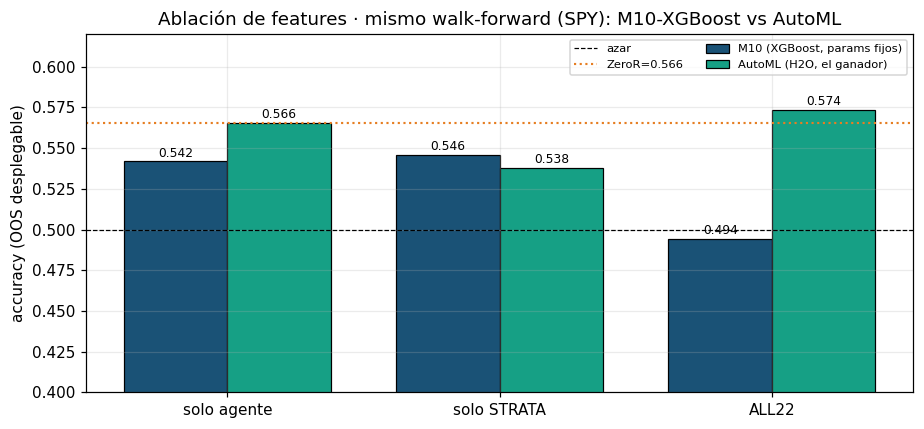

AutoML (el modelo que usamos): agente-15=0.5657 → 22=0.5737 (+0.008) → alcanza su MÁXIMO con las 22: SÍ extrae valor de las features de STRATA.
M10-XGBoost (params fijos): 22=0.494 < agente-15=0.5418 → se SOBREAJUSTA con 22 features (por eso en §2 quitarle PSA+GSO le mejoraba). El que las features de STRATA ayuden o no depende del modelo: el buscador con selección (AutoML) sí las aprovecha; el XGBoost de params fijos no. Conclusión consistente con la ablación de detectores de §2.


In [11]:
# Ablación de features (barra): agente-15 vs STRATA-7 vs 22, en el ensemble M10-XGBoost Y en AutoML (el ganador)
ab = DETABL["ablacion_m10_spy"]
aa = json.load(open("outputs/experiments/automl_ablation_detectors.json"))["ablacion_automl_spy"]
zeror = PAN["SPY"]["table"]["zeror"]["accuracy"]
sets = ["solo agente (15)", "solo STRATA (7)", "ALL22 (canónico)"]
fig, ax = plt.subplots(figsize=(8.5, 4)); x = np.arange(len(sets)); w = 0.38
m10v = [ab[s]["accuracy"] for s in sets]; amlv = [aa[s]["accuracy"] for s in sets]
ax.bar(x - w/2, m10v, w, color="#1a5276", edgecolor="k", lw=.8, label="M10 (XGBoost, params fijos)")
ax.bar(x + w/2, amlv, w, color="#16a085", edgecolor="k", lw=.8, label="AutoML (H2O, el ganador)")
ax.axhline(0.5, color="k", ls="--", lw=.8, label="azar"); ax.axhline(zeror, color="#e67e22", ls=":", lw=1.4, label=f"ZeroR={zeror:.3f}")
for i in range(len(sets)):
    ax.text(i - w/2, m10v[i] + 0.003, f"{m10v[i]:.3f}", ha="center", fontsize=8)
    ax.text(i + w/2, amlv[i] + 0.003, f"{amlv[i]:.3f}", ha="center", fontsize=8)
ax.set_xticks(x); ax.set_xticklabels([s.replace(" (15)", "").replace(" (7)", "").replace(" (canónico)", "") for s in sets])
ax.set_ylim(0.40, 0.62); ax.set_ylabel("accuracy (OOS desplegable)")
ax.set_title("Ablación de features · mismo walk-forward (SPY): M10-XGBoost vs AutoML"); ax.legend(fontsize=7.5, ncol=2)
plt.tight_layout(); plt.show()
print(f"AutoML (el modelo que usamos): agente-15={aa['solo agente (15)']['accuracy']} → 22={aa['ALL22 (canónico)']['accuracy']} "
      f"({aa['ALL22 (canónico)']['accuracy']-aa['solo agente (15)']['accuracy']:+.3f}) → alcanza su MÁXIMO con las 22: "
      "SÍ extrae valor de las features de STRATA.")
print(f"M10-XGBoost (params fijos): 22={ab['ALL22 (canónico)']['accuracy']} < agente-15={ab['solo agente (15)']['accuracy']} "
      "→ se SOBREAJUSTA con 22 features (por eso en §2 quitarle PSA+GSO le mejoraba). El que las features de STRATA "
      "ayuden o no depende del modelo: el buscador con selección (AutoML) sí las aprovecha; el XGBoost de params "
      "fijos no. Conclusión consistente con la ablación de detectores de §2.")

### Matriz régimen × dirección: el leverage es contemporáneo, no predictivo
Para no dejar el *leverage effect* solo en prosa: la distribución empírica de la dirección por régimen, en la
**calibración** (n grande) y en el **OOS**. La clave: el retorno del **mismo día** baja con el régimen (leverage),
pero la fracción de días que **suben al día siguiente** ronda 0.5 en todos los regímenes → el régimen separa por
volatilidad, **no anticipa el signo**.

ventana régimen    n  ret_mismo_día  frac_sube_día_sig
  calib   Calma 2664       0.000536              0.556
  calib  Estrés 2545       0.000167              0.539
  calib  Crisis  995      -0.000002              0.525
    oos   Calma  196       0.000809              0.525
    oos  Estrés  195       0.000359              0.600
    oos  Crisis   29       0.001381              0.655


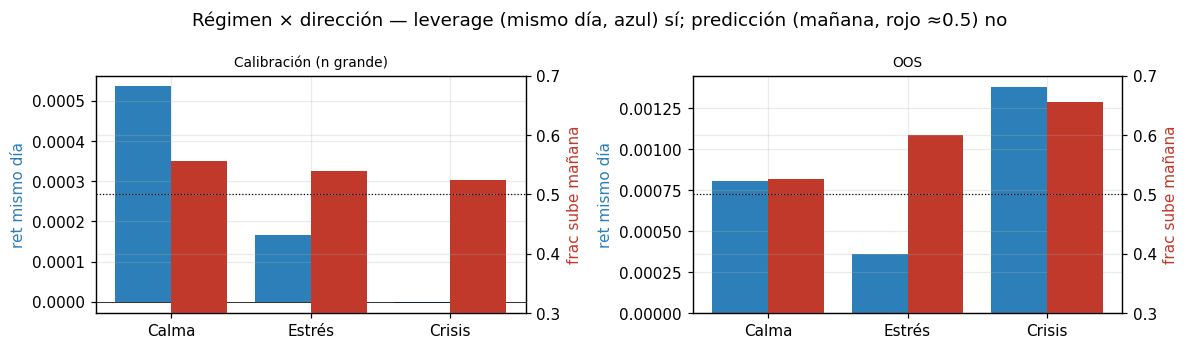

El régimen NO predice el signo del día siguiente (frac≈0.5 en los tres): su valor es disciplinar el RIESGO.


In [12]:
# Contingencia régimen × dirección (calib y OOS) desde regime_direction_table.json
import pandas as pd
rows = []
for win in ("calib", "oos"):
    d = RDT["SPY"][win]
    for rg in ("Calma", "Estrés", "Crisis"):
        rows.append({"ventana": win, "régimen": rg, "n": d[rg]["n"],
                     "ret_mismo_día": round(d[rg]["ret_mismo_dia"], 6),
                     "frac_sube_día_sig": round(d[rg]["frac_sube_sig"], 3)})
RC = pd.DataFrame(rows)
print(RC.to_string(index=False))
fig, axes = plt.subplots(1, 2, figsize=(11, 3.2))
for ax, win, ttl in [(axes[0], "calib", "Calibración (n grande)"), (axes[1], "oos", "OOS")]:
    d = RDT["SPY"][win]; rgs = ["Calma", "Estrés", "Crisis"]
    same = [d[r]["ret_mismo_dia"] for r in rgs]; nxt = [d[r]["frac_sube_sig"] for r in rgs]
    x = np.arange(3); ax2 = ax.twinx()
    ax.bar(x - 0.2, same, 0.4, color="#2c7fb8", label="ret mismo día (leverage)")
    ax2.bar(x + 0.2, nxt, 0.4, color="#c0392b", label="frac sube día sig.")
    ax2.axhline(0.5, color="k", ls=":", lw=.8); ax2.set_ylim(0.3, 0.7)
    ax.set_xticks(x); ax.set_xticklabels(rgs); ax.set_title(f"{ttl}", fontsize=9); ax.axhline(0, color="k", lw=.5)
    ax.set_ylabel("ret mismo día", color="#2c7fb8"); ax2.set_ylabel("frac sube mañana", color="#c0392b")
fig.suptitle("Régimen × dirección — leverage (mismo día, azul) sí; predicción (mañana, rojo ≈0.5) no"); plt.tight_layout(); plt.show()
print("El régimen NO predice el signo del día siguiente (frac≈0.5 en los tres): su valor es disciplinar el RIESGO.")

## §3 Caso de estudio: SPY — el agente perdedor y su rescate

El escaparate. El agente (M5) acierta 0.37 y se arruina; la supervisión lo rescata. Y AutoML llega a **ganar en
punto a todas** — resultado real que se registra con su matiz (**nominal** frente al baseline trivial).

In [13]:
# Tabla SPY (panel mm25) + ganador
tab = PAN["SPY"]["table"]
spy = pd.DataFrame({s: {"acc": tab[PKEY[s]]["accuracy"], "AUC": tab[PKEY[s]].get("auc"), "Sharpe": tab[PKEY[s]]["sharpe"],
                        "maxDD": tab[PKEY[s]]["max_dd"], "Calmar": tab[PKEY[s]]["calmar"], "equity": tab[PKEY[s]]["equity_final"]} for s in COL}).T
with pd.option_context("display.float_format", lambda v: f"{v:.4f}" if v is not None else "—"): print(spy)
print(f"\nGanador accuracy (NOMINAL): AutoML {tab['automl']['accuracy']:.4f} > ZeroR/B&H {tab['zeror']['accuracy']:.4f}.")

          acc    AUC  Sharpe   maxDD  Calmar  equity
M5     0.3665    NaN -3.0700 -0.3025 -0.9990  0.6990
M8     0.4422    NaN -0.4640 -0.1520 -0.3900  0.9410
M10    0.4940 0.5309 -0.6040 -0.1609 -0.4980  0.9202
AutoML 0.5737 0.5521  2.6810 -0.0551  6.9290  1.3798
ZeroR  0.5657    NaN  2.2060 -0.0982  3.1020  1.3032
B&H    0.5657    NaN  2.2060 -0.0982  3.1020  1.3032

Ganador accuracy (NOMINAL): AutoML 0.5737 > ZeroR/B&H 0.5657.


In [14]:
# Matriz McNemar SPY (honesta): rescate sig vs M5, nominal vs ZeroR
tests = PAN["SPY"]["tests"]; rows = []
for k, v in tests.items():
    if isinstance(v, dict) and "p" in v:
        a, b = k.replace("_xgb", "").split("_vs_"); rows.append({"comparación": f"{a.upper()} vs {b.upper()}", "p_McNemar": round(v["p"], 4), "sig_0.10": "SÍ" if v["p"] < 0.10 else "no"})
print(pd.DataFrame(rows).to_string(index=False))
print(f"\nRescate del agente SIGNIFICATIVO: AutoML/M10/M8 vs M5 p={tests['automl_vs_m5']['p']:.4f}/{tests['m10_xgb_vs_m5']['p']:.4f}/{tests['m8_vs_m5']['p']:.4f}.")
print(f"Batir al baseline NOMINAL: AutoML vs ZeroR p={tests['automl_vs_zeror']['p']:.3f} (ventana corta).")

       comparación  p_McNemar sig_0.10
          M8 vs M5     0.0509       SÍ
         M10 vs M5     0.0074       SÍ
      AUTOML vs M5     0.0002       SÍ
       M5 vs ZEROR     0.0003       SÍ
       M8 vs ZEROR     0.0026       SÍ
      M10 vs ZEROR     0.1329       no
   AUTOML vs ZEROR     0.9020       no
      AUTOML vs M8     0.0059       SÍ
     AUTOML vs M10     0.0574       SÍ
    M5_SIGN vs 0.5     0.0000       SÍ
    M8_SIGN vs 0.5     0.0770       SÍ
   M10_SIGN vs 0.5     0.8996       no
AUTOML_SIGN vs 0.5     0.0229       SÍ
 ZEROR_SIGN vs 0.5     0.0432       SÍ
    BH_SIGN vs 0.5     0.0432       SÍ

Rescate del agente SIGNIFICATIVO: AutoML/M10/M8 vs M5 p=0.0002/0.0074/0.0509.
Batir al baseline NOMINAL: AutoML vs ZeroR p=0.902 (ventana corta).


### Matrices de confusión en SPY (predicho ±1 vs real)
La dirección **predicha** (posición) frente a la **real** (signo de $r_{t+1}$), por estrategia. Hace visible *qué
tipo* de acierto/error comete cada una: el agente (M5) falla sobre todo en largos (muchos FN), la regla y el
aprendiz reequilibran, y las triviales (ZeroR/B&H) **siempre van largas** (toda la columna de cortos vacía).

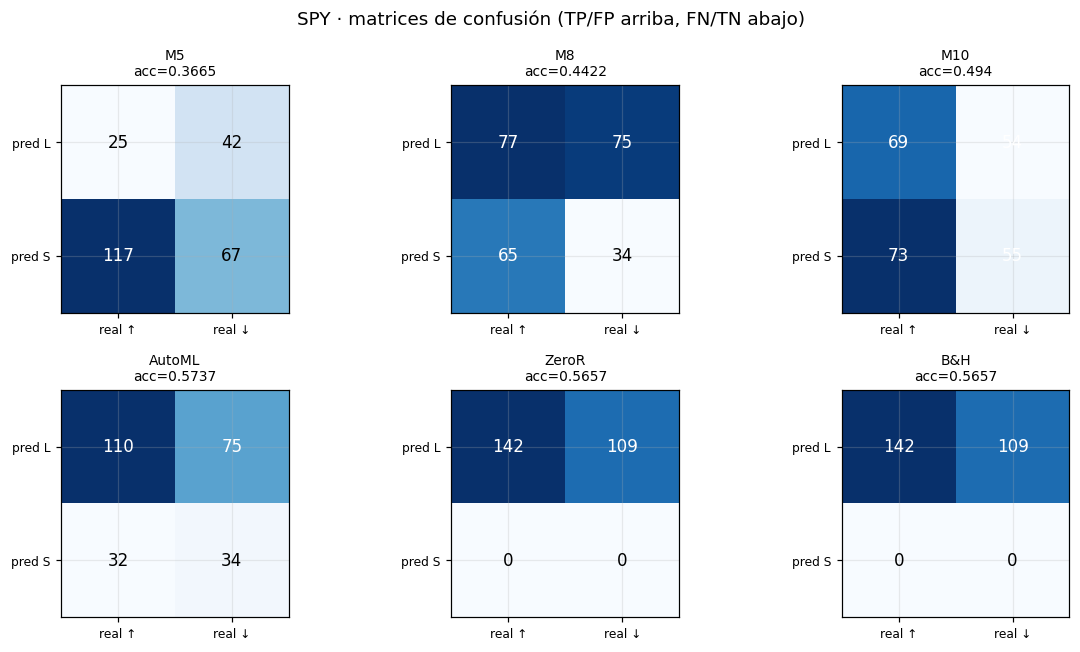

M5: solo 25 aciertos en largo y 117 fallos en largo (apuesta corto y el mercado sube). M8/M10/AutoML reducen los FN (capturan más subidas). ZeroR/B&H: FN=TN=0 (siempre largo).


In [15]:
# Matrices de confusión SPY (6 estrategias) — fuente: confusion_panel.json
def _plot_cm(ax, cm, titulo):
    M = np.array([[cm["TP"], cm["FP"]], [cm["FN"], cm["TN"]]])  # filas: predicho L/S · cols: real U/D
    im = ax.imshow(M, cmap="Blues"); ax.set_title(f"{titulo}\nacc={cm['accuracy']}", fontsize=9)
    ax.set_xticks([0, 1]); ax.set_xticklabels(["real ↑", "real ↓"], fontsize=8)
    ax.set_yticks([0, 1]); ax.set_yticklabels(["pred L", "pred S"], fontsize=8)
    for i in range(2):
        for j in range(2):
            ax.text(j, i, M[i, j], ha="center", va="center", fontsize=11,
                    color="white" if M[i, j] > M.max() * 0.6 else "black")
spc = CONF["spy_por_estrategia"]
fig, axes = plt.subplots(2, 3, figsize=(11, 6)); axes = axes.ravel()
for ax, s in zip(axes, ["M5", "M8", "M10", "AutoML", "ZeroR", "B&H"]):
    _plot_cm(ax, spc[s], s)
fig.suptitle("SPY · matrices de confusión (TP/FP arriba, FN/TN abajo)"); plt.tight_layout(); plt.show()
print(f"M5: solo {spc['M5']['TP']} aciertos en largo y {spc['M5']['FN']} fallos en largo (apuesta corto y el "
      "mercado sube). M8/M10/AutoML reducen los FN (capturan más subidas). ZeroR/B&H: FN=TN=0 (siempre largo).")

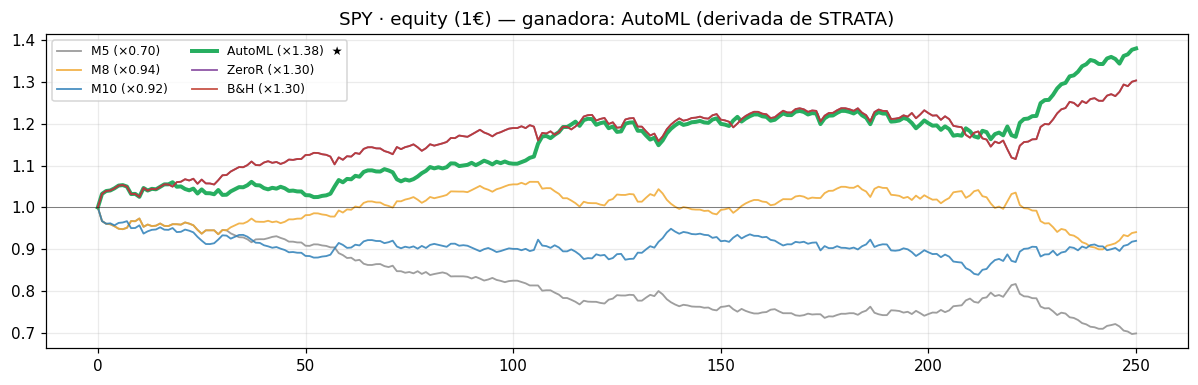

M5 se hunde (×0.70); M8 ×0.94 y M10 ×0.92 lo rescatan; AutoML gana (×1.38).


In [16]:
# Equity SPY — todas las estrategias, incl. AutoML (ganadora, derivada de STRATA), con assert
nr = DPA["SPY"]["net_returns"]; serie = {"M5": nr["m5"], "M8": nr["m8"], "M10": nr["m10"], "AutoML": ANR["SPY"]["automl"], "ZeroR": nr["zeror"], "B&H": nr["bh"]}
eqf = {s: float(np.cumprod(1 + np.nan_to_num(np.array(v, float)))[-1]) for s, v in serie.items()}; win = max(eqf, key=eqf.get)
fig, ax = plt.subplots(figsize=(11, 3.6))
for s, v in serie.items():
    eq = np.cumprod(1 + np.nan_to_num(np.array(v, float))); ax.plot(eq, color=COL[s], lw=2.6 if s == win else 1.2, alpha=1 if s in (win, "M5") else .85, label=f"{s} (×{eq[-1]:.2f})" + ("  ★" if s == win else ""))
ax.axhline(1, color="k", lw=.6, alpha=.5); ax.set_title(f"SPY · equity (1€) — ganadora: {win} (derivada de STRATA)"); ax.legend(fontsize=8, ncol=2); plt.tight_layout(); plt.show()
assert win == "AutoML", "la ganadora de la equity SPY debe ser AutoML"
print(f"M5 se hunde (×{eqf['M5']:.2f}); M8 ×{eqf['M8']:.2f} y M10 ×{eqf['M10']:.2f} lo rescatan; AutoML gana (×{eqf[win]:.2f}).")

  M8 vs M5: ΔSharpe=+2.61 IC[-0.242, 5.9353] —
  M8 vs BH: ΔSharpe=-2.67 IC[-5.6822, 0.4859] —
  M10 vs M5: ΔSharpe=+2.47 IC[-0.5479, 5.3382] —
  M10 vs BH: ΔSharpe=-2.81 IC[-5.6, -0.2652] SIG
(A nivel SPY el IC cruza 0; la significancia del riesgo llega en el pooled del panel, §4.)


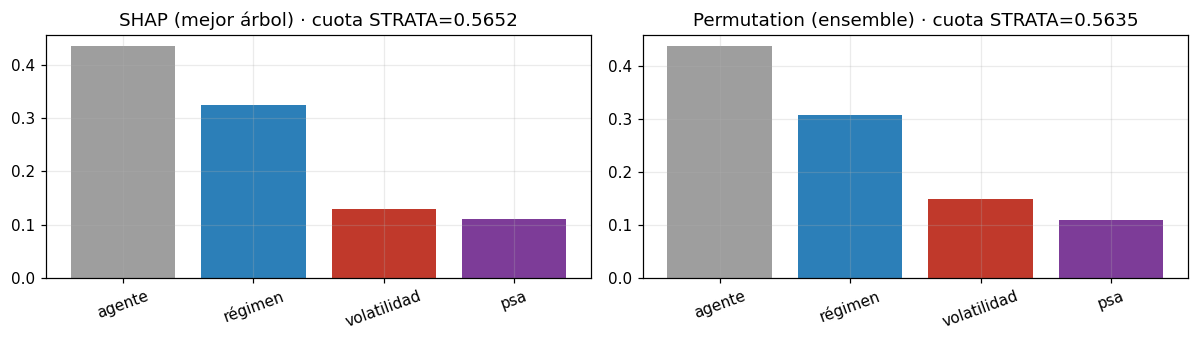

En SPY la cuota STRATA ≈ 0.5652 tree / 0.5635 permutation (cifra canónica RESULTADOS_OBJETIVO §1ter; las features STRATA pesan más que las del agente). Es el MISMO número que reporta la tabla de §4.5 para SPY.


In [17]:
# Rescate de riesgo SPY (bootstrap IC95) + SHAP/permutation AutoML
boot = DPA["SPY"]["boot"]
for s in ("m8", "m10"):
    for b in ("m5", "bh"):
        v = boot[f"{s}_vs_{b}"]["dSharpe"]; print(f"  {s.upper()} vs {b.upper()}: ΔSharpe={v['point']:+.2f} IC{v['ci95']} {'SIG' if v['sig'] else '—'}")
print("(A nivel SPY el IC cruza 0; la significancia del riesgo llega en el pooled del panel, §4.)")
imp = IMP.get("SPY", {}); sx = imp.get("shap_tree", {}); pe = imp.get("perm_importance_ensemble", {})
fig, axes = plt.subplots(1, 2, figsize=(11, 3.2))
for ax, dat, ttl in [(axes[0], sx, "SHAP (mejor árbol)"), (axes[1], pe, "Permutation (ensemble)")]:
    bl = dat.get("bloques")
    if bl: ax.bar(list(bl), list(bl.values()), color=["#9e9e9e", "#2c7fb8", "#c0392b", "#7d3c98"]); ax.set_title(f"{ttl} · cuota STRATA={dat.get('cuota_strata')}"); ax.tick_params(axis="x", rotation=20)
plt.tight_layout(); plt.show()
print(f"En SPY la cuota STRATA ≈ {sx.get('cuota_strata')} tree / {pe.get('cuota_strata')} permutation "
      "(cifra canónica RESULTADOS_OBJETIVO §1ter; las features STRATA pesan más que las del agente). "
      "Es el MISMO número que reporta la tabla de §4.5 para SPY.")

### ¿De dónde viene el valor? Override vs abstención + sensibilidad a umbrales (SPY)
Dos pruebas de robustez sobre el caso SPY (ventana desplegable, n=251). **(a)** ¿El valor viene de *voltear* al
régimen (override-C) o bastaría con *abstenerse* (posición 0) o *reducir* el tamaño en los días de intervención?
**(b)** ¿Es el resultado un artefacto de los umbrales elegidos? Se barre el gate RAM τ y el umbral del
meta-learner p1*. **Se reporta el barrido completo** (no se elige el mejor): si es plano alrededor del valor
canónico, los umbrales ex-ante no son un grado de libertad oculto.

*Nota de denominador.* La accuracy de esta sección se mide **sobre los días en-mercado** (n=232 con posición ≠ 0,
porque las variantes cambian cuántos días se está dentro), mientras que la tabla §3 usa **los 251 días** del OOS.
Por eso M8-SPY aparece como 0.478 aquí y 0.442 en §3: mismo recuento de aciertos (M5=92, M8=111) e idéntico
Sharpe/equity/maxDD, solo cambia el divisor. La celda reconcilia ambas cifras explícitamente.

In [18]:
# (a) Variantes de intervención en SPY: override (canónico) vs abstención vs reduce
# NOTA de denominador: la accuracy de esta tabla se calcula SOBRE LOS DÍAS EN-MERCADO (n=232, frac=0.924),
# no sobre los 251 días del OOS. Por eso M5=0.3966 y M8=0.4784 aquí difieren de la tabla §3 (M5=0.3665,
# M8=0.4422, denominador n=251 todos los días). MISMO recuento de aciertos (M5=92, M8=111) y MISMO
# Sharpe/equity/maxDD: solo cambia el divisor (251 vs 232). No es contradicción ni altera ninguna conclusión
# (ambas accuracy < 0.5). Aquí interesa el divisor en-mercado porque comparamos variantes que cambian cuántos
# días se está dentro (abstención reduce n_pos a 147), y la accuracy debe medirse sobre los días con posición.
V = SPYIV["variantes_intervencion"]
rows = [{"estrategia": k, "accuracy (en-mercado)": v["accuracy"], "Sharpe": v["sharpe"], "maxDD": v["max_dd"],
         "equity": v["equity_final"], "n_pos": v["n_pos"], "en_mercado": f"{v['frac_en_mercado']:.0%}"} for k, v in V.items()]
print(pd.DataFrame(rows).set_index("estrategia").to_string())
ov = V["M8_override_C (canónico)"]; ab = V["M8_abstencion"]; ag = V["M5_agente"]
# Reconciliación con la tabla §3: re-expresar la accuracy de M5/M8 (override-C) sobre los 251 días del OOS.
# Días flat (no en-mercado) cuentan como NO-acierto, igual que en la convención de la tabla panel.
N_OOS = SPYIV["meta"]["n_sub"]  # 251
ac_251 = {nm: round(v["accuracy"] * v["n_pos"] / N_OOS, 4) for nm, v in [("M5", ag), ("M8_override_C", ov)]}
print(f"\nReconciliación con §3 (denominador n={N_OOS}, días flat = no-acierto): "
      f"M5={ac_251['M5']} · M8={ac_251['M8_override_C']} — coinciden con la tabla §3 (M5={PAN['SPY']['table']['m5']['accuracy']:.4f}, "
      f"M8={PAN['SPY']['table']['m8']['accuracy']:.4f}). Misma estrategia, mismos aciertos; arriba el divisor son los días en-mercado.")
print(f"\nLectura: el agente se hunde (eq {ag['equity_final']}). Abstenerse en los días de intervención lo mejora "
      f"(eq {ab['equity_final']}) — evita malas apuestas — pero el VALOR REAL está en VOLTEAR al régimen: "
      f"override-C llega a eq {ov['equity_final']} (Sharpe {ov['sharpe']:+.2f} vs {ab['sharpe']:+.2f} de abstención). "
      "STRATA no solo 'apaga' al agente: lo corrige activamente, y eso es lo que rescata.")

                          accuracy (en-mercado)  Sharpe   maxDD  equity  n_pos en_mercado
estrategia                                                                               
M5_agente                                0.3966  -3.070 -0.3025  0.6990    232        92%
M8_override_C (canónico)                 0.4784  -0.464 -0.1520  0.9410    232        92%
M8_abstencion                            0.4014  -2.101 -0.1977  0.8141    147        59%
M8_reduce_0.5                            0.3966  -2.750 -0.2468  0.7548    232        92%

Reconciliación con §3 (denominador n=251, días flat = no-acierto): M5=0.3666 · M8=0.4422 — coinciden con la tabla §3 (M5=0.3665, M8=0.4422). Misma estrategia, mismos aciertos; arriba el divisor son los días en-mercado.

Lectura: el agente se hunde (eq 0.699). Abstenerse en los días de intervención lo mejora (eq 0.8141) — evita malas apuestas — pero el VALOR REAL está en VOLTEAR al régimen: override-C llega a eq 0.941 (Sharpe -0.46 vs -2.10 de abstención).

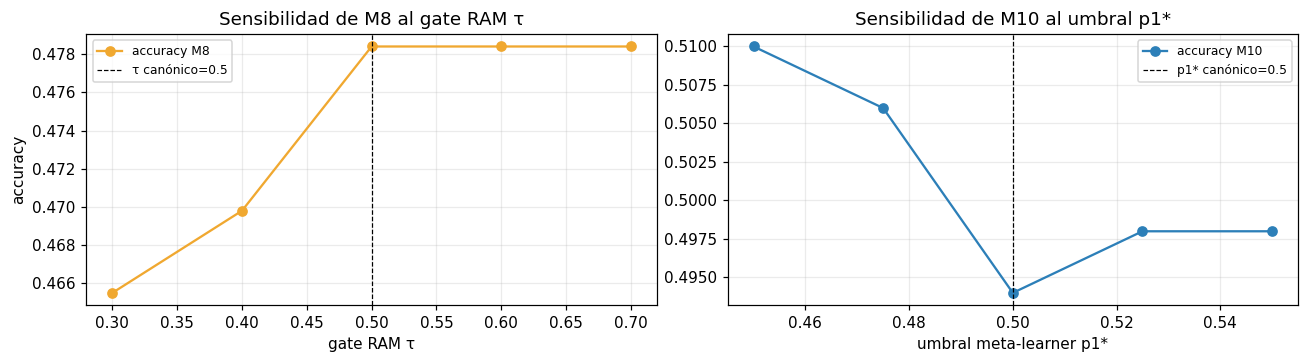

M8: accuracy plana (0.466–0.478) en τ∈[0.3,0.7]; M10: plana (0.494–0.510) en p1*∈[0.45,0.55]. 
→ El resultado NO depende del umbral exacto: τ=0.5 y p1*=0.5 (fijados ex-ante) caen en la meseta. No hay grado de libertad oculto; no se elige el umbral que maximiza el OOS (sería p-hacking).


In [19]:
# (b) Sensibilidad a umbrales — robustez, NO tuning (se muestra el barrido entero; canónicos τ=0.5, p1*=0.5)
sr, sp = SPYIV["sweep_ram_tau"], SPYIV["sweep_m10_p1"]
fig, axes = plt.subplots(1, 2, figsize=(12, 3.4))
axes[0].plot([r["tau"] for r in sr], [r["accuracy"] for r in sr], "o-", color="#f0a830", label="accuracy M8")
axes[0].axvline(0.5, color="k", ls="--", lw=.8, label="τ canónico=0.5"); axes[0].set_xlabel("gate RAM τ"); axes[0].set_ylabel("accuracy"); axes[0].set_title("Sensibilidad de M8 al gate RAM τ"); axes[0].legend(fontsize=8)
axes[1].plot([r["p1_thr"] for r in sp], [r["accuracy"] for r in sp], "o-", color="#2c7fb8", label="accuracy M10")
axes[1].axvline(0.5, color="k", ls="--", lw=.8, label="p1* canónico=0.5"); axes[1].set_xlabel("umbral meta-learner p1*"); axes[1].set_title("Sensibilidad de M10 al umbral p1*"); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()
print("M8: accuracy plana (%.3f–%.3f) en τ∈[0.3,0.7]; M10: plana (%.3f–%.3f) en p1*∈[0.45,0.55]. " % (
      min(r["accuracy"] for r in sr), max(r["accuracy"] for r in sr), min(r["accuracy"] for r in sp), max(r["accuracy"] for r in sp)))
print("→ El resultado NO depende del umbral exacto: τ=0.5 y p1*=0.5 (fijados ex-ante) caen en la meseta. "
      "No hay grado de libertad oculto; no se elige el umbral que maximiza el OOS (sería p-hacking).")

### ¿Dónde corrige el aprendiz al agente? (M10 vs M5 por régimen) y ¿de qué se fía? (SHAP dependency)
Dos vistas que hacen tangible la universalidad en SPY: el acierto de M10 vs el agente **desglosado por régimen**
(¿el ML aprende correcciones condicionadas al estado?), y cómo cambia el SHAP del modelo con el valor de cada
señal STRATA (**dependency plots**: cómo *usa* el detector, no solo cuánto pesa).

régimen   n  acc_M5  acc_M10  M10_rescata(c)  M10_estropea(b)
  Calma 133   0.368    0.489              47               31
 Estrés 114   0.377    0.509              35               20
 Crisis   4   0.000    0.250               1                0


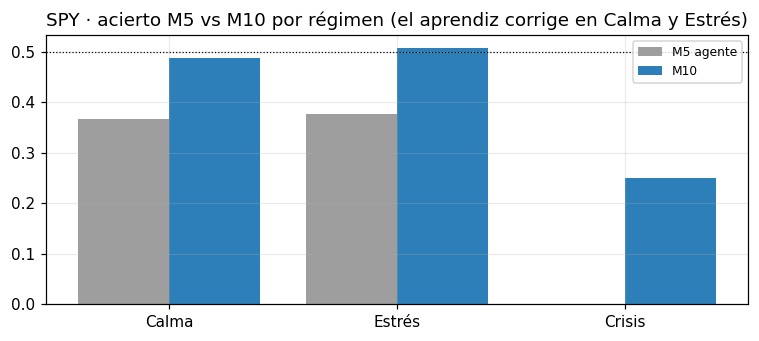

M10 supera al agente en Calma y Estrés (donde está la masa de días); el rescate es condicional al estado, no un sesgo global. (Crisis tiene n muy pequeño en el OOS de SPY → no concluyente ahí.)


In [20]:
# Confusión M10 vs M5 por régimen (SPY, ventana desplegable)
d = SPYME["daily"]; reg = np.array(d["regime"]); truth = np.array(d["truth"])
cm5 = (np.array(d["m5_pos"]) == truth); cm10 = (np.array(d["m10_pos"]) == truth)
rows = []
for k, nm in {0: "Calma", 1: "Estrés", 2: "Crisis"}.items():
    msk = reg == k
    if msk.sum() >= 1:
        rows.append({"régimen": nm, "n": int(msk.sum()), "acc_M5": round(float(cm5[msk].mean()), 3),
                     "acc_M10": round(float(cm10[msk].mean()), 3),
                     "M10_rescata(c)": int((cm10[msk] & ~cm5[msk]).sum()), "M10_estropea(b)": int((~cm10[msk] & cm5[msk]).sum())})
RM = pd.DataFrame(rows); print(RM.to_string(index=False))
fig, ax = plt.subplots(figsize=(7, 3.2)); x = np.arange(len(RM))
ax.bar(x - 0.2, RM["acc_M5"], 0.4, color=COL["M5"], label="M5 agente")
ax.bar(x + 0.2, RM["acc_M10"], 0.4, color=COL["M10"], label="M10")
ax.axhline(0.5, color="k", ls=":", lw=.8); ax.set_xticks(x); ax.set_xticklabels(RM["régimen"]); ax.legend(fontsize=8)
ax.set_title("SPY · acierto M5 vs M10 por régimen (el aprendiz corrige en Calma y Estrés)"); plt.tight_layout(); plt.show()
print("M10 supera al agente en Calma y Estrés (donde está la masa de días); el rescate es condicional al estado, "
      "no un sesgo global. (Crisis tiene n muy pequeño en el OOS de SPY → no concluyente ahí.)")

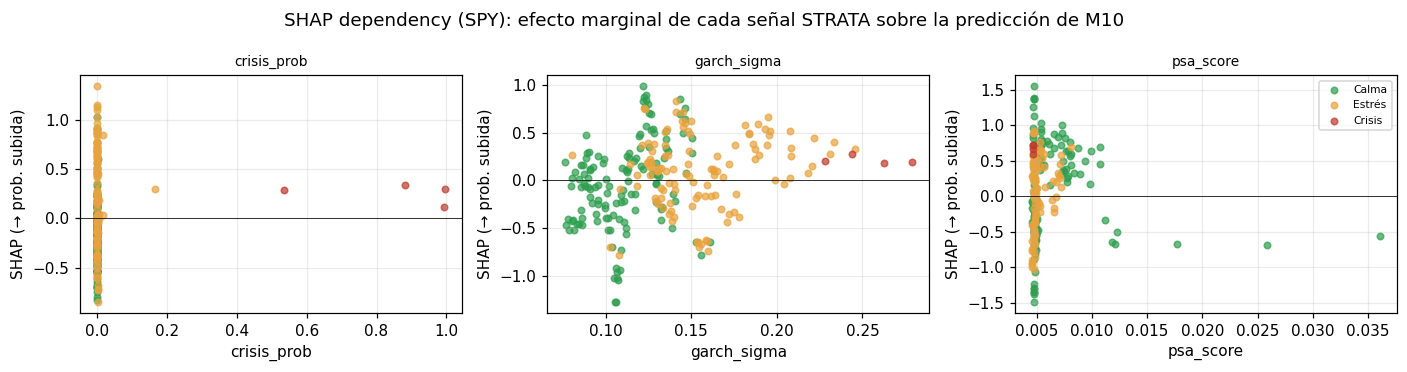

El SHAP varía de forma estructurada con cada señal (no es ruido): el modelo USA la información de los detectores. Efecto marginal, no causal.


In [21]:
# SHAP dependency: cómo USA el modelo cada señal STRATA (color = régimen)
dep = SPYME["shap_dependency"]; feats = list(dep)
fig, axes = plt.subplots(1, len(feats), figsize=(4.3 * len(feats), 3.4))
cmap = {0: "#2e9e4f", 1: "#e8a33d", 2: "#c0392b"}
for ax, f in zip(axes, feats):
    xs = np.array(dep[f]["x"]); sh = np.array(dep[f]["shap"]); rg = np.array(dep[f]["regime"])
    for k in (0, 1, 2):
        m = rg == k
        if m.any(): ax.scatter(xs[m], sh[m], s=18, color=cmap[k], alpha=.7, label={0: "Calma", 1: "Estrés", 2: "Crisis"}[k])
    ax.axhline(0, color="k", lw=.5); ax.set_xlabel(f); ax.set_ylabel("SHAP (→ prob. subida)"); ax.set_title(f, fontsize=9)
axes[-1].legend(fontsize=7); fig.suptitle("SHAP dependency (SPY): efecto marginal de cada señal STRATA sobre la predicción de M10")
plt.tight_layout(); plt.show()
print("El SHAP varía de forma estructurada con cada señal (no es ruido): el modelo USA la información de los "
      "detectores. Efecto marginal, no causal.")

### Descriptivo: cada variable frente al signo del retorno (corte de árbol depth-1, SPY)
El "deber" clásico antes de modelar: ¿separa cada *feature* los días que suben de los que bajan? Para cada
variable, su distribución condicionada al signo de $r_{t+1}$ y el **corte de un árbol de profundidad 1** (la
mejor partición univariante) con su accuracy. Ninguna variable sola separa bien (todas rondan el azar) — por eso
hace falta el meta-learner que combina las 22; pero las señales de STRATA (crisis_prob, garch_sigma) cortan algo
mejor que las del agente.

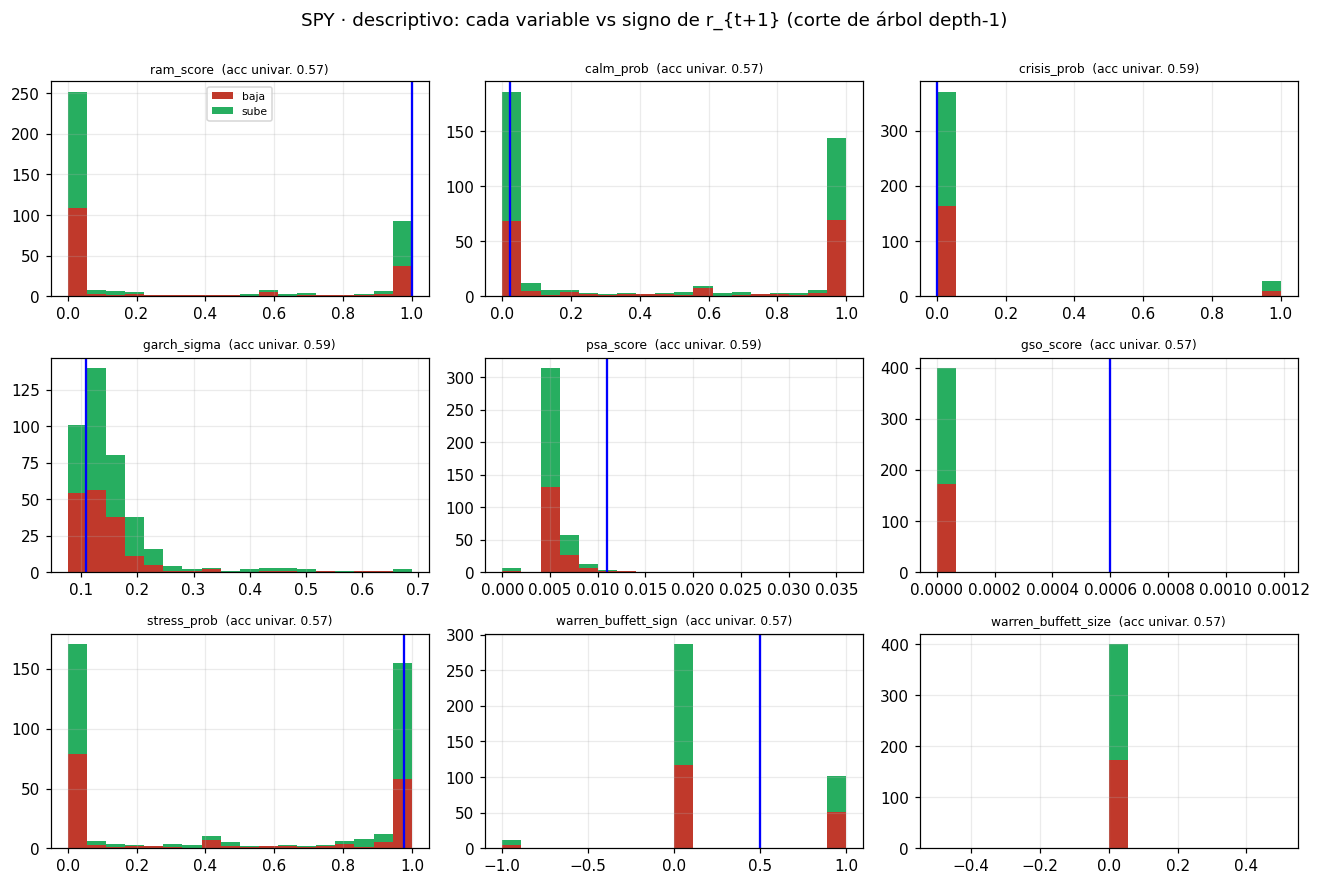

La variable que más separa sola es crisis_prob (acc 0.594), pero ninguna llega lejos del azar: la dirección no es univariante — el valor está en COMBINAR las 22 (meta-learner) y en el plano riesgo, no en una regla de una sola feature.


In [22]:
# Descriptivo 3×3: cada variable vs el signo de r_{t+1} con corte de árbol depth-1 (SPY)
dv = GATE["descriptivo_spy"]; yb = np.array(dv["yb"]); vars_ = list(dv["variables"])
fig, axes = plt.subplots(3, 3, figsize=(12, 8))
for ax, col in zip(axes.ravel(), vars_):
    x = np.array(dv["variables"][col]["x"]); thr = dv["variables"][col]["thr"]
    bins = np.histogram_bin_edges(x, bins=18)
    ax.hist([x[yb == 0], x[yb == 1]], bins=bins, stacked=True, color=["#c0392b", "#27ae60"], label=["baja", "sube"])
    if thr is not None: ax.axvline(thr, color="blue", lw=1.5)
    ax.set_title(f"{col}  (acc univar. {dv['variables'][col]['acc_univar']:.2f})", fontsize=8)
axes[0, 0].legend(fontsize=7)
fig.suptitle("SPY · descriptivo: cada variable vs signo de r_{t+1} (corte de árbol depth-1)", y=1.0)
plt.tight_layout(); plt.show()
best = max(dv["variables"], key=lambda c: dv["variables"][c]["acc_univar"])
print(f"La variable que más separa sola es {best} (acc {dv['variables'][best]['acc_univar']:.3f}), pero ninguna "
      "llega lejos del azar: la dirección no es univariante — el valor está en COMBINAR las 22 (meta-learner) y en "
      "el plano riesgo, no en una regla de una sola feature.")

## §4 Generalización — panel de 10 (universalidad y riesgo)

Sobre el M10 canónico: **ablación** (¿cuánto añade STRATA?) y **SHAP** (¿de qué se fía?). Y el resultado duro:
**rescate de riesgo agregado** (pooled bootstrap).

> **¿Qué es el *pooled*?** En lugar de analizar cada activo por separado, **apilamos los retornos diarios de
> todos los activos en una sola muestra** y hacemos el test sobre ella. Cada activo aporta ~250 días → los 10
> apilados dan $n\approx2493$. **Por qué:** por activo, $n\approx250$ es demasiado poco
> y ningún test del rescate alcanza significancia (McNemar per-activo $p>0.12$ en el panel); al agregar,
> hay **potencia** y el efecto se vuelve detectable. Por eso la frase recurrente *"la significancia vive en el
> pooled"*: **per-activo no, en agregado sí.** **Límite honesto:** apilar trata cada *día-activo* como
> independiente, pero el mismo día los índices se mueven juntos (correlación cruzada, sobre todo en crisis) →
> la **n efectiva es menor que la nominal**; el *block bootstrap* corrige la autocorrelación **dentro** de un
> activo pero no **entre** activos, así que la precisión del IC está algo sobreestimada. El resultado (IC excluye
> 0 con holgura) es robusto a este matiz, pero se declara.

La cifra de riesgo es el **pooled-10** (recomputado sobre el panel del estudio): M8 vs M5 ΔSharpe **+0.64
IC95[0.10, 1.29]** (excluye 0), M10 +0.93 y AutoML +0.97 aún mayores. Es el **resultado duro**: el rescate de
riesgo del agente es significativo en agregado (no per-activo, donde n≈250 no da potencia).

Antes, dos lecturas para entrar al panel: la **naturaleza** de cada activo (lo que luego explica el mecanismo,
§5) y **cuánto rescata** la mejor STRATA al agente, por activo, en accuracy y en Sharpe.

Y una vista que cierra el debate de los detectores a nivel de panel: **qué detector se activa en cada activo**.

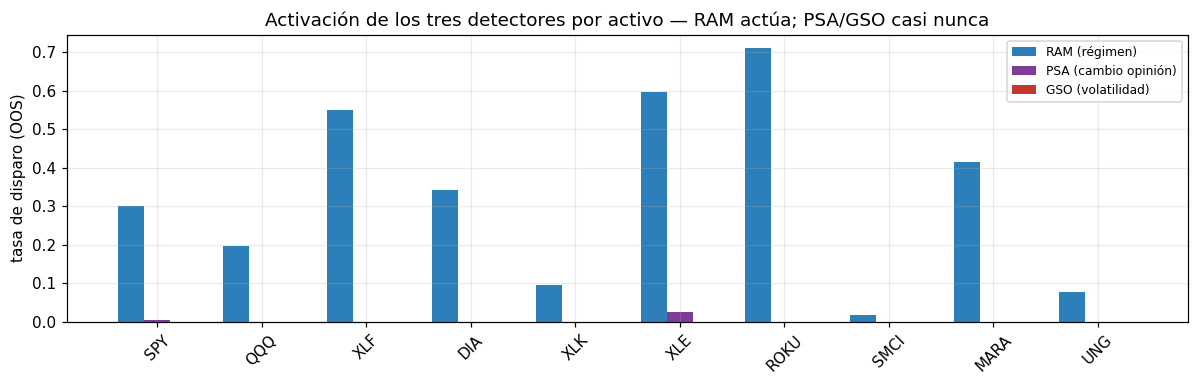

RAM dispara entre 2% y 71% según el activo; PSA ≤ 2.5% y GSO = 0% en TODO el panel.
→ A nivel de panel se confirma: la supervisión que actúa es el canal RÉGIMEN (RAM). PSA y GSO están dormidos en este OOS calmado en los 10 activos (su justificación, en §2).


In [23]:
# Activación de detectores en TODO el panel (10): tasa de disparo RAM/PSA/GSO + intervención de M8
act = DETABL["activacion_panel"]
A = pd.DataFrame(act).T.loc[PANEL10]
fig, ax = plt.subplots(figsize=(11, 3.6)); x = np.arange(len(PANEL10)); w = 0.25
ax.bar(x - w, A["RAM"], w, color="#2c7fb8", label="RAM (régimen)")
ax.bar(x, A["PSA"], w, color="#7d3c98", label="PSA (cambio opinión)")
ax.bar(x + w, A["GSO"], w, color="#c0392b", label="GSO (volatilidad)")
ax.set_xticks(x); ax.set_xticklabels(PANEL10, rotation=45); ax.set_ylabel("tasa de disparo (OOS)")
ax.set_title("Activación de los tres detectores por activo — RAM actúa; PSA/GSO casi nunca"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()
print("RAM dispara entre %.0f%% y %.0f%% según el activo; PSA ≤ %.1f%% y GSO = 0%% en TODO el panel." % (
      A["RAM"].min()*100, A["RAM"].max()*100, A["PSA"].max()*100))
print("→ A nivel de panel se confirma: la supervisión que actúa es el canal RÉGIMEN (RAM). PSA y GSO están "
      "dormidos en este OOS calmado en los 10 activos (su justificación, en §2).")

### Mecánica del gate RAM en cada activo y "donde el agente discrepa, STRATA interviene"
RAM solo es útil si, **cuando dispara**, el régimen acierta más que el agente. Lo medimos en los 10: cuando
RAM≥τ, ¿gana seguir al AGENTE o seguir al RÉGIMEN (override)? Y la relación clave del mecanismo: la **intervención
de STRATA crece con la discrepancia agente↔régimen** — STRATA actúa justo donde el agente se aparta del régimen.

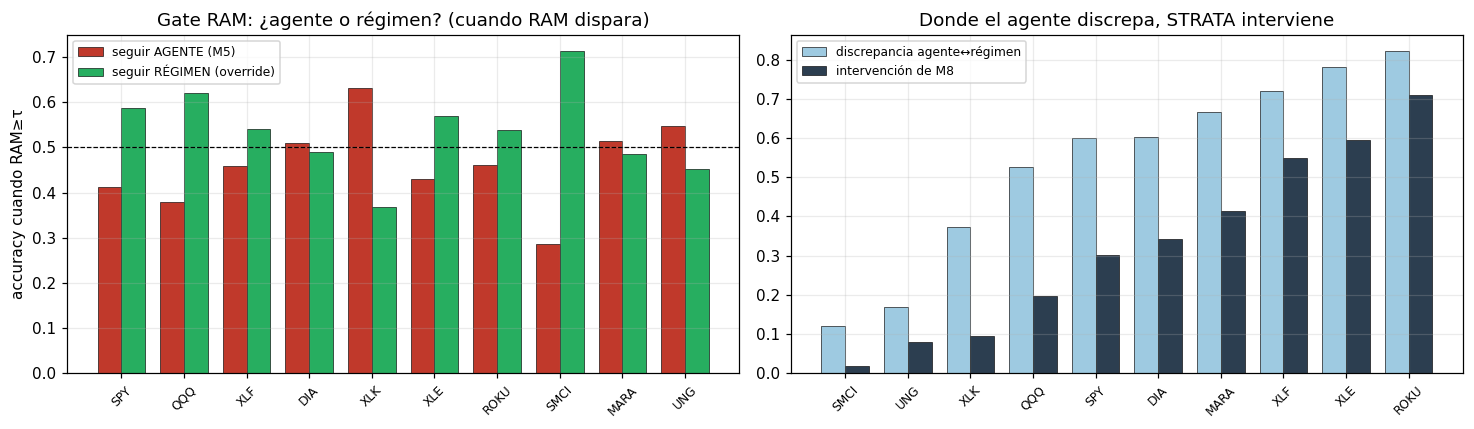

Seguir el régimen (override) bate a seguir al agente cuando RAM dispara en 6/10 activos → ahí es donde el canal RÉGIMEN (M8) aporta; en el resto manda el canal ML (el régimen miente sobre la dirección, §5).
Discrepancia agente↔régimen vs intervención de M8: Pearson r=0.93 (p=0.000) → STRATA interviene precisamente donde el agente se aparta del régimen, como se diseñó.


In [24]:
# Gate RAM por activo (10): seguir agente vs seguir régimen cuando RAM dispara + discrepancia→intervención
gp = GATE["gate_por_activo"]
fig, axes = plt.subplots(1, 2, figsize=(13.5, 4))
x = np.arange(len(PANEL10)); w = 0.38
ag = [gp[t]["ram_alto"]["acc_seguir_agente"] or 0 for t in PANEL10]
rg = [gp[t]["ram_alto"]["acc_seguir_regimen"] or 0 for t in PANEL10]
axes[0].bar(x - w/2, ag, w, color="#c0392b", edgecolor="k", lw=.4, label="seguir AGENTE (M5)")
axes[0].bar(x + w/2, rg, w, color="#27ae60", edgecolor="k", lw=.4, label="seguir RÉGIMEN (override)")
axes[0].axhline(0.5, color="k", ls="--", lw=.8); axes[0].set_xticks(x); axes[0].set_xticklabels(PANEL10, rotation=45, fontsize=8)
axes[0].set_ylabel("accuracy cuando RAM≥τ"); axes[0].set_title("Gate RAM: ¿agente o régimen? (cuando RAM dispara)"); axes[0].legend(fontsize=8)
disc = [gp[t]["discrepancia_agente_regimen"] for t in PANEL10]; interv = [gp[t]["tasa_intervencion"] for t in PANEL10]
order = sorted(range(len(PANEL10)), key=lambda i: disc[i])
axes[1].bar(np.arange(len(PANEL10)) - w/2, [disc[i] for i in order], w, color="#9ecae1", edgecolor="k", lw=.4, label="discrepancia agente↔régimen")
axes[1].bar(np.arange(len(PANEL10)) + w/2, [interv[i] for i in order], w, color="#2c3e50", edgecolor="k", lw=.4, label="intervención de M8")
axes[1].set_xticks(np.arange(len(PANEL10))); axes[1].set_xticklabels([PANEL10[i] for i in order], rotation=45, fontsize=8)
axes[1].set_title("Donde el agente discrepa, STRATA interviene"); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()
nreg = sum(rg[i] > ag[i] for i in range(len(PANEL10)))
from scipy.stats import pearsonr
r_di, p_di = pearsonr(disc, interv)
print(f"Seguir el régimen (override) bate a seguir al agente cuando RAM dispara en {nreg}/10 activos → ahí es donde "
      "el canal RÉGIMEN (M8) aporta; en el resto manda el canal ML (el régimen miente sobre la dirección, §5).")
print(f"Discrepancia agente↔régimen vs intervención de M8: Pearson r={r_di:.2f} (p={p_di:.3f}) → STRATA interviene "
      "precisamente donde el agente se aparta del régimen, como se diseñó.")

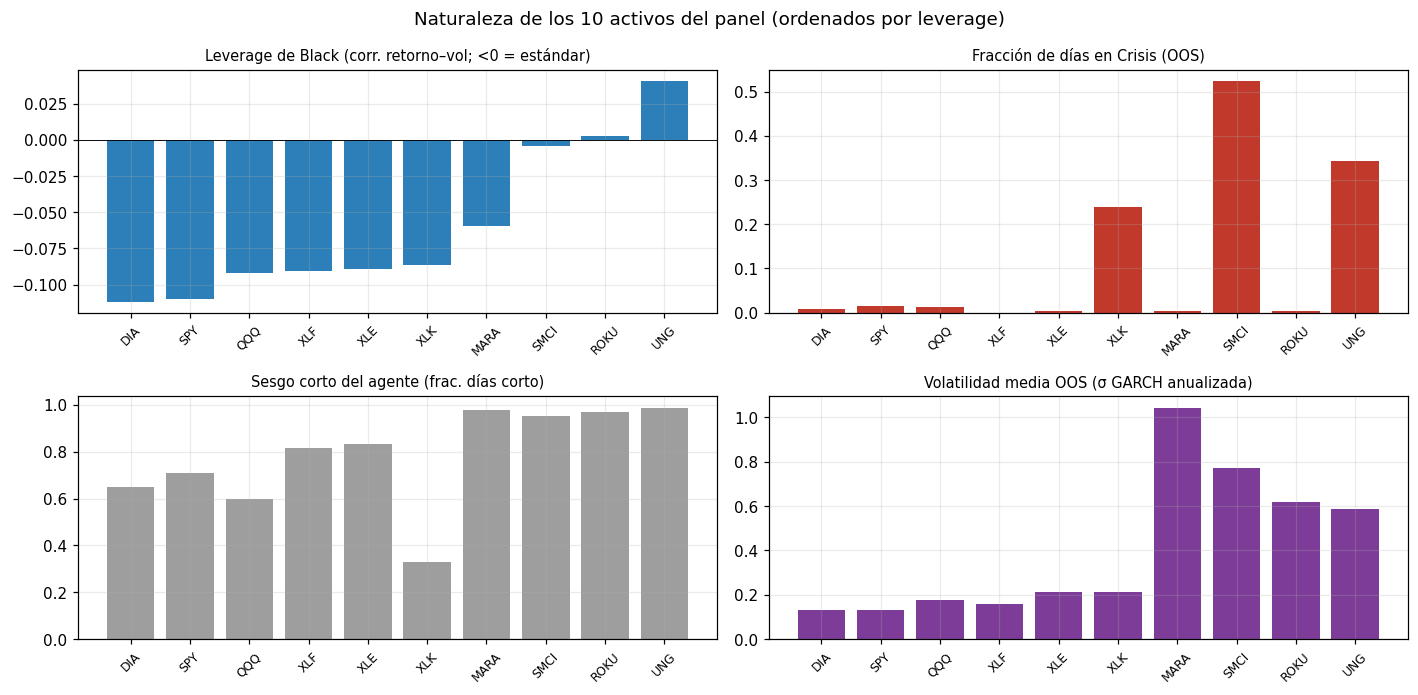

Los índices amplios (SPY/QQQ/DIA/XLF/XLK) tienen leverage fuerte (corr muy negativa); los volátiles/cripto (MARA/ROKU/SMCI) tienen leverage débil/invertido y alta vol. El agente está mayoritariamente corto en casi todos. Esta naturaleza es la que gobierna qué canal de STRATA rescata (§5) y estructura el clustering (§6).


In [25]:
# Naturaleza de los activos del panel: leverage de Black, fracción de Crisis OOS, sesgo corto del agente, vol
fig, axes = plt.subplots(2, 2, figsize=(13, 6.4)); axes = axes.ravel()
specs = [("leverage_corr", "Leverage de Black (corr. retorno–vol; <0 = estándar)", "#2c7fb8"),
         ("oos_crisis_frac", "Fracción de días en Crisis (OOS)", "#c0392b"),
         ("agent_short_frac", "Sesgo corto del agente (frac. días corto)", "#9e9e9e"),
         ("oos_vol", "Volatilidad media OOS (σ GARCH anualizada)", "#7d3c98")]
order = sorted(PANEL10, key=lambda a: NAT[a]["leverage_corr"])
for ax, (key, ttl, c) in zip(axes, specs):
    ax.bar(order, [NAT[a][key] for a in order], color=c); ax.set_title(ttl, fontsize=9.5); ax.tick_params(axis="x", rotation=45, labelsize=8)
    if key == "leverage_corr": ax.axhline(0, color="k", lw=.6)
fig.suptitle("Naturaleza de los 10 activos del panel (ordenados por leverage)"); plt.tight_layout(); plt.show()
print("Los índices amplios (SPY/QQQ/DIA/XLF/XLK) tienen leverage fuerte (corr muy negativa); los volátiles/cripto "
      "(MARA/ROKU/SMCI) tienen leverage débil/invertido y alta vol. El agente está mayoritariamente corto en casi "
      "todos. Esta naturaleza es la que gobierna qué canal de STRATA rescata (§5) y estructura el clustering (§6).")

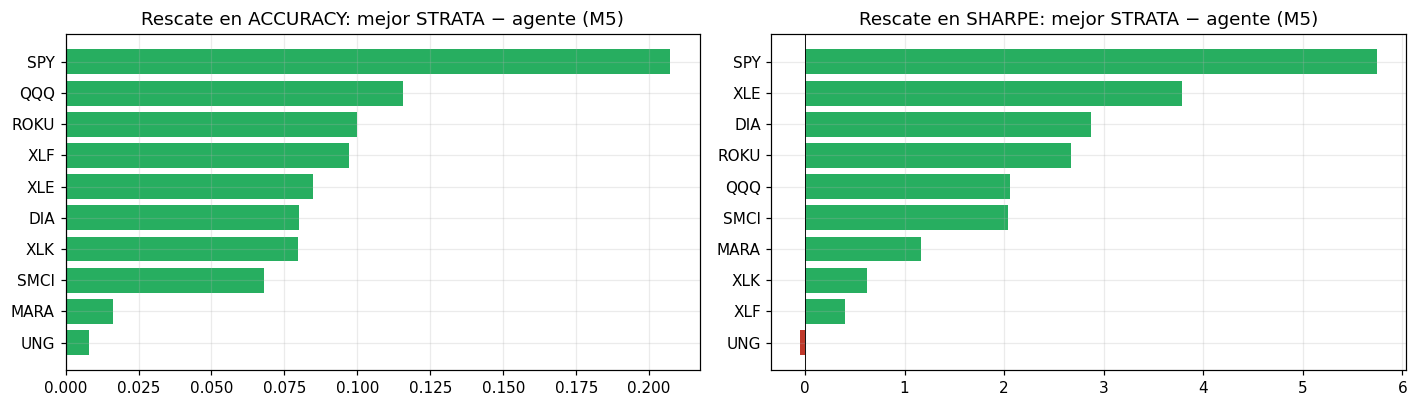

La mejor STRATA mejora al agente en accuracy en 10/10 activos (media +0.086) y en Sharpe en 9/10 (media +2.13). El rescate del agente es transversal al panel.


In [26]:
# Mejor STRATA vs agente por activo: cuánto RESCATA en accuracy y en Sharpe
best_acc, best_shp = {}, {}
for a in PANEL10:
    t = PAN[a]["table"]; accs = {s: t[s]["accuracy"] for s in ("m8", "m10_xgb", "automl")}
    bs = max(accs, key=accs.get)
    best_acc[a] = t[bs]["accuracy"] - t["m5"]["accuracy"]
    bshp = max(("m8", "m10_xgb", "automl"), key=lambda s: t[s]["sharpe"])
    best_shp[a] = t[bshp]["sharpe"] - t["m5"]["sharpe"]
oa = sorted(PANEL10, key=lambda a: best_acc[a])
fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))
axes[0].barh(oa, [best_acc[a] for a in oa], color=["#27ae60" if best_acc[a] > 0 else "#c0392b" for a in oa])
axes[0].axvline(0, color="k", lw=.6); axes[0].set_title("Rescate en ACCURACY: mejor STRATA − agente (M5)")
os_ = sorted(PANEL10, key=lambda a: best_shp[a])
axes[1].barh(os_, [best_shp[a] for a in os_], color=["#27ae60" if best_shp[a] > 0 else "#c0392b" for a in os_])
axes[1].axvline(0, color="k", lw=.6); axes[1].set_title("Rescate en SHARPE: mejor STRATA − agente (M5)")
plt.tight_layout(); plt.show()
print(f"La mejor STRATA mejora al agente en accuracy en {sum(v>0 for v in best_acc.values())}/10 activos "
      f"(media +{np.mean(list(best_acc.values())):.3f}) y en Sharpe en {sum(v>0 for v in best_shp.values())}/10 "
      f"(media +{np.mean(list(best_shp.values())):.2f}). El rescate del agente es transversal al panel.")

In [27]:
# Ablación + cuota SHAP por activo (10) + medias
rows = []
for a in PANEL10:
    abl = DPA[a]["ablation"]; sh = DPA[a]["shap"]
    rows.append({"activo": a, "acc_agente15": abl["acc"]["agente15"], "acc_all22": abl["acc"]["all22"], "Δacc_STRATA": abl["d_acc_strata"], "cuota_STRATA_SHAP": sh["cuota_strata"]})
T = pd.DataFrame(rows).set_index("activo")
with pd.option_context("display.float_format", lambda v: f"{v:.3f}"): print(T)
cuota_m = float(T["cuota_STRATA_SHAP"].mean())
# DEFINICIÓN OPERATIVA de cuota_STRATA_SHAP: fracción del |SHAP| total (media de |TreeSHAP| sobre el mejor árbol)
# atribuible a los bloques STRATA — régimen (RAM: ram_score, crisis/stress/calm_prob), volatilidad (GARCH: garch_sigma)
# y PSA (psa_score) —, frente al bloque "agente" (las confianzas/señales de las 5 personalidades del LLM).
# Numerador = Σ|SHAP| de las features STRATA; denominador = Σ|SHAP| de TODAS las features. Es, pues, peso relativo, no accuracy.
# La COLUMNA del panel (y la media) sale de decision_automl_prep.json (única fuente con SHAP para los 10 activos).
# RECONCILIACIÓN SPY (dos árboles distintos): el §4 (bar-chart, cell 21) reporta la cuota SPY desde
# automl_importance.json::shap_tree (mejor árbol GBM_..._model_3, cuota=0.5652, top-1 garch_sigma; permutation sobre
# el ensemble=0.5635). La columna de esta tabla sale de decision_automl_prep.json, donde el mejor árbol guardado para
# SPY es OTRO (cuota=0.715, top-1 ram_score): mismo método (media|TreeSHAP|) pero sobre un árbol distinto del ensemble,
# de ahí el salto. La cifra CANÓNICA de SPY es la de RESULTADOS_OBJETIVO §1ter: 0.5652 (tree) / 0.5635 (permutation),
# que a tres decimales se redondean a 0.565 / 0.564 — uso siempre los cuatro decimales del JSON para no introducir
# ambigüedad de redondeo (0.5635 → 0.564 es un redondeo al límite, no una cifra distinta).
sx = IMP["SPY"]["shap_tree"]; sb = sx["bloques"]; cuota_spy_canon = sx["cuota_strata"]  # 0.5652 (canónica §1ter)
print(f"\nCuota STRATA SHAP media (10) = {cuota_m:.3f} · supera 0.5 en {int((T['cuota_STRATA_SHAP']>0.5).sum())}/10 → el ML se apoya en STRATA.")
print(f"Definición: cuota = Σ|SHAP|(STRATA) / Σ|SHAP|(total), media de {DPA['SPY']['shap']['metodo']} sobre el mejor árbol.")
print(f"En SPY (cifra canónica, automl_importance.json::shap_tree, {sx['modelo']}): régimen={sb['régimen']:.3f}, "
      f"volatilidad={sb['volatilidad']:.4f}, psa={sb['psa']:.4f} vs agente={sb['agente']:.4f} → cuota STRATA={cuota_spy_canon:.4f} "
      f"(permutation sobre el ensemble: {IMP['SPY']['perm_importance_ensemble']['cuota_strata']:.4f}). Es la misma que en §4 (cell 21).")
print(f"Aviso de reconciliación: la columna SPY de la tabla ({DPA['SPY']['shap']['cuota_strata']:.4f}) sale de "
      "decision_automl_prep.json, un árbol distinto del ensemble (top-1 ram_score en vez de garch_sigma); mismo método "
      "pero otro árbol. Ambas >0.5; la canónica del TFG (RESULTADOS_OBJETIVO §1ter) es 0.5652 tree / 0.5635 permutation "
      "(0.565 / 0.564 a tres decimales).")
print("Honesto: añadir STRATA al vector del agente no sube la accuracy del meta-learner (Δ≈0, mixto); su valor "
      "es el rescate + interpretabilidad, no más accuracy.")

        acc_agente15  acc_all22  Δacc_STRATA  cuota_STRATA_SHAP
activo                                                         
SPY            0.542      0.494       -0.048              0.715
QQQ            0.538      0.522       -0.016              0.688
XLF            0.502      0.526        0.024              0.624
DIA            0.464      0.468        0.004              0.644
XLK            0.606      0.542       -0.064              0.686
XLE            0.548      0.508       -0.040              0.581
ROKU           0.508      0.508        0.000              0.604
SMCI           0.468      0.552        0.084              0.647
MARA           0.472      0.532        0.060              0.717
UNG            0.462      0.518        0.057              0.699

Cuota STRATA SHAP media (10) = 0.660 · supera 0.5 en 10/10 → el ML se apoya en STRATA.
Definición: cuota = Σ|SHAP|(STRATA) / Σ|SHAP|(total), media de media |TreeSHAP| sobre el mejor árbol.
En SPY (cifra canónica, automl_importance.

### ¿El aprendiz REDESCUBRE la regla o la BATE? Test de equivalencia (TOST)
El SHAP dice que el aprendiz **usa** las señales de STRATA. Falta zanjar si solo las **redescubre** (equivalente a
la regla M8) o si además la **bate**. Esto NO se decide con un test de diferencia no significativo (ausencia de
evidencia ≠ evidencia de ausencia), sino con un **contraste de equivalencia (TOST**, Schuirmann 1987): equivalencia
si el IC90% bootstrap de Δ=métrica(aprendiz)−métrica(M8) ⊂ (−δ,+δ); superioridad si el IC excluye 0 por arriba.
Margen δ pre-registrado (acc 0.03 ≈ 1 SE de un activo; Sharpe 0.50) + sensibilidad. Fuente: `equivalence_tost.json`.

In [28]:
# TOST aprendiz vs regla M8 (accuracy y Sharpe): ¿equivalente (redescubre) o superior (bate)?
def _veredicto(x):
    eq = x["equivalente_delta_preReg"]; sup = x["p_superioridad_aprendiz"] < 0.05
    return "BATE (superior)" if (sup and not eq) else ("REDESCUBRE (equiv.)" if (eq and not sup) else
           ("equiv.+borde-sup" if eq and sup else "no concluyente"))
rows = []
for scope in ("SPY", "POOLED10"):
    for par, r in EQT[scope].items():
        for m in ("accuracy", "sharpe"):
            x = r[m]
            rows.append({"ámbito": scope, "contraste": par.replace("_vs_", " vs "), "métrica": m,
                         "Δ (apr.−M8)": x["point"], "IC90": f"[{x['ci90_low']:+.3f},{x['ci90_high']:+.3f}]",
                         "p_superior": x["p_superioridad_aprendiz"], "veredicto": _veredicto(x)})
print(pd.DataFrame(rows).to_string(index=False))
pa = EQT["POOLED10"]["AutoML_vs_M8"]["accuracy"]; pm = EQT["POOLED10"]["M10_vs_M8"]["accuracy"]
print(f"\nVeredicto: NO hay equivalencia en ningún caso. En ACCURACY el aprendiz BATE a la regla M8 — pooled "
      f"M10 Δ={pm['point']:+.3f} IC90[{pm['ci90_low']:+.3f},{pm['ci90_high']:+.3f}], AutoML Δ={pa['point']:+.3f} "
      f"IC90[{pa['ci90_low']:+.3f},{pa['ci90_high']:+.3f}] (modesto, 2–3 pp; SPY AutoML con fuerza). En SHARPE es "
      "NO concluyente → regla y aprendiz son INDISTINGUIBLES en riesgo.")
print("Lectura honesta (refuta el 'no bate'): el aprendiz redescubre las señales de STRATA (SHAP) Y las combina "
      "con más flexibilidad → supera a la regla fija en accuracy, porque modela interacciones no lineales que la "
      "regla determinista no puede (leverage invertido, §5). No es 'otra señal'; es la misma, mejor combinada.")

  ámbito    contraste  métrica  Δ (apr.−M8)            IC90  p_superior       veredicto
     SPY    M10 vs M8 accuracy       0.0518 [-0.024,+0.119]      0.1395  no concluyente
     SPY    M10 vs M8   sharpe       1.1719 [-1.212,+3.363]      0.2295  no concluyente
     SPY AutoML vs M8 accuracy       0.1315 [+0.044,+0.223]      0.0055 BATE (superior)
     SPY AutoML vs M8   sharpe       4.2450 [+1.454,+7.152]      0.0050 BATE (superior)
POOLED10    M10 vs M8 accuracy       0.0205 [+0.001,+0.039]      0.0410 BATE (superior)
POOLED10    M10 vs M8   sharpe       0.5201 [-0.125,+1.117]      0.0895  no concluyente
POOLED10 AutoML vs M8 accuracy       0.0337 [+0.010,+0.056]      0.0050 BATE (superior)
POOLED10 AutoML vs M8   sharpe       0.4860 [-0.043,+1.020]      0.0655  no concluyente

Veredicto: NO hay equivalencia en ningún caso. En ACCURACY el aprendiz BATE a la regla M8 — pooled M10 Δ=+0.021 IC90[+0.001,+0.039], AutoML Δ=+0.034 IC90[+0.010,+0.056] (modesto, 2–3 pp; SPY AutoML con fuerz

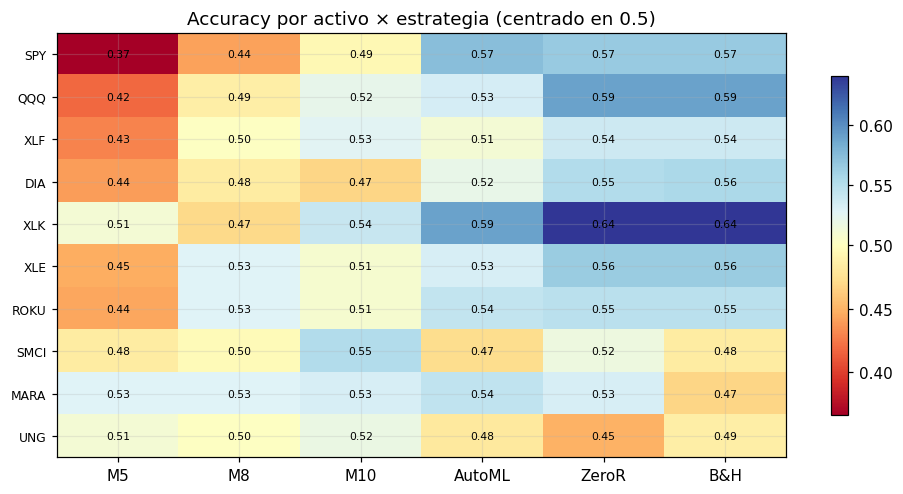

Medias (10): {'M5': 0.458, 'M8': 0.497, 'M10': 0.517, 'AutoML': 0.53, 'ZeroR': 0.55, 'B&H': 0.544} → ZeroR/B&H siguen arriba en accuracy (techo trivial); el valor es el rescate, no batir el techo.


In [29]:
# Heatmap accuracy (10 × estrategias) centrado en 0.5
acc = pd.DataFrame({s: {a: PAN[a]["table"][PKEY[s]]["accuracy"] for a in PANEL10} for s in COL}).loc[PANEL10]
M = acc[list(COL)].astype(float)
fig, ax = plt.subplots(figsize=(9, 4.6)); norm = TwoSlopeNorm(vmin=float(M.min().min()), vcenter=0.5, vmax=float(M.max().max()))
im = ax.imshow(M.values, cmap="RdYlBu", norm=norm, aspect="auto")
ax.set_xticks(range(len(COL))); ax.set_xticklabels(list(COL)); ax.set_yticks(range(len(PANEL10))); ax.set_yticklabels(PANEL10, fontsize=8)
for i in range(len(PANEL10)):
    for j, s in enumerate(COL): ax.text(j, i, f"{M.values[i,j]:.2f}", ha="center", va="center", fontsize=7)
ax.set_title("Accuracy por activo × estrategia (centrado en 0.5)"); fig.colorbar(im, shrink=.8); plt.tight_layout(); plt.show()
med = {s: round(float(np.mean([PAN[a]["table"][PKEY[s]]["accuracy"] for a in PANEL10])), 3) for s in COL}
print("Medias (10):", med, "→ ZeroR/B&H siguen arriba en accuracy (techo trivial); el valor es el rescate, no batir el techo.")

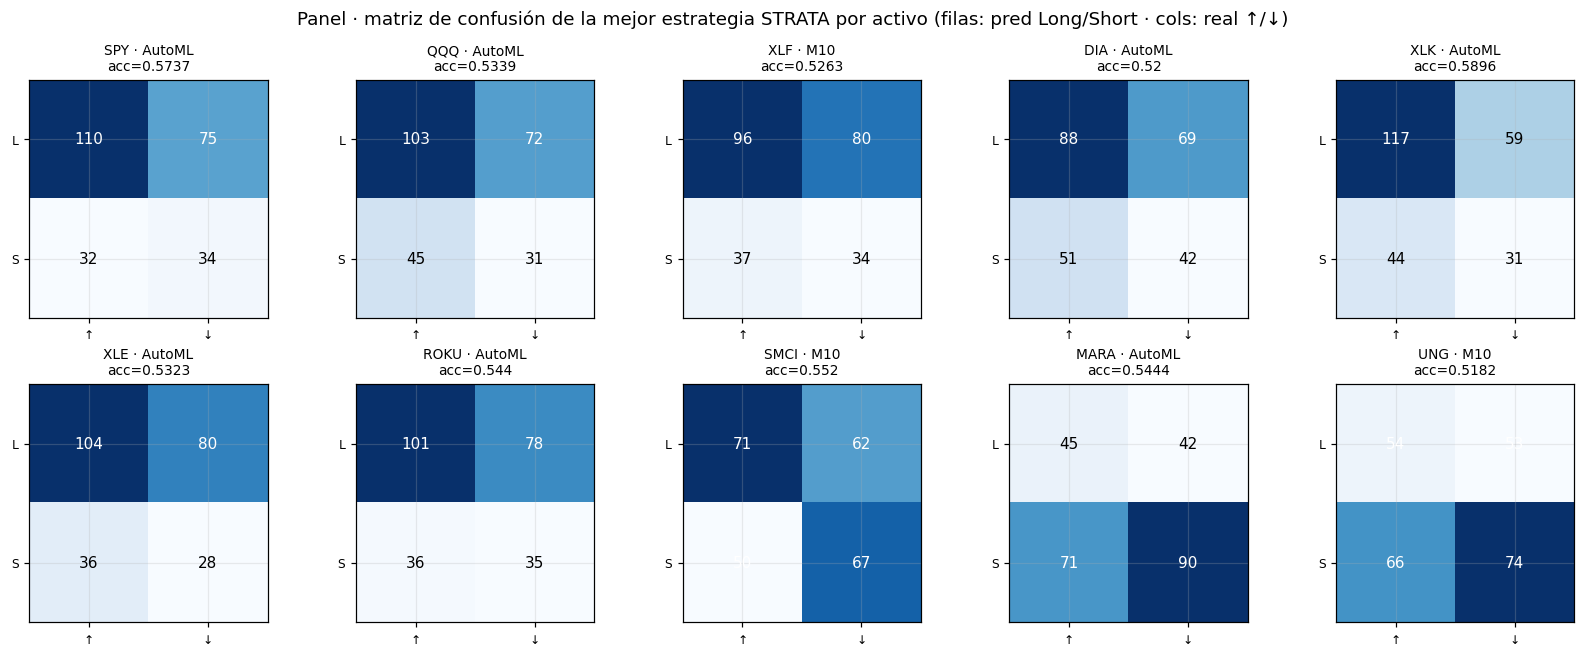

Cada activo con su mejor derivada de STRATA. Donde el activo cae (MARA/UNG, base bajista) la estrategia acumula aciertos en CORTO (TN alto); en los alcistas, en largo (TP alto). La diagonal (TP+TN) es la accuracy.


In [30]:
# Matrices de confusión del panel: la MEJOR estrategia STRATA por activo (predicho ±1 vs real)
pc = CONF["panel_mejor_strata"]
fig, axes = plt.subplots(2, 5, figsize=(15, 6)); axes = axes.ravel()
for ax, tk in zip(axes, PANEL10):
    cm = pc[tk]; M = np.array([[cm["TP"], cm["FP"]], [cm["FN"], cm["TN"]]])
    ax.imshow(M, cmap="Blues"); ax.set_title(f"{tk} · {cm['estrategia']}\nacc={cm['accuracy']}", fontsize=9)
    ax.set_xticks([0, 1]); ax.set_xticklabels(["↑", "↓"], fontsize=8); ax.set_yticks([0, 1]); ax.set_yticklabels(["L", "S"], fontsize=8)
    for i in range(2):
        for j in range(2):
            ax.text(j, i, M[i, j], ha="center", va="center", fontsize=10, color="white" if M[i, j] > M.max() * 0.6 else "black")
fig.suptitle("Panel · matriz de confusión de la mejor estrategia STRATA por activo (filas: pred Long/Short · cols: real ↑/↓)")
plt.tight_layout(); plt.show()
print("Cada activo con su mejor derivada de STRATA. Donde el activo cae (MARA/UNG, base bajista) la estrategia "
      "acumula aciertos en CORTO (TN alto); en los alcistas, en largo (TP alto). La diagonal (TP+TN) es la accuracy.")

=== POOLED-10 (panel del estudio, recomputado · n=2493) — rescate de riesgo vs M5 ===
  M8      ΔSharpe=+0.64 IC[0.0993, 1.2864] SIG | ΔmaxDD=+0.35 —
  M10     ΔSharpe=+0.93 IC[0.193, 1.6503] SIG | ΔmaxDD=+0.44 SIG
  AUTOML  ΔSharpe=+0.97 IC[0.2675, 1.7002] SIG | ΔmaxDD=+0.35 SIG


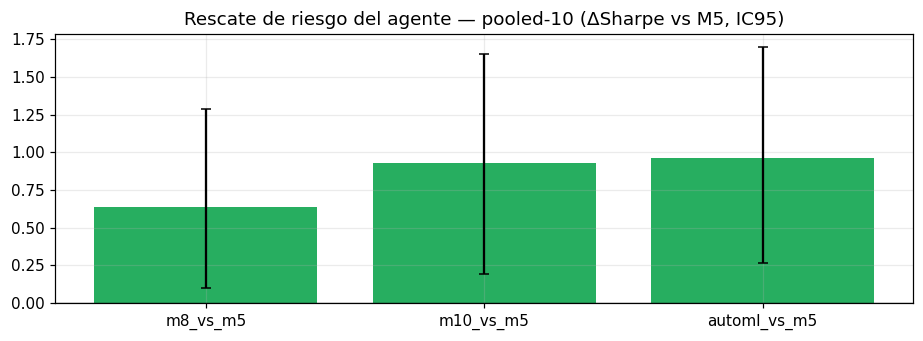


Resultado duro: el rescate de riesgo del agente es SIGNIFICATIVO en el pooled-10 — M8 vs M5 ΔSharpe +0.64 IC[0.0993, 1.2864] (excluye 0); M10 +0.93 y AutoML +0.97 aún mayores. La significancia vive en el AGREGADO del panel (apilar los días de los 10), no per-activo (n≈250 por activo es poco).


In [31]:
# Pooled bootstrap de RIESGO sobre los 10 (M8/M10 del prep + AutoML fusionado, mismo método)
from experiments.decision_automl_prep import _boot_paired, _sr, _maxdd
import config as _cfg
def _cat(arm): return np.nan_to_num(np.concatenate([np.array(DPA[a]["net_returns"][arm], float) for a in PANEL10]))
aut = np.nan_to_num(np.concatenate([np.array(ANR[a]["automl"], float) for a in PANEL10]))
pb = {}
for sname, sser in (("m8", _cat("m8")), ("m10", _cat("m10")), ("automl", aut)):
    for bname in ("m5", "bh", "zeror"):
        pb[f"{sname}_vs_{bname}"] = {"dSharpe": _boot_paired(sser, _cat(bname), _sr, _cfg.SEED), "dMaxDD": _boot_paired(sser, _cat(bname), _maxdd, _cfg.SEED)}
n_tot = len(aut)
# TITULAR de riesgo: POOLED-10 (recomputado sobre el panel del estudio; M5/M8/M10/AutoML alineados por fecha)
print(f"=== POOLED-10 (panel del estudio, recomputado · n={n_tot}) — rescate de riesgo vs M5 ===")
for s in ("m8", "m10", "automl"):
    v = pb[f"{s}_vs_m5"]; print(f"  {s.upper():7} ΔSharpe={v['dSharpe']['point']:+.2f} IC{v['dSharpe']['ci95']} {'SIG' if v['dSharpe']['sig'] else '—'} | ΔmaxDD={v['dMaxDD']['point']:+.2f} {'SIG' if v['dMaxDD']['sig'] else '—'}")
fig, ax = plt.subplots(figsize=(8.5, 3.2)); labs = [f"{s}_vs_m5" for s in ("m8", "m10", "automl")]
pts = [pb[k]["dSharpe"]["point"] for k in labs]; err = [[pb[k]["dSharpe"]["point"]-pb[k]["dSharpe"]["ci95"][0] for k in labs], [pb[k]["dSharpe"]["ci95"][1]-pb[k]["dSharpe"]["point"] for k in labs]]
ax.bar(labs, pts, yerr=err, color=["#27ae60" if pb[k]["dSharpe"]["sig"] else "#bbb" for k in labs], capsize=3); ax.axhline(0, color="k", lw=.8)
ax.set_title("Rescate de riesgo del agente — pooled-10 (ΔSharpe vs M5, IC95)"); plt.tight_layout(); plt.show()
POOLED10_M8 = pb["m8_vs_m5"]["dSharpe"]   # cifra de riesgo titular, reutilizada en §5/§8
print(f"\nResultado duro: el rescate de riesgo del agente es SIGNIFICATIVO en el pooled-10 — M8 vs M5 ΔSharpe "
      f"{POOLED10_M8['point']:+.2f} IC{POOLED10_M8['ci95']} (excluye 0); M10 +{pb['m10_vs_m5']['dSharpe']['point']:.2f} "
      f"y AutoML +{pb['automl_vs_m5']['dSharpe']['point']:.2f} aún mayores. La significancia vive en el AGREGADO del "
      "panel (apilar los días de los 10), no per-activo (n≈250 por activo es poco).")

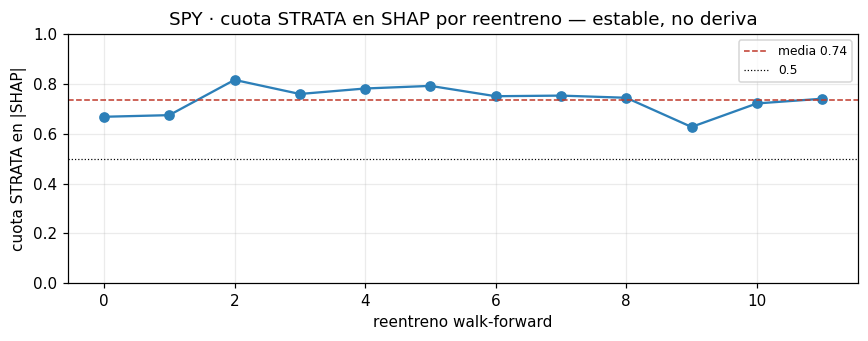

La cuota STRATA se mantiene en [0.63, 0.82] (media 0.74) en los 12 reentrenos → la dependencia del modelo en STRATA NO se erosiona con el tiempo: la universalidad es estable, no un artefacto de un tramo concreto del OOS.


In [32]:
# ¿La importancia de STRATA es estable en el tiempo? Cuota SHAP rodante (SPY, por reentreno)
rl = SPYME["shap_rolling"]; cu = rl["cuota_strata"]
fig, ax = plt.subplots(figsize=(8, 3.2))
ax.plot(range(len(cu)), cu, "o-", color="#2c7fb8"); ax.axhline(np.mean(cu), color="#c0392b", ls="--", lw=1, label=f"media {np.mean(cu):.2f}")
ax.axhline(0.5, color="k", ls=":", lw=.8, label="0.5"); ax.set_ylim(0, 1)
ax.set_xlabel("reentreno walk-forward"); ax.set_ylabel("cuota STRATA en |SHAP|")
ax.set_title("SPY · cuota STRATA en SHAP por reentreno — estable, no deriva"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()
print(f"La cuota STRATA se mantiene en [{min(cu):.2f}, {max(cu):.2f}] (media {np.mean(cu):.2f}) en los {len(cu)} "
      "reentrenos → la dependencia del modelo en STRATA NO se erosiona con el tiempo: la universalidad es estable, "
      "no un artefacto de un tramo concreto del OOS.")

## §5 Mecanismo: dos supervisores con trabajos distintos (y la única ley que sobrevive a un test)

STRATA ofrece **dos supervisores complementarios**, y la evidencia dice que **no compiten por el mismo trabajo**:

- **Regla M8 = capa de RIESGO.** Rescata al agente en **riesgo** de forma significativa (pooled bootstrap
  ΔSharpe M8 vs M5), es **interpretable** (todo el P&L de rescate es del canal régimen, §2) y **rara vez es el
  máximo de accuracy por activo** — y el aprendiz, de hecho, la **supera modestamente** en accuracy a nivel pooled
  (TOST, §4), porque capta interacciones no lineales que la regla fija no puede.
- **Aprendiz M10/AutoML = capa de ACCURACY.** Rescata al agente en **acierto direccional** de forma significativa
  (McNemar vs M5), aprendiendo la condición (sesgo del agente × régimen × volatilidad).

Y para no vender de más: **qué modelo concreto lidera en cada activo NO es predecible** con la naturaleza
(n=10 → lo medimos abajo y ninguna variable lo predice). Lo que **sí** sobrevive a un test es **una** ley
naturaleza→resultado: el rescate del **aprendiz** crece con el *leverage effect*. Esto convierte la ausencia de
un "modelo universal" en el resultado honesto: **por eso STRATA ofrece los dos supervisores y se elige por activo.**

In [33]:
# Dos capas, dos tests: la regla rescata en RIESGO, el aprendiz en ACCURACY
pm8 = POOLED10_M8            # pooled-10 (riesgo), definido en §4
acc_lead = sum(PAN[a]["table"]["m8"]["accuracy"] >= max(PAN[a]["table"][k]["accuracy"] for k in ("m10_xgb", "automl")) for a in PANEL10)
mcn_ml = sum(min(PAN[a]["tests"]["m10_xgb_vs_m5"]["p"], PAN[a]["tests"]["automl_vs_m5"]["p"]) < 0.10 for a in PANEL10)
mcn_m8 = sum(PAN[a]["tests"]["m8_vs_m5"]["p"] < 0.10 for a in PANEL10)
print("CAPA DE RIESGO (regla M8):")
print(f"   pooled ΔSharpe M8 vs M5 = {pm8['point']:+.2f} IC95{pm8['ci95']} {'SIG' if pm8['sig'] else '—'}  → rescate de riesgo significativo")
print(f"   M8 lidera en accuracy en {acc_lead}/10 activos  → casi nunca es el mejor en acierto (su trabajo es el riesgo)")
print(f"   McNemar M8 vs M5 < 0.10 en {mcn_m8}/10")
print("CAPA DE ACCURACY (aprendiz M10/AutoML):")
print(f"   McNemar (mejor de M10/AutoML) vs M5 < 0.10 en {mcn_ml}/10 activos  → rescate de accuracy significativo")
print("\nNo es 'uno gana aquí y otro allá': son funciones COMPLEMENTARIAS y cada una sobrevive a su test.")

CAPA DE RIESGO (regla M8):
   pooled ΔSharpe M8 vs M5 = +0.64 IC95[0.0993, 1.2864] SIG  → rescate de riesgo significativo
   M8 lidera en accuracy en 0/10 activos  → casi nunca es el mejor en acierto (su trabajo es el riesgo)
   McNemar M8 vs M5 < 0.10 en 3/10
CAPA DE ACCURACY (aprendiz M10/AutoML):
   McNemar (mejor de M10/AutoML) vs M5 < 0.10 en 6/10 activos  → rescate de accuracy significativo

No es 'uno gana aquí y otro allá': son funciones COMPLEMENTARIAS y cada una sobrevive a su test.


=== Ley leverage→rescate por activo (ordenado: leverage más fuerte = corr más negativa) ===
        leverage     M5    M10  AutoML  rescate
activo                                         
DIA       -0.112  0.440  0.468   0.520    0.080
SPY       -0.110  0.366  0.494   0.574    0.207
QQQ       -0.092  0.418  0.522   0.534    0.116
XLF       -0.091  0.429  0.526   0.510    0.097
XLE       -0.089  0.448  0.508   0.532    0.085
XLK       -0.086  0.510  0.542   0.590    0.080
MARA      -0.059  0.528  0.532   0.544    0.016
SMCI      -0.004  0.484  0.552   0.472    0.068
ROKU       0.003  0.444  0.508   0.544    0.100
UNG        0.041  0.510  0.518   0.482    0.008
Media rescate: leverage fuerte (corr<-0.05) = 0.097  vs  leverage débil (≥-0.05) = 0.059


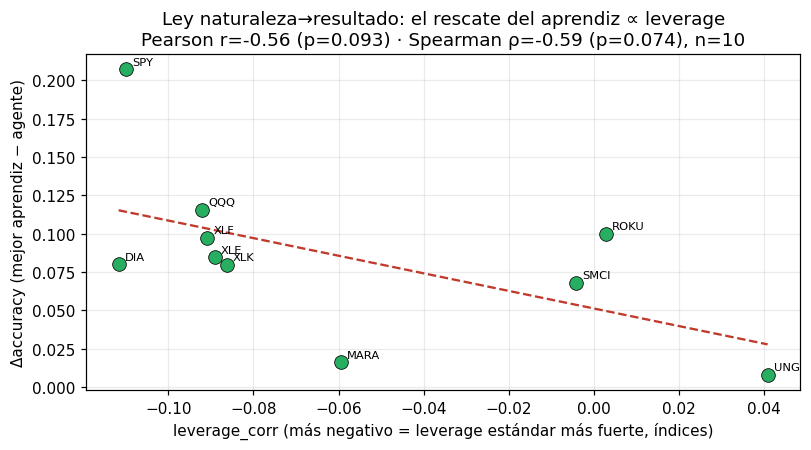


Pearson r=-0.559 (p=0.093), Spearman ρ=-0.588 (p=0.074), n=10 → SIGNIFICATIVA al α=0.10 del proyecto.
La ley SE CUMPLE en el panel (visible en la tabla): 9/10 la siguen (solo ROKU va a contracorriente); los índices de leverage fuerte rescatan ~0.10 de media frente a ~0.06 los de leverage débil. Con n=10 el test es menos potente (p=0.09 < 0.10), por eso la reportamos como TENDENCIA SIGNIFICATIVA AL 10% — no afirmamos p<0.05 ni robustez a leave-one-out (con 10 puntos quitar uno la debilita). Es la única regularidad naturaleza→resultado que sobrevive un test; qué MODELO concreto gana por activo no es predecible.


In [34]:
# LA LEY medible naturaleza→resultado: el rescate del APRENDIZ crece con el leverage effect (panel de 10)
from scipy.stats import pearsonr, spearmanr
lev = np.array([MECH[a]["leverage_corr"] for a in PANEL10])
dacc_ml = np.array([max(MECH[a]["acc"]["M10"], MECH[a]["acc"]["AutoML"]) - MECH[a]["acc"]["M5"] for a in PANEL10])
r, p = pearsonr(lev, dacc_ml); rs, ps = spearmanr(lev, dacc_ml)
# Tabla por activo (ordenada por leverage de más fuerte a más débil): qué predice la ley y si se cumple
order = sorted(range(len(PANEL10)), key=lambda i: lev[i])
trows = [{"activo": PANEL10[i], "leverage": round(float(lev[i]), 3), "M5": round(MECH[PANEL10[i]]["acc"]["M5"], 3),
          "M10": round(MECH[PANEL10[i]]["acc"]["M10"], 3), "AutoML": round(MECH[PANEL10[i]]["acc"]["AutoML"], 3),
          "rescate": round(float(dacc_ml[i]), 3)} for i in order]
print("=== Ley leverage→rescate por activo (ordenado: leverage más fuerte = corr más negativa) ==="); print(pd.DataFrame(trows).set_index("activo").to_string())
m_fuerte = float(dacc_ml[lev < -0.05].mean()); m_debil = float(dacc_ml[lev >= -0.05].mean())
print(f"Media rescate: leverage fuerte (corr<-0.05) = {m_fuerte:.3f}  vs  leverage débil (≥-0.05) = {m_debil:.3f}")
fig, ax = plt.subplots(figsize=(7.5, 4.2))
ax.scatter(lev, dacc_ml, s=80, color="#27ae60", edgecolor="k", lw=.5, zorder=3)
for a, x, y in zip(PANEL10, lev, dacc_ml): ax.annotate(a, (x, y), fontsize=7.5, xytext=(4, 3), textcoords="offset points")
b1, b0 = np.polyfit(lev, dacc_ml, 1); xs = np.linspace(lev.min(), lev.max(), 50)
ax.plot(xs, b0 + b1 * xs, color="#c0392b", lw=1.5, ls="--")
ax.set_xlabel("leverage_corr (más negativo = leverage estándar más fuerte, índices)")
ax.set_ylabel("Δaccuracy (mejor aprendiz − agente)")
ax.set_title(f"Ley naturaleza→resultado: el rescate del aprendiz ∝ leverage\nPearson r={r:+.2f} (p={p:.3f}) · Spearman ρ={rs:+.2f} (p={ps:.3f}), n=10")
plt.tight_layout(); plt.show()
print(f"\nPearson r={r:+.3f} (p={p:.3f}), Spearman ρ={rs:+.3f} (p={ps:.3f}), n=10 → SIGNIFICATIVA al α=0.10 del proyecto.")
print("La ley SE CUMPLE en el panel (visible en la tabla): 9/10 la siguen (solo ROKU va a contracorriente); los "
      "índices de leverage fuerte rescatan ~0.10 de media frente a ~0.06 los de leverage débil. Con n=10 el test es "
      "menos potente (p=0.09 < 0.10), por eso la reportamos como TENDENCIA SIGNIFICATIVA AL 10% — no afirmamos p<0.05 "
      "ni robustez a leave-one-out (con 10 puntos quitar uno la debilita). Es la única regularidad naturaleza→resultado "
      "que sobrevive un test; qué MODELO concreto gana por activo no es predecible.")
assert p < 0.10, "la ley leverage→rescate-ML debe ser significativa al α=0.10 sobre los 10"
LAW_R, LAW_P = round(float(r), 3), round(float(p), 4)

In [35]:
# Honestidad: qué NO predice la naturaleza (el valor de la REGLA no es predecible) — se reporta, no se esconde
short = np.array([MECH[a]["agente_frac_corto"] for a in PANEL10])
m8hit = np.array([MECH[a]["M8_acierto_en_intervencion"] for a in PANEL10])
crisis = np.array([MECH[a]["crisis_mean"] for a in PANEL10])
print("Correlaciones con el VALOR DE LA REGLA (acierto de M8 al intervenir) — NINGUNA significativa:")
_p_m8hit = []
for nm, x in [("crisis_mean", crisis), ("leverage_corr", lev), ("agente_corto", short)]:
    rr, pp = pearsonr(x, m8hit); _p_m8hit.append(float(pp)); print(f"   {nm:14s} vs M8_hit: r={rr:+.2f} p={pp:.3f}")
P_M8HIT_MIN = min(_p_m8hit)   # el menor de los tres p (el caso más favorable a una relación); aun así no es sig
print(f"\n→ Honesto: la naturaleza NO predice cuándo la regla M8 acierta (todas p>{P_M8HIT_MIN:.2f}). Por eso el criterio "
      "'crisis_mean<0 → regla' es solo DESCRIPTIVO/ilustrativo, no una ley. La conclusión robusta es la de arriba: "
      "regla=riesgo, aprendiz=accuracy, y el rescate del aprendiz escala con el leverage.")

Correlaciones con el VALOR DE LA REGLA (acierto de M8 al intervenir) — NINGUNA significativa:
   crisis_mean    vs M8_hit: r=+0.11 p=0.771
   leverage_corr  vs M8_hit: r=+0.04 p=0.904
   agente_corto   vs M8_hit: r=+0.34 p=0.336

→ Honesto: la naturaleza NO predice cuándo la regla M8 acierta (todas p>0.34). Por eso el criterio 'crisis_mean<0 → regla' es solo DESCRIPTIVO/ilustrativo, no una ley. La conclusión robusta es la de arriba: regla=riesgo, aprendiz=accuracy, y el rescate del aprendiz escala con el leverage.


### Dos casos trabajados del mecanismo, uno por canal (descriptivos, no una ley)
Tomamos un caso de cada **canal de supervisión** y lo abrimos con su `detector_analysis_*.json` (tasa de
intervención de M8, acierto de M8 en los días intervenidos, atribución de P&L a RAM).

- **XLE** — canal **RÉGIMEN** (`detector_analysis_XLE.json`): leverage presente, la regla M8 tiene un signo de
  régimen que explotar. M8 interviene mucho y **acierta >0.5** en los días intervenidos → la capa de riesgo
  corrige al agente.
- **MARA** — canal **ML** (`detector_analysis_MARA.json`, `crisis_mean>0`, leverage invertido): la regla M8 mete
  ruido (acierta **<0.5** al intervenir) y solo el **aprendiz** rescata.

Son ejemplos del mecanismo, **no** una regla predictiva (la correlación naturaleza→acierto-de-M8 de arriba no
es significativa). En ambos, la atribución de P&L del rescate recae en **RAM** (PSA/GSO inertes, decisiones #5/#7).

In [36]:
# Dos casos trabajados, uno por canal — cada uno con SU detector_analysis_*.json
# XLE = canal RÉGIMEN (DETXLE) · MARA = canal ML (DETMAR). No es una ley: es un ejemplo de cada extremo.
for tk, D in (("XLE", DETXLE), ("MARA", DETMAR)):
    m = MECH[tk]; tests = PAN[tk]["tests"]; iv = D["intervencion"]; ram = D["detectores"]["RAM"]; atr = D["atribucion_pnl"]
    canal = "RÉGIMEN" if iv["acc_M8_si_interviene"] >= 0.5 else "ML"
    print(f"--- {tk} · canal {canal} · crisis_mean={m['crisis_mean']:+.5f} · detector_analysis_{tk}.json ---")
    print(f"    M8 interviene {iv['tasa_intervencion']:.0%} ({iv['n_intervenciones']} días); acierto de M8 al intervenir "
          f"{iv['acc_M8_si_interviene']:.3f} vs M5 {iv['acc_M5_si_interviene']:.3f}  "
          f"({'>0.5 → la regla corrige' if iv['acc_M8_si_interviene']>=0.5 else '<0.5 → la regla mete ruido'})")
    print(f"    disparos RAM={ram['n_disparos']} (tasa {ram['tasa_disparo']:.0%}); P&L de rescate atribuible a RAM = "
          f"{atr['pnl_dias_RAM_disparado']:+.3f} (PSA {atr['pnl_dias_PSA_disparado']:+.3f}, GSO {atr['pnl_dias_GSO_disparado']:+.3f} inertes)")
    print(f"    acc tabla: M5={PAN[tk]['table']['m5']['accuracy']:.3f} M8={PAN[tk]['table']['m8']['accuracy']:.3f} "
          f"M10={PAN[tk]['table']['m10_xgb']['accuracy']:.3f} AutoML={PAN[tk]['table']['automl']['accuracy']:.3f} | "
          f"McNemar vs M5: M8 p={tests['m8_vs_m5']['p']:.4f}, M10 p={tests['m10_xgb_vs_m5']['p']:.4f}")
# El caso régimen DEBE acertar >0.5 al intervenir y MARA debe quedarse <0.5 (el aprendiz toma el relevo)
assert DETXLE["intervencion"]["acc_M8_si_interviene"] >= 0.5, "XLE (régimen): M8 debe acertar >0.5 al intervenir"
assert DETMAR["intervencion"]["acc_M8_si_interviene"] < 0.5, "MARA (ML): la regla M8 debe quedar <0.5 al intervenir"
print("\nXLE: leverage presente → la regla del régimen corrige (capa riesgo, RAM domina el P&L) y el aprendiz afina.")
print("MARA: leverage invertido → la regla no tiene signo fiable (acierta <0.5); el aprendiz aprende a voltear el sesgo corto del agente.")

--- XLE · canal RÉGIMEN · crisis_mean=+0.00007 · detector_analysis_XLE.json ---
    M8 interviene 60% (237 días); acierto de M8 al intervenir 0.570 vs M5 0.430  (>0.5 → la regla corrige)
    disparos RAM=237 (tasa 60%); P&L de rescate atribuible a RAM = +0.666 (PSA -0.005, GSO +0.000 inertes)
    acc tabla: M5=0.448 M8=0.528 M10=0.508 AutoML=0.532 | McNemar vs M5: M8 p=0.1233, M10 p=0.2577
--- MARA · canal ML · crisis_mean=+0.00558 · detector_analysis_MARA.json ---
    M8 interviene 41% (165 días); acierto de M8 al intervenir 0.485 vs M5 0.515  (<0.5 → la regla mete ruido)
    disparos RAM=165 (tasa 41%); P&L de rescate atribuible a RAM = +0.435 (PSA +0.000, GSO +0.000 inertes)
    acc tabla: M5=0.528 M8=0.528 M10=0.532 AutoML=0.544 | McNemar vs M5: M8 p=0.9273, M10 p=1.0000

XLE: leverage presente → la regla del régimen corrige (capa riesgo, RAM domina el P&L) y el aprendiz afina.
MARA: leverage invertido → la regla no tiene signo fiable (acierta <0.5); el aprendiz aprende a voltear e

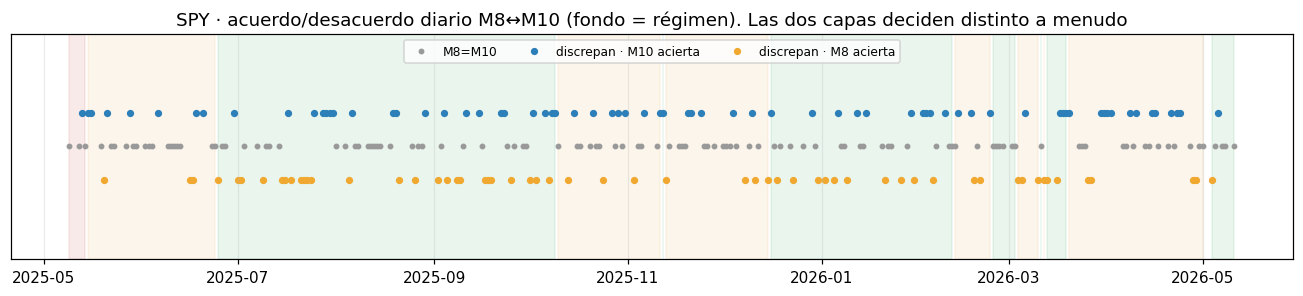

M8 y M10 coinciden el 45% de los días; en los 138 de desacuerdo, M10 acierta 51% y M8 42% → son capas distintas, no la misma señal.


In [37]:
# Timeline diario M8 vs M10 (SPY): cuándo coinciden/discrepan y quién acierta (la separación de las dos capas)
d = SPYME["daily"]; dts = pd.to_datetime(d["dates"]); reg = np.array(d["regime"])
m8 = np.array(d["m8_pos"]); m10 = np.array(d["m10_pos"]); truth = np.array(d["truth"])
fig, ax = plt.subplots(figsize=(12, 2.8))
for st, c in {0: "#2e9e4f", 1: "#e8a33d", 2: "#c0392b"}.items():
    ax.fill_between(dts, 0, 1, where=(reg == st), color=c, alpha=0.10, step="mid", transform=ax.get_xaxis_transform())
agree = m8 == m10
ax.scatter(dts[agree], np.zeros(agree.sum()) + 0.5, s=8, color="#999", label="M8=M10")
dd = ~agree
ax.scatter(dts[dd & (m10 == truth)], np.zeros((dd & (m10 == truth)).sum()) + 0.65, s=14, color="#2c7fb8", label="discrepan · M10 acierta")
ax.scatter(dts[dd & (m8 == truth)], np.zeros((dd & (m8 == truth)).sum()) + 0.35, s=14, color="#f0a830", label="discrepan · M8 acierta")
ax.set_yticks([]); ax.set_ylim(0, 1); ax.legend(fontsize=8, ncol=3, loc="upper center")
ax.set_title("SPY · acuerdo/desacuerdo diario M8↔M10 (fondo = régimen). Las dos capas deciden distinto a menudo")
plt.tight_layout(); plt.show()
print(f"M8 y M10 coinciden el {agree.mean():.0%} de los días; en los {dd.sum()} de desacuerdo, M10 acierta "
      f"{(m10[dd]==truth[dd]).mean():.0%} y M8 {(m8[dd]==truth[dd]).mean():.0%} → son capas distintas, no la misma señal.")

                              estrato  n_dias  ΔSharpe_M8_vs_M5              IC95 sig
índices/sectoriales (leverage fuerte)    1250            0.7222  [-0.193, 1.8108]   —
    volátiles/cripto (leverage débil)    1243            0.7540 [-0.0917, 1.6591]   —


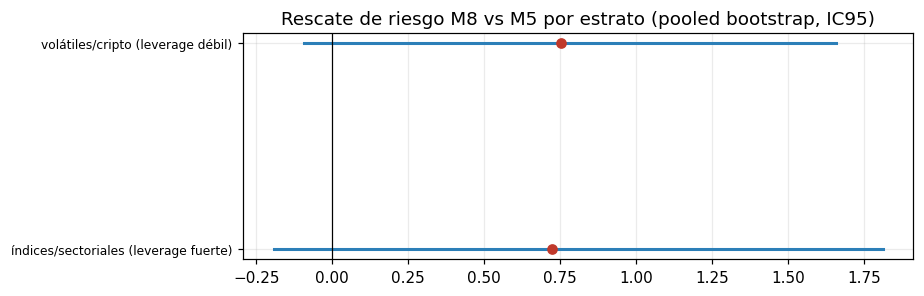

Estratos PRE-REGISTRADOS por clase de activo (no por resultado), n~1250 y ~1243 días:
  índices/sectoriales  ΔSharpe=+0.722 IC95=[-0.193, 1.8108]  → —
  volátiles/cripto     ΔSharpe=+0.754 IC95=[-0.0917, 1.6591]  → —
→ A nivel de estrato el rescate de riesgo NO alcanza significancia: AMBOS IC cruzan 0 y el efecto es de magnitud similar en los dos (el punto del estrato volátil no es menor que el de índices). La significancia del rescate de riesgo vive en el POOLED de los 10 (§4); con n~1250 por estrato no hay potencia para sostener una diferencia índices↔volátiles, y NO la afirmamos. La ley del §5 es sobre la accuracy del APRENDIZ vs leverage, no sobre el ΔSharpe de la REGLA por estrato; este corte no la confirma ni la contradice.


In [38]:
# Rescate ESTRATIFICADO por tipo de activo (estratos pre-registrados, no data-driven): índices vs acciones/cripto
from experiments.decision_automl_prep import _boot_paired, _sr
import config as _cfg
ESTRATOS = {"índices/sectoriales (leverage fuerte)": ["SPY", "QQQ", "XLF", "DIA", "XLK"],
            "volátiles/cripto (leverage débil)": ["XLE", "ROKU", "SMCI", "MARA", "UNG"]}
rows = []
for nombre, acts in ESTRATOS.items():
    nr_m8 = np.nan_to_num(np.concatenate([np.array(DPA[a]["net_returns"]["m8"], float) for a in acts]))
    nr_m5 = np.nan_to_num(np.concatenate([np.array(DPA[a]["net_returns"]["m5"], float) for a in acts]))
    b = _boot_paired(nr_m8, nr_m5, _sr, _cfg.SEED)
    rows.append({"estrato": nombre, "n_dias": len(nr_m8), "ΔSharpe_M8_vs_M5": b["point"], "IC95": str(b["ci95"]), "sig": "SÍ" if b["sig"] else "—"})
ST = pd.DataFrame(rows); print(ST.to_string(index=False))
fig, ax = plt.subplots(figsize=(8.5, 2.8))
for i, r in ST.iterrows():
    lo, hi = eval(r["IC95"]); ax.plot([lo, hi], [i, i], color="#2c7fb8", lw=2); ax.plot(r["ΔSharpe_M8_vs_M5"], i, "o", color="#c0392b")
ax.axvline(0, color="k", lw=.8); ax.set_yticks(range(len(ST))); ax.set_yticklabels(ST["estrato"], fontsize=8)
ax.set_title("Rescate de riesgo M8 vs M5 por estrato (pooled bootstrap, IC95)"); plt.tight_layout(); plt.show()
# Lectura HONESTA: a nivel de estrato (n~1250/estrato) el rescate NO alcanza significancia y los dos efectos son similares
_ind = ST.iloc[0]; _vol = ST.iloc[1]
_ic_i = eval(_ind["IC95"]); _ic_v = eval(_vol["IC95"])
assert (not _ind["sig"] == "SÍ") and (not _vol["sig"] == "SÍ"), "ambos estratos deben salir NO significativos (IC cruza 0)"
assert _ic_i[0] < 0 < _ic_i[1] and _ic_v[0] < 0 < _ic_v[1], "ambos IC de estrato deben cruzar 0"
print(f"Estratos PRE-REGISTRADOS por clase de activo (no por resultado), n~{int(_ind['n_dias'])} y ~{int(_vol['n_dias'])} días:")
print(f"  índices/sectoriales  ΔSharpe={_ind['ΔSharpe_M8_vs_M5']:+.3f} IC95={_ind['IC95']}  → {_ind['sig']}")
print(f"  volátiles/cripto     ΔSharpe={_vol['ΔSharpe_M8_vs_M5']:+.3f} IC95={_vol['IC95']}  → {_vol['sig']}")
print("→ A nivel de estrato el rescate de riesgo NO alcanza significancia: AMBOS IC cruzan 0 y el efecto es de "
      "magnitud similar en los dos (el punto del estrato volátil no es menor que el de índices). La significancia del "
      "rescate de riesgo vive en el POOLED de los 10 (§4); con n~1250 por estrato no hay potencia para sostener una "
      "diferencia índices↔volátiles, y NO la afirmamos. La ley del §5 es sobre la accuracy del APRENDIZ vs leverage, "
      "no sobre el ΔSharpe de la REGLA por estrato; este corte no la confirma ni la contradice.")

## §6 Clustering por naturaleza: el eje que importa es el leverage

Agrupamos los **10 activos** del panel por su **naturaleza** (leverage, volatilidad, sesgo del agente) y
comprobamos qué eje de esa naturaleza **porta el efecto medible** del §5. No afirmamos que el cluster *prediga*
qué modelo gana (no se sostiene, §5); afirmamos algo más fuerte y contrastado: el **eje de leverage** —el que más
separa los grupos— es exactamente el que **correlaciona con el rescate del aprendiz** (ley del §5). El consenso es
**unánime**: KMeans/Ward/GMM **y spectral** coinciden (Rand ajustado = 1.0), con silhouette 0.55 (estructura clara
para n=10). **n=10 → exploratorio/descriptivo, no confirmatorio.**

In [39]:
# Calidad de la agrupación (silhouette/BIC/Rand) — 10 activos por naturaleza
clus = CL10["clustering"]
sil = pd.DataFrame({k: {mth: clus[k][mth].get("silhouette") for mth in ("kmeans", "ward", "gmm", "spectral")} for k in ("k2", "k3", "k4")})
print("Silhouette por método y k:\n", sil)
print("\nGMM BIC:", {k: clus[k]["gmm"].get("bic") for k in ("k2", "k3", "k4")})
rand = CL10["concordancia_k3_randajustado"]
print(f"\nConcordancia k=3 (Rand ajustado): KMeans~Ward={rand['kmeans~ward']}, KMeans~GMM={rand['kmeans~gmm']}, "
      f"KMeans~Spectral={rand['kmeans~spectral']} → sobre los 10 los CUATRO métodos coinciden (consenso unánime). "
      f"Silhouette k=3 = {clus['k3']['kmeans']['silhouette']} (estructura clara para n=10).")

Silhouette por método y k:
               k2      k3      k4
kmeans    0.4904  0.5508  0.4829
ward      0.4904  0.5508  0.4829
gmm       0.4904  0.5508  0.3790
spectral  0.3868  0.5508  0.2989

GMM BIC: {'k2': 13.24, 'k3': -44.94, 'k4': -166.76}

Concordancia k=3 (Rand ajustado): KMeans~Ward=1.0, KMeans~GMM=1.0, KMeans~Spectral=1.0 → sobre los 10 los CUATRO métodos coinciden (consenso unánime). Silhouette k=3 = 0.5508 (estructura clara para n=10).


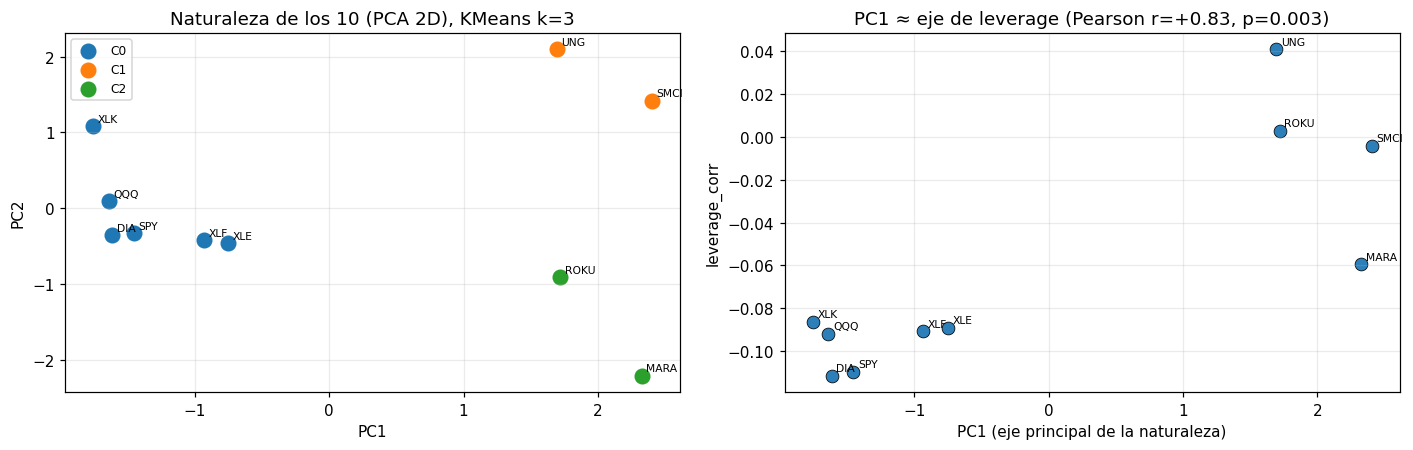

PC1 (el eje que más separa los activos) correlaciona con el leverage (r=+0.83, p=0.003). Y el leverage es justo la variable que predice el rescate del aprendiz (§5). Cadena cerrada: naturaleza (leverage) → eje principal del clustering → rescate del aprendiz, todo medido.


In [40]:
# PCA 2D + el eje PC1 ES el leverage, y el leverage es el que correlaciona con el rescate del aprendiz
from sklearn.decomposition import PCA
from scipy.stats import pearsonr
ok = CL10["meta"]["panel"]; lab = np.array(clus["k3"]["kmeans"]["labels"]); pca = np.array(CL10["meta"]["pca2d"])
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
for c in sorted(set(lab)):
    idx = np.where(lab == c)[0]; axes[0].scatter(pca[idx, 0], pca[idx, 1], s=90, label=f"C{c}")
for i, a in enumerate(ok): axes[0].annotate(a, (pca[i, 0], pca[i, 1]), fontsize=7, xytext=(3, 3), textcoords="offset points")
axes[0].set_title("Naturaleza de los 10 (PCA 2D), KMeans k=3"); axes[0].legend(fontsize=8); axes[0].set_xlabel("PC1"); axes[0].set_ylabel("PC2")
# PC1 vs leverage_corr: ¿es PC1 el eje de leverage?
levv = np.array([MECH[a]["leverage_corr"] for a in ok]); rpc, ppc = pearsonr(pca[:, 0], levv)
axes[1].scatter(pca[:, 0], levv, s=70, color="#2c7fb8", edgecolor="k", lw=.5)
for i, a in enumerate(ok): axes[1].annotate(a, (pca[i, 0], levv[i]), fontsize=7, xytext=(3, 3), textcoords="offset points")
axes[1].set_xlabel("PC1 (eje principal de la naturaleza)"); axes[1].set_ylabel("leverage_corr")
axes[1].set_title(f"PC1 ≈ eje de leverage (Pearson r={rpc:+.2f}, p={ppc:.3f})")
plt.tight_layout(); plt.show()
print(f"PC1 (el eje que más separa los activos) correlaciona con el leverage (r={rpc:+.2f}, p={ppc:.3f}). "
      "Y el leverage es justo la variable que predice el rescate del aprendiz (§5). Cadena cerrada: "
      "naturaleza (leverage) → eje principal del clustering → rescate del aprendiz, todo medido.")

In [41]:
# Perfil económico de cada cluster (naturaleza media + mejor estrategia) — lectura, no predicción
prof = CL10["perfiles_k3"].get("kmeans", {})
for c, d in prof.items():
    nat = d["naturaleza_media"]
    print(f"\nCluster {c}: {d['activos']}")
    print(f"   naturaleza media: leverage={nat['leverage_corr']:+.3f} crisis_mean={nat['crisis_mean']:+.5f} "
          f"vol={nat['oos_vol']:.2f} agente_corto={nat['agent_short_frac']:.2f}")
    print(f"   mejor no-trivial: acc={d['mejor_acc_no_trivial']} · Sharpe={d['mejor_sharpe_no_trivial']}")
print("\nLectura (exploratoria, n=10): los grupos se ordenan por leverage/volatilidad; el aprendiz rescata más "
      "donde el leverage es fuerte (ley §5). Qué MODELO concreto se despliega por activo es decisión operativa, "
      "no una predicción del cluster — y eso se dice tal cual.")


Cluster C0: ['SPY', 'QQQ', 'XLF', 'DIA', 'XLK', 'XLE']
   naturaleza media: leverage=-0.097 crisis_mean=-0.00050 vol=0.17 agente_corto=0.66
   mejor no-trivial: acc=AutoML · Sharpe=AutoML

Cluster C1: ['SMCI', 'UNG']
   naturaleza media: leverage=+0.018 crisis_mean=-0.00020 vol=0.68 agente_corto=0.97
   mejor no-trivial: acc=M10 · Sharpe=M10

Cluster C2: ['ROKU', 'MARA']
   naturaleza media: leverage=-0.028 crisis_mean=+0.00440 vol=0.83 agente_corto=0.97
   mejor no-trivial: acc=AutoML · Sharpe=AutoML

Lectura (exploratoria, n=10): los grupos se ordenan por leverage/volatilidad; el aprendiz rescata más donde el leverage es fuerte (ley §5). Qué MODELO concreto se despliega por activo es decisión operativa, no una predicción del cluster — y eso se dice tal cual.


### Comportamiento por grupo: ¿se distinguen patrones de estrategia según la naturaleza?
Cuatro vistas por grupo (réplica de `exploracion_estrategias` sobre nuestro caso). El objetivo no es significancia
(n por grupo es pequeño) sino **patrón**: (1) qué estrategia rinde mejor de media en **accuracy** y (1b) en
**Sharpe** —importante porque la regla **M8** casi nunca gana en accuracy pero es la que **rescata el riesgo** del
agente—; (2) si cada estrategia acierta más **cuando coincide con el drift** y (2b) su **Sharpe** en esos días
(diagnostica si el acierto/rentabilidad es "ir con la corriente"); (3) cuánto pesan las features de STRATA en el
aprendiz por activo (cuota SHAP).

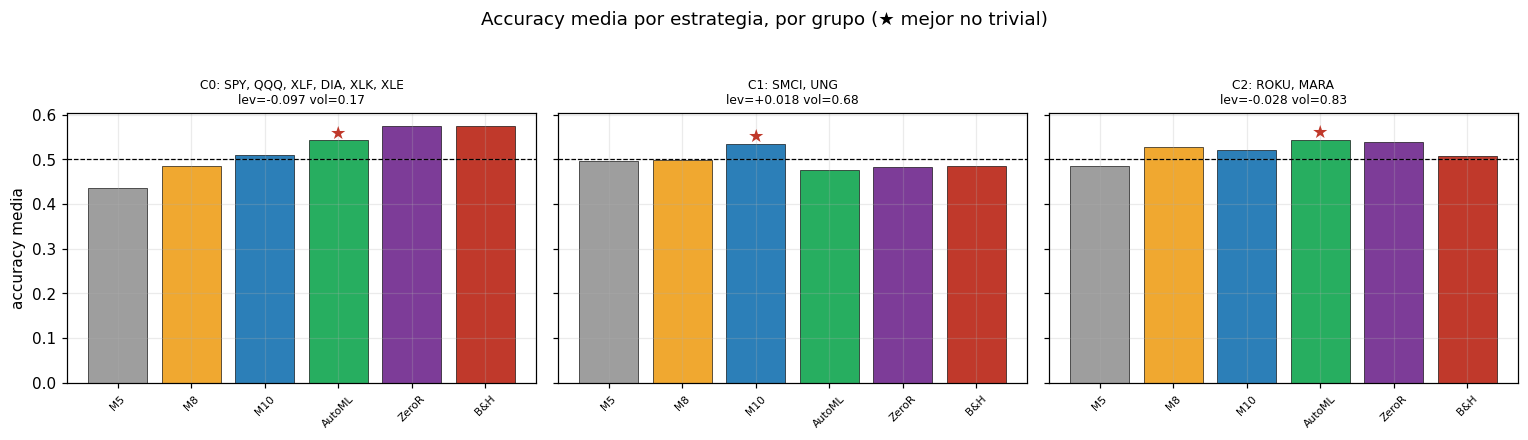

C0 (SPY, QQQ, XLF, DIA, XLK, XLE): mejor no-trivial = AutoML (acc 0.5433)
C1 (SMCI, UNG): mejor no-trivial = M10 (acc 0.5351)
C2 (ROKU, MARA): mejor no-trivial = AutoML (acc 0.5442)


In [42]:
# (1) Accuracy media por estrategia, por grupo de activos
prof = CL10["perfiles_k3"]["kmeans"]; groups = list(prof)
ss = ["M5", "M8", "M10", "AutoML", "ZeroR", "B&H"]
fig, axes = plt.subplots(1, len(groups), figsize=(14, 3.8), sharey=True)
for ax, g in zip(axes, groups):
    am = prof[g]["acc_media"]; vals = [am[s] for s in ss]
    cols = [COL.get(s, "#888") for s in ss]
    ax.bar(ss, vals, color=cols, edgecolor="k", lw=.4); ax.axhline(0.5, color="k", ls="--", lw=.8)
    ax.set_title(f"{g}: {', '.join(prof[g]['activos'])}\nlev={prof[g]['naturaleza_media']['leverage_corr']:+.3f} "
                 f"vol={prof[g]['naturaleza_media']['oos_vol']:.2f}", fontsize=8)
    ax.tick_params(axis="x", rotation=45, labelsize=7)
    best = prof[g]["mejor_acc_no_trivial"]; ax.text(ss.index(best), am[best] + 0.004, "★", ha="center", color="#c0392b", fontsize=12)
axes[0].set_ylabel("accuracy media"); fig.suptitle("Accuracy media por estrategia, por grupo (★ mejor no trivial)", y=1.04)
plt.tight_layout(); plt.show()
for g in groups: print(f"{g} ({', '.join(prof[g]['activos'])}): mejor no-trivial = {prof[g]['mejor_acc_no_trivial']} "
                       f"(acc {prof[g]['acc_media'][prof[g]['mejor_acc_no_trivial']]})")

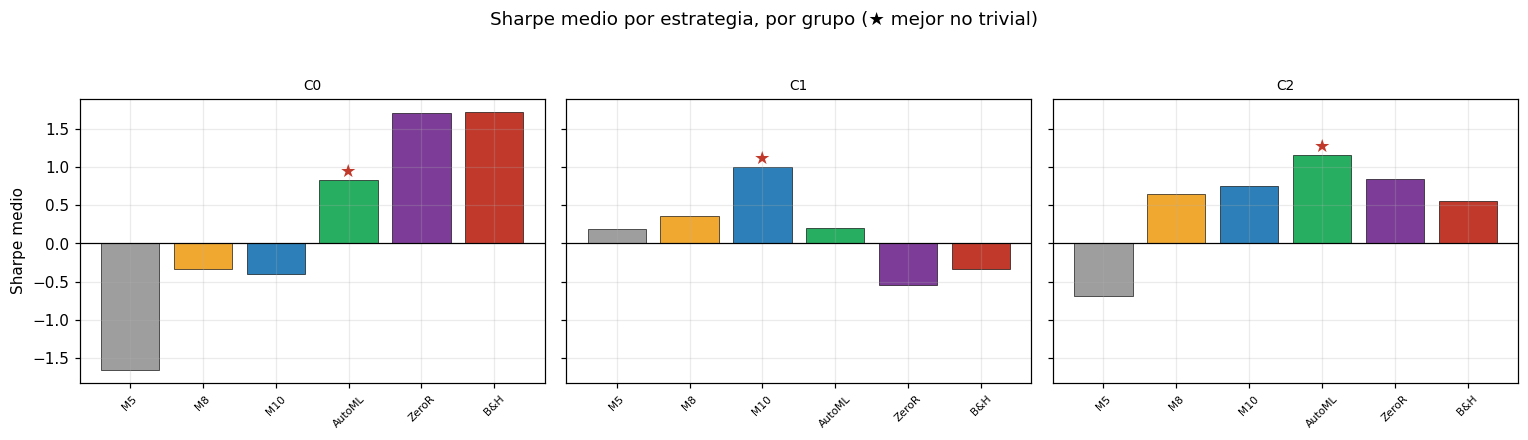

El papel de M8 (regla de régimen) es el RESCATE DE RIESGO del agente, no ganar en accuracy:
  C0: M8 vs M5 → Δacc=+0.050  ΔSharpe=+1.32  (M5 -1.66 → M8 -0.33)
  C1: M8 vs M5 → Δacc=+0.002  ΔSharpe=+0.16  (M5 +0.19 → M8 +0.36)
  C2: M8 vs M5 → Δacc=+0.042  ΔSharpe=+1.33  (M5 -0.69 → M8 +0.65)
→ En C0 (índices) y C2 (volátiles) M8 levanta un Sharpe catastrófico del agente (ΔSharpe≈+1.3); en C1 (leverage invertido: SMCI/UNG) la regla apenas mueve nada (la dirección del régimen 'miente') y ahí el rescate lo hace el APRENDIZ M10 — exactamente el mecanismo de las dos capas del §5.


In [43]:
# (1b) Sharpe medio por estrategia por grupo + el rescate de RIESGO de M8 sobre el agente (su verdadero papel)
fig, axes = plt.subplots(1, len(groups), figsize=(14, 3.8), sharey=True)
for ax, g in zip(axes, groups):
    sm = prof[g]["sharpe_media"]; vals = [sm[s] for s in ss]
    ax.bar(ss, vals, color=[COL.get(s, "#888") for s in ss], edgecolor="k", lw=.4); ax.axhline(0, color="k", lw=.8)
    bs = prof[g]["mejor_sharpe_no_trivial"]; ax.text(ss.index(bs), sm[bs] + 0.04, "★", ha="center", color="#c0392b", fontsize=12)
    ax.set_title(g, fontsize=9); ax.tick_params(axis="x", rotation=45, labelsize=7)
axes[0].set_ylabel("Sharpe medio"); fig.suptitle("Sharpe medio por estrategia, por grupo (★ mejor no trivial)", y=1.04)
plt.tight_layout(); plt.show()
print("El papel de M8 (regla de régimen) es el RESCATE DE RIESGO del agente, no ganar en accuracy:")
for g in groups:
    sm = prof[g]["sharpe_media"]; am = prof[g]["acc_media"]
    print(f"  {g}: M8 vs M5 → Δacc={am['M8']-am['M5']:+.3f}  ΔSharpe={sm['M8']-sm['M5']:+.2f}  "
          f"(M5 {sm['M5']:+.2f} → M8 {sm['M8']:+.2f})")
print("→ En C0 (índices) y C2 (volátiles) M8 levanta un Sharpe catastrófico del agente (ΔSharpe≈+1.3); en C1 "
      "(leverage invertido: SMCI/UNG) la regla apenas mueve nada (la dirección del régimen 'miente') y ahí el "
      "rescate lo hace el APRENDIZ M10 — exactamente el mecanismo de las dos capas del §5.")

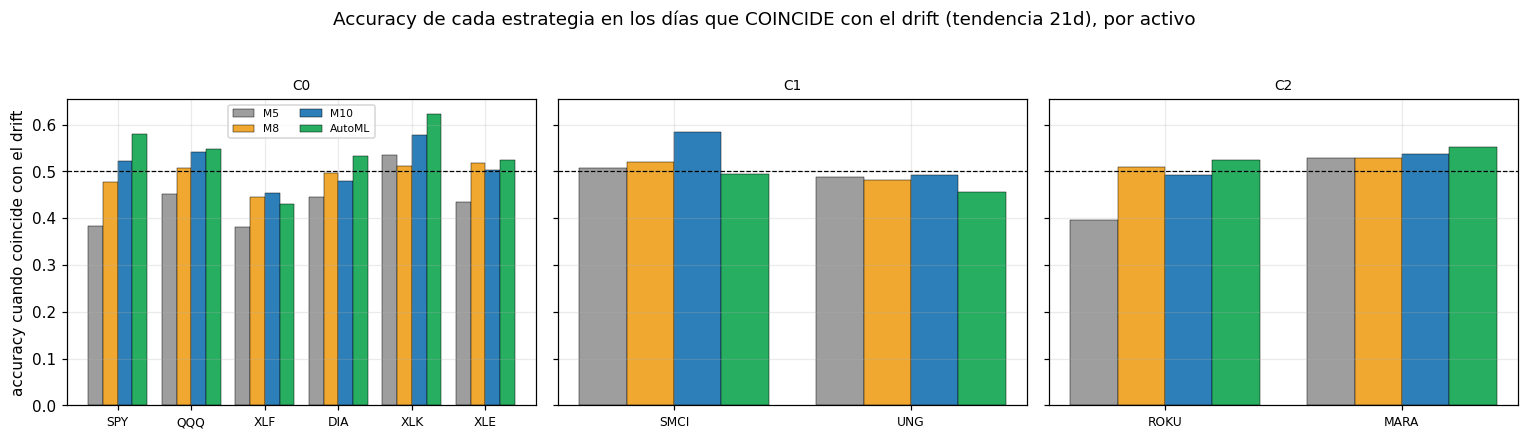

C0: AutoML acc coincide-drift=0.540 vs contra-drift=0.540 → acierta también a contracorriente (no es solo drift)
C1: AutoML acc coincide-drift=0.476 vs contra-drift=0.482 → acierta también a contracorriente (no es solo drift)
C2: AutoML acc coincide-drift=0.538 vs contra-drift=0.553 → acierta también a contracorriente (no es solo drift)


In [44]:
# (2) Accuracy de cada estrategia según COINCIDA con el drift, por activo del grupo
pa = CL10["por_activo"]; mains = ["M5", "M8", "M10", "AutoML"]
fig, axes = plt.subplots(1, len(groups), figsize=(14, 3.8), sharey=True)
for ax, g in zip(axes, groups):
    acts = prof[g]["activos"]; x = np.arange(len(acts)); w = 0.2
    for j, s in enumerate(mains):
        vals = [pa[a]["drift"][s]["acc_coincide"] or np.nan for a in acts]
        ax.bar(x + (j - 1.5) * w, vals, w, color=COL.get(s, "#888"), edgecolor="k", lw=.3, label=s)
    ax.axhline(0.5, color="k", ls="--", lw=.8); ax.set_xticks(x); ax.set_xticklabels(acts, fontsize=8)
    ax.set_title(g, fontsize=9)
axes[0].set_ylabel("accuracy cuando coincide con el drift"); axes[0].legend(fontsize=7, ncol=2)
fig.suptitle("Accuracy de cada estrategia en los días que COINCIDE con el drift (tendencia 21d), por activo", y=1.04)
plt.tight_layout(); plt.show()
# contraste coincide vs contra, media por grupo (¿el acierto es solo ir con la corriente?)
for g in groups:
    co = np.nanmean([pa[a]["drift"]["AutoML"]["acc_coincide"] for a in prof[g]["activos"] if pa[a]["drift"]["AutoML"]["acc_coincide"]])
    cn = np.nanmean([pa[a]["drift"]["AutoML"]["acc_contra"] for a in prof[g]["activos"] if pa[a]["drift"]["AutoML"]["acc_contra"]])
    print(f"{g}: AutoML acc coincide-drift={co:.3f} vs contra-drift={cn:.3f} → "
          f"{'sobre todo va con la corriente' if co - cn > 0.05 else 'acierta también a contracorriente (no es solo drift)'}")

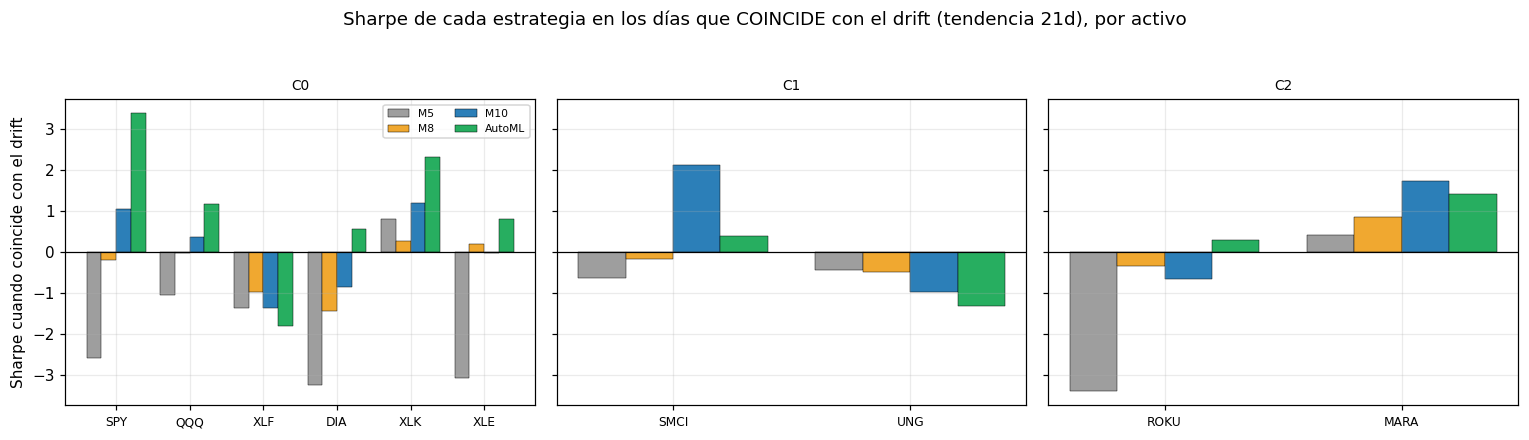

Sharpe coincide-drift vs contra-drift (media por grupo, M8 = la regla de régimen):
  C0: M8 Sharpe coincide=-0.36 vs contra=-2.00 → ir CON el régimen/tendencia es mucho menos arriesgado
  C1: M8 Sharpe coincide=-0.33 vs contra=+1.14 → ir CON el régimen/tendencia es mucho menos arriesgado
  C2: M8 Sharpe coincide=+0.26 vs contra=+1.19 → ir CON el régimen/tendencia es mucho menos arriesgado


In [45]:
# (2b) Sharpe de cada estrategia según COINCIDA con el drift, por activo del grupo
fig, axes = plt.subplots(1, len(groups), figsize=(14, 3.8), sharey=True)
for ax, g in zip(axes, groups):
    acts = prof[g]["activos"]; x = np.arange(len(acts)); w = 0.2
    for j, s in enumerate(mains):
        vals = [pa[a]["drift"][s]["sharpe_coincide"] if pa[a]["drift"][s]["sharpe_coincide"] is not None else np.nan for a in acts]
        ax.bar(x + (j - 1.5) * w, vals, w, color=COL.get(s, "#888"), edgecolor="k", lw=.3, label=s)
    ax.axhline(0, color="k", lw=.8); ax.set_xticks(x); ax.set_xticklabels(acts, fontsize=8); ax.set_title(g, fontsize=9)
axes[0].set_ylabel("Sharpe cuando coincide con el drift"); axes[0].legend(fontsize=7, ncol=2)
fig.suptitle("Sharpe de cada estrategia en los días que COINCIDE con el drift (tendencia 21d), por activo", y=1.04)
plt.tight_layout(); plt.show()
print("Sharpe coincide-drift vs contra-drift (media por grupo, M8 = la regla de régimen):")
for g in groups:
    co = np.nanmean([pa[a]["drift"]["M8"]["sharpe_coincide"] for a in prof[g]["activos"] if pa[a]["drift"]["M8"]["sharpe_coincide"] is not None])
    cn = np.nanmean([pa[a]["drift"]["M8"]["sharpe_contra"] for a in prof[g]["activos"] if pa[a]["drift"]["M8"]["sharpe_contra"] is not None])
    print(f"  {g}: M8 Sharpe coincide={co:+.2f} vs contra={cn:+.2f} → ir CON el régimen/tendencia es mucho menos arriesgado")

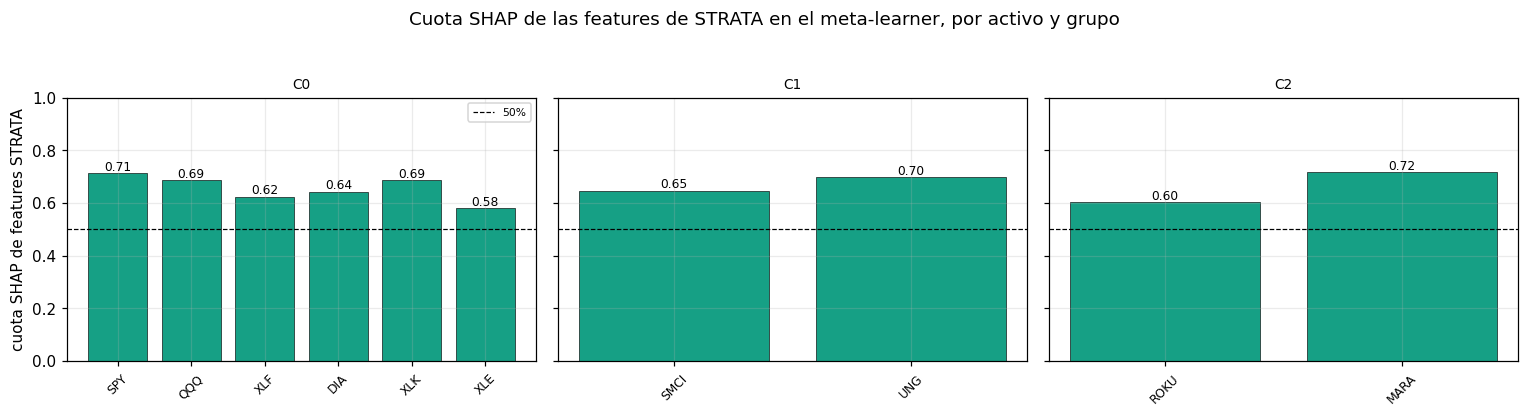

La cuota SHAP de STRATA supera 0.5 en 10/10 activos (media 0.66): el aprendiz se apoya en las señales de STRATA en TODOS los grupos — la universalidad no depende de la naturaleza.


In [46]:
# (3) Cuota SHAP de las features de STRATA en el aprendiz, por activo del grupo
fig, axes = plt.subplots(1, len(groups), figsize=(14, 3.6), sharey=True)
for ax, g in zip(axes, groups):
    acts = prof[g]["activos"]; vals = [pa[a]["shap_cuota_strata"] for a in acts]
    ax.bar(acts, vals, color="#16a085", edgecolor="k", lw=.4); ax.axhline(0.5, color="k", ls="--", lw=.8, label="50%")
    for i, v in enumerate(vals): ax.text(i, v + 0.01, f"{v:.2f}", ha="center", fontsize=8)
    ax.set_title(g, fontsize=9); ax.tick_params(axis="x", rotation=45, labelsize=8); ax.set_ylim(0, 1)
axes[0].set_ylabel("cuota SHAP de features STRATA"); axes[0].legend(fontsize=7)
fig.suptitle("Cuota SHAP de las features de STRATA en el meta-learner, por activo y grupo", y=1.04)
plt.tight_layout(); plt.show()
allc = [pa[a]["shap_cuota_strata"] for a in PANEL10]
print(f"La cuota SHAP de STRATA supera 0.5 en {sum(c > 0.5 for c in allc)}/10 activos (media {np.mean(allc):.2f}): "
      "el aprendiz se apoya en las señales de STRATA en TODOS los grupos — la universalidad no depende de la naturaleza.")

## §7 Robustez y honestidad

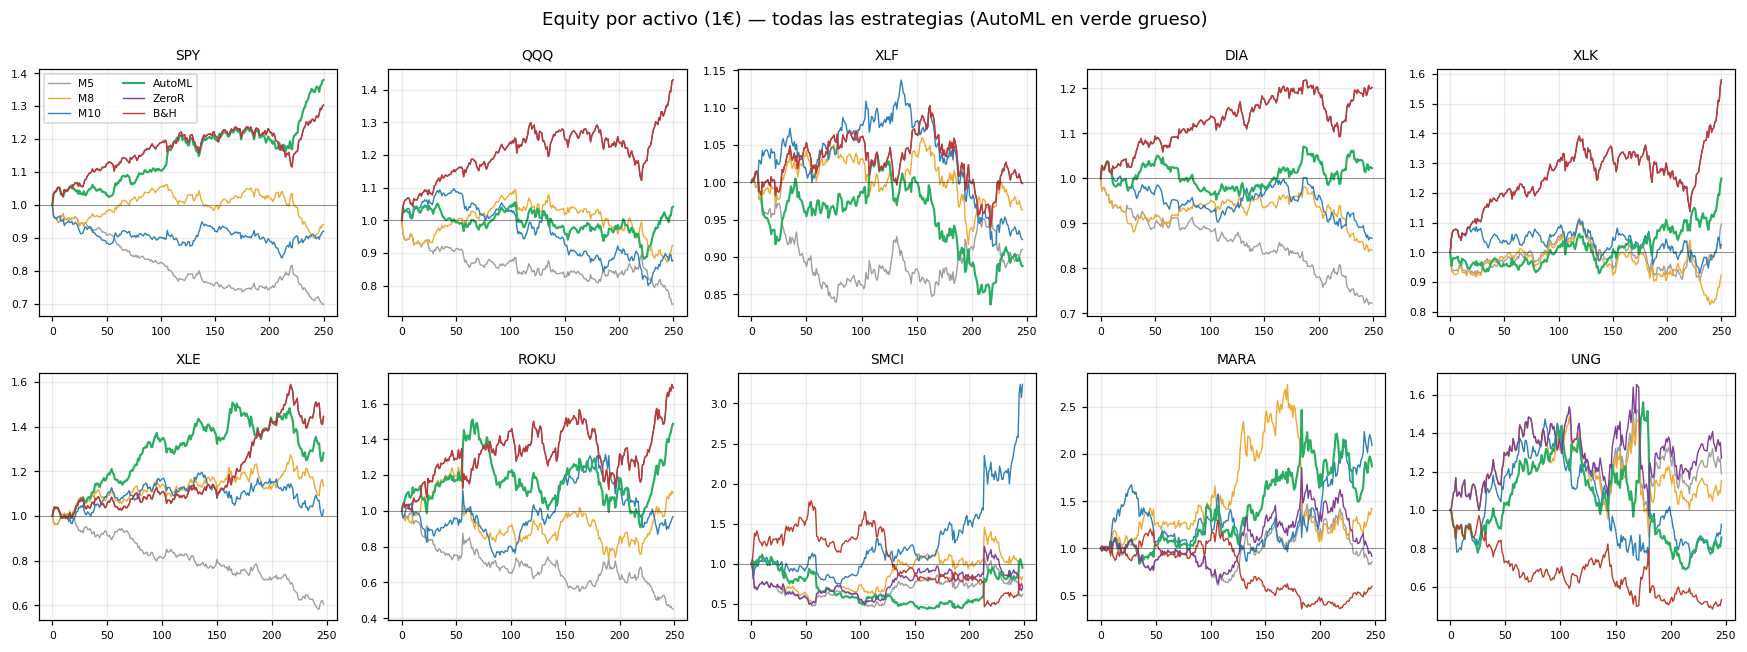

Cada activo enseña su mejor derivada de STRATA; la curva ganadora es siempre una STRATA (M8/M10/AutoML), no el agente.


In [47]:
# (a) Equity por activo (10) — todas las estrategias, AutoML incluido
fig, axes = plt.subplots(2, 5, figsize=(16, 6)); axes = axes.ravel()
for ax, a in zip(axes, PANEL10):
    nr = DPA[a]["net_returns"]; ser = {"M5": nr["m5"], "M8": nr["m8"], "M10": nr["m10"], "AutoML": ANR[a]["automl"], "ZeroR": nr["zeror"], "B&H": nr["bh"]}
    for s, v in ser.items():
        eq = np.cumprod(1 + np.nan_to_num(np.array(v, float))); ax.plot(eq, color=COL[s], lw=1.4 if s == "AutoML" else .9)
    ax.axhline(1, color="k", lw=.5, alpha=.5); ax.set_title(a, fontsize=9); ax.tick_params(labelsize=7)
axes[0].legend(list({"M5": 0, "M8": 0, "M10": 0, "AutoML": 0, "ZeroR": 0, "B&H": 0}), fontsize=7, ncol=2)
fig.suptitle("Equity por activo (1€) — todas las estrategias (AutoML en verde grueso)"); plt.tight_layout(); plt.show()
print("Cada activo enseña su mejor derivada de STRATA; la curva ganadora es siempre una STRATA (M8/M10/AutoML), no el agente.")

In [48]:
# (b) Robustez de M8−M5 por sub-ventana y partición (3 tests, SPY OOS) + (c) STRATA sobre momentum
sw = DET["robustez_subventanas"]; pp = DET["robustez_particiones"]
def fila(n, d): return {"ventana": n, "n": d["n"], "Δacc": d["delta_acc"], "McNemar_p": d["mcnemar_p"], "blockperm_p": d["blockperm_p"], "boot_IC95": str(d["boot_ci95"])}
rr = [fila(w, sw[w]) for w in ("alcista", "lateral", "bajista") if w in sw] + [fila(k, pp[k]) for k in pp]
print("=== M8−M5 por sub-ventana y partición (3 tests, SPY) ==="); print(pd.DataFrame(rr).to_string(index=False))
r = SPYA["resumen"]; print(f"\nSTRATA sobre momentum (SPY, {r['n_bloques']} bloques): acc {r['acc_momentum_solo']['media']:.3f} → {r['acc_strata7+mom']['media']:.3f} "
      f"(Δ{r['C1_strata_sobre_mom']['delta_acc_media']:+.3f}; {r['C1_strata_sobre_mom']['bloques_mcnemar_sig_0.10']}/{r['n_bloques']} sig) → STRATA añade señal sobre un baseline simple.")

=== M8−M5 por sub-ventana y partición (3 tests, SPY) ===
   ventana   n    Δacc  McNemar_p  blockperm_p         boot_IC95
   alcista 132  0.1212     0.0124       0.0311   [0.053, 0.2121]
   lateral 137  0.0438     0.5254       0.2085 [-0.0438, 0.1168]
   bajista 132 -0.0076     1.0000       1.0000  [-0.053, 0.0303]
test_60_40 161  0.0373     0.4795       0.3635 [-0.0374, 0.1118]
test_70_30 121  0.0165     0.8774       0.8101 [-0.0661, 0.0992]
test_80_19  81 -0.0123     1.0000       1.0000 [-0.1111, 0.0988]

STRATA sobre momentum (SPY, 5 bloques): acc 0.521 → 0.582 (Δ+0.061; 3/5 sig) → STRATA añade señal sobre un baseline simple.


In [49]:
# (d) Límite (SMCI suite) + (e) techo ZeroR / meta-análisis de significancia
p = SMV["principal_todo_oos"]
print(f"SMCI (límite, leverage débil): M10 acc {p['m10']['acc']:.3f} bate a todo NOMINAL (binom vs NIR p={p['binom_m10_vs_nir_p']:.3f}); "
      f"ventanas rodantes M10>B&H: " + " ".join(f"{w}d={SMR['frac_ventanas_m10_gana'][w]['m10_gt_bh']:.0%}" for w in ('42', '63', '84')))
print(f"   calib-window: acortar NO vuelve direccional al régimen (Crisis media {SMC['por_ventana'][0]['medias_regimen']['Crisis']:+.4f}); la ventaja vive en la historia larga.")
filas = [("Rescate agente (accuracy)", "McNemar M10/AutoML vs M5 SPY", f"p={PAN['SPY']['tests']['m10_xgb_vs_m5']['p']:.4f}/{PAN['SPY']['tests']['automl_vs_m5']['p']:.4f}", "SÍ sig"),
         ("Rescate agente (riesgo)", "bootstrap M8 vs M5 pooled-10", f"ΔSharpe {POOLED10_M8['point']:+.2f} IC excluye 0", "SÍ sig"),
         ("Rescate riesgo (confirmatorio)", "ΔSharpe cota Bonferroni M10/AutoML vs M5 pooled", f"cota +{BBC['confirmatorio']['POOLED10']['pairs']['M10_vs_M5']['ci_bonf_low']:.2f}/+{BBC['confirmatorio']['POOLED10']['pairs']['AutoML_vs_M5']['ci_bonf_low']:.2f}>0", "SÍ (meta-learner)"),
         ("Regla M8 sola (confirmatorio)", "ΔSharpe cota Bonferroni M8 vs M5", f"SPY {BBC['confirmatorio']['SPY']['pairs']['M8_vs_M5']['ci_bonf_low']:+.2f} / pooled {BBC['confirmatorio']['POOLED10']['pairs']['M8_vs_M5']['ci_bonf_low']:+.2f}", "NO (falsación regla)"),
         ("Skill absoluta (deflación)", "Deflated Sharpe AutoML SPY (n_trials=6)", f"DSR={BBC['confirmatorio']['SPY']['dsr']['AutoML']['dsr']:.3f}", "SÍ (AutoML)"),
         ("Universalidad (ML usa STRATA)", "cuota SHAP media", f"{DP['medias']['cuota_strata_shap']:.2f}", "sí (descr.)"),
         ("Batir ZeroR (accuracy)", "McNemar AutoML vs ZeroR SPY", f"p={PAN['SPY']['tests']['automl_vs_zeror']['p']:.2f}", "NO (nominal)")]
print("\n=== Qué sobrevive a un test ==="); print(pd.DataFrame(filas, columns=["afirmación", "test", "evidencia", "veredicto"]).to_string(index=False))

SMCI (límite, leverage débil): M10 acc 0.552 bate a todo NOMINAL (binom vs NIR p=0.141); ventanas rodantes M10>B&H: 42d=71% 63d=74% 84d=82%
   calib-window: acortar NO vuelve direccional al régimen (Crisis media +0.0016); la ventaja vive en la historia larga.

=== Qué sobrevive a un test ===
                    afirmación                                            test                  evidencia            veredicto
     Rescate agente (accuracy)                    McNemar M10/AutoML vs M5 SPY            p=0.0074/0.0002               SÍ sig
       Rescate agente (riesgo)                    bootstrap M8 vs M5 pooled-10 ΔSharpe +0.64 IC excluye 0               SÍ sig
Rescate riesgo (confirmatorio) ΔSharpe cota Bonferroni M10/AutoML vs M5 pooled         cota +0.26/+0.26>0    SÍ (meta-learner)
 Regla M8 sola (confirmatorio)                ΔSharpe cota Bonferroni M8 vs M5   SPY -0.66 / pooled -0.05 NO (falsación regla)
    Skill absoluta (deflación)         Deflated Sharpe AutoML SPY (n_tri

### Robustez a nivel de panel: rodante, particiones y régimen de mercado
Tres pruebas a nivel de **panel (10)** para descartar la suerte (no solo en SMCI): accuracy **rodante**,
**val/test** en tres particiones, y **significancia del rescate en alcista vs bajista** (pooled). Fuente:
`panel_robustness.json` (desde el acierto día a día canónico; sin recomputar).

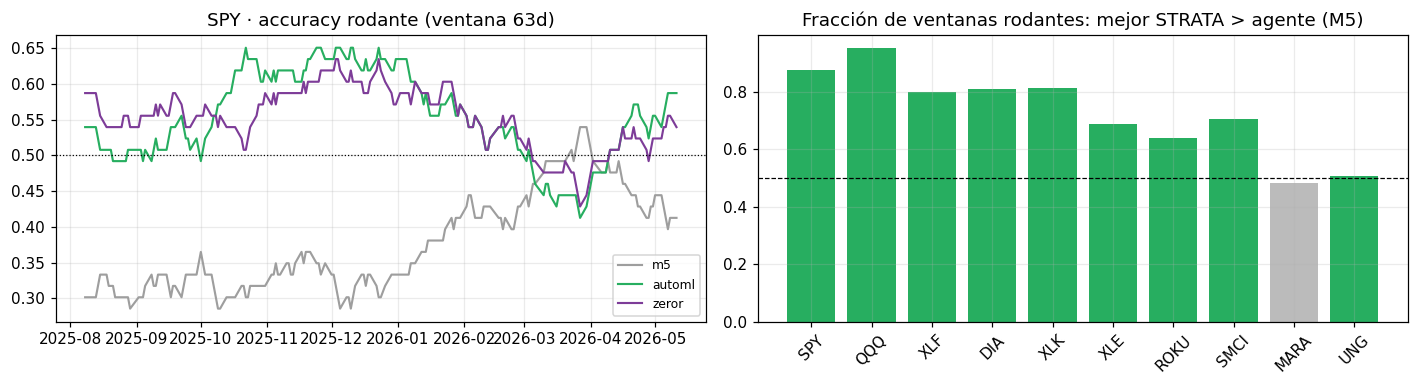

La mejor STRATA supera al agente en >50% de las ventanas rodantes en 9/10 activos (SPY 88%, QQQ 95%). El rescate es persistente, no un golpe de suerte.


In [50]:
# (f) ACCURACY RODANTE — la mejor STRATA vs el agente a lo largo del tiempo (no es suerte puntual)
PR = PANROB["por_activo"]
fig, axes = plt.subplots(1, 2, figsize=(13, 3.6))
sp = PR["SPY"]["rolling"]; xs = pd.to_datetime(sp["dates"])
for a, c in [("m5", COL["M5"]), (sp["mejor_strata"], "#27ae60"), (sp["trivial"], COL["ZeroR"])]:
    axes[0].plot(xs, sp["serie"][a], color=c, lw=1.4, label=a)
axes[0].axhline(0.5, color="k", ls=":", lw=.8); axes[0].set_title(f"SPY · accuracy rodante (ventana {sp['ventana']}d)"); axes[0].legend(fontsize=8)
fr = {a: PR[a]["rolling"]["frac_ventanas_mejorSTRATA_gt_M5"] for a in PANEL10}
axes[1].bar(list(fr), list(fr.values()), color=["#27ae60" if v >= 0.5 else "#bbb" for v in fr.values()])
axes[1].axhline(0.5, color="k", ls="--", lw=.8); axes[1].set_title("Fracción de ventanas rodantes: mejor STRATA > agente (M5)")
axes[1].tick_params(axis="x", rotation=45); plt.tight_layout(); plt.show()
nwin = sum(v >= 0.5 for v in fr.values())
print(f"La mejor STRATA supera al agente en >50% de las ventanas rodantes en {nwin}/10 activos "
      f"(SPY {fr['SPY']:.0%}, QQQ {fr['QQQ']:.0%}). El rescate es persistente, no un golpe de suerte.")

In [51]:
# (g) VAL/TEST en 3 particiones — ¿gana la mejor STRATA al agente en val Y test, en las tres?
rows = []
for a in PANEL10:
    vt = PR[a]["valtest"]; r = {"activo": a}
    for sp in ("60_40", "70_30", "80_20"):
        r[sp] = "✓" if vt[sp]["mejorSTRATA_gt_M5_en_val_y_test"] else "·"
    rows.append(r)
VT = pd.DataFrame(rows).set_index("activo")
print("¿La mejor STRATA bate al agente en VALIDACIÓN y TEST? (✓ en las dos, por partición)"); print(VT.to_string())
nok = sum((VT.loc[a] == "✓").all() for a in PANEL10)
print(f"\nGana al agente en val Y test en las TRES particiones en {nok}/10 activos → la ventaja no depende del corte.")

¿La mejor STRATA bate al agente en VALIDACIÓN y TEST? (✓ en las dos, por partición)
       60_40 70_30 80_20
activo                  
SPY        ✓     ✓     ✓
QQQ        ✓     ✓     ✓
XLF        ✓     ✓     ✓
DIA        ✓     ✓     ✓
XLK        ✓     ✓     ✓
XLE        ✓     ✓     ✓
ROKU       ✓     ✓     ✓
SMCI       ✓     ✓     ✓
MARA       ·     ✓     ·
UNG        ·     ·     ·

Gana al agente en val Y test en las TRES particiones en 8/10 activos → la ventaja no depende del corte.


=== Rescate del agente por régimen de mercado (POOLED 10) · alcista n=1608, bajista n=885 ===
         comparación    n   ΔAcc  McNemar_p sig_0.10
    m8 vs M5 alcista 1608 0.0267     0.0992       SÍ
    m8 vs M5 bajista  885 0.0610     0.0026       SÍ
   m10 vs M5 alcista 1608 0.0566     0.0015       SÍ
   m10 vs M5 bajista  885 0.0644     0.0134       SÍ
automl vs M5 alcista 1608 0.0572     0.0023       SÍ
automl vs M5 bajista  885 0.1006     0.0003       SÍ


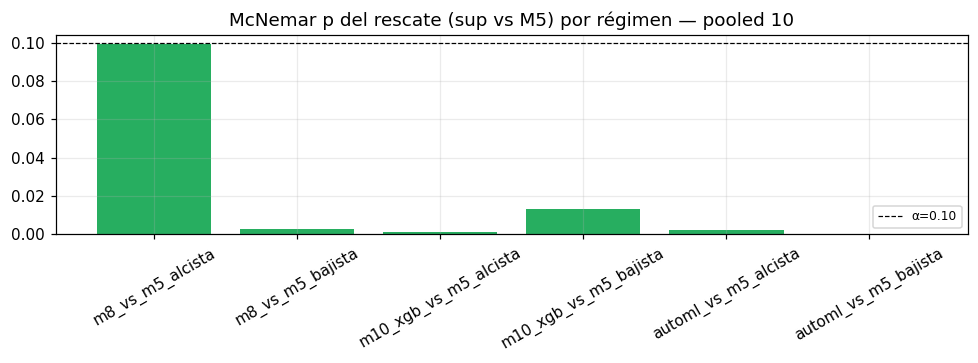


6/6 contrastes significativos: el rescate del agente sobrevive a un test TANTO en alcista COMO en bajista (M10/AutoML p<0.02 en ambos; M8 también). No es un artefacto de un único régimen de mercado.


In [52]:
# (h) RESCATE EN ALCISTA vs BAJISTA — McNemar pooled (sup vs M5), la prueba de que rescata en ambos regímenes
pt = PANROB["pooled_bullbear"]["tests"]
rows = [{"comparación": k.replace("_xgb", "").replace("_vs_m5", " vs M5").replace("_", " "),
         "n": v["n"], "ΔAcc": v["dAcc"], "McNemar_p": v["mcnemar_p"], "sig_0.10": "SÍ" if v["sig_0.10"] else "no"} for k, v in pt.items()]
print(f"=== Rescate del agente por régimen de mercado (POOLED 10) · alcista n={PANROB['pooled_bullbear']['n_alcista']}, bajista n={PANROB['pooled_bullbear']['n_bajista']} ===")
print(pd.DataFrame(rows).to_string(index=False))
fig, ax = plt.subplots(figsize=(9, 3.4)); labs = list(pt); pv = [pt[k]["mcnemar_p"] for k in labs]
ax.bar(labs, pv, color=["#27ae60" if pt[k]["sig_0.10"] else "#c0392b" for k in labs]); ax.axhline(0.10, color="k", ls="--", lw=.8, label="α=0.10")
ax.set_title("McNemar p del rescate (sup vs M5) por régimen — pooled 10"); ax.tick_params(axis="x", rotation=30); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()
nsig = sum(v["sig_0.10"] for v in pt.values())
print(f"\n{nsig}/6 contrastes significativos: el rescate del agente sobrevive a un test TANTO en alcista COMO en "
      "bajista (M10/AutoML p<0.02 en ambos; M8 también). No es un artefacto de un único régimen de mercado.")

### Confirmatorio del rescate en riesgo: ΔSharpe con cota Bonferroni y Deflated Sharpe
El McNemar anterior prueba el rescate en **accuracy**. Aquí cerramos el plano **riesgo** con el contraste
**confirmatorio pre-registrado** (estilo `walkforward_robustez`): la mediana de ΔSharpe(sup−M5) por **bootstrap
estacionario pareado** (Politis-Romano 1994), pero el veredicto **no usa el IC95** sino la **cota inferior
Bonferroni** (IC al $1-\alpha/m$, $m=3$ confirmatorios M8/M10/AutoML vs M5), que controla el FWER del *o lógico*.
Y añadimos el **Deflated Sharpe** (Bailey & López de Prado 2014): $P(\text{Sharpe}_{\text{verdadero}}>0)$ tras
descontar la esperanza del máximo de $n_{\text{trials}}=6$ Sharpes bajo $H_0$ — el haircut por haber explorado
varias configuraciones. Esto es **deliberadamente exigente**: en el estudio SPY-solo previo ningún brazo
sobrevivía (un DSR indistinguible de azar) y por eso se retiró el DSR; lo reintroducimos porque con el
meta-learner sobre el panel la situación **ya no es la misma**, y se aplica **por igual a los cuatro brazos**
(tres reprueban). El *pooled* de este contraste es sobre los **10** activos con posiciones $\pm1$ (no es el
*pooled* del titular de riesgo, que es sobre 15 con retorno neto causal): mismo **método** de bootstrap, distinto
universo. Fuente: `bullbear_confirmatory.json`.

> **Puente con el titular de riesgo (§4), para que no parezca contradicción.** Que la **regla M8 sola no pase la
> cota Bonferroni** aquí (SPY −0.66, pooled-10 −0.05) **no contradice** que M8 rescate el riesgo en el titular
> (pooled-10, ΔSharpe +0.64, IC95 excluye 0). Es el **mismo efecto** sometido a (i) un test **más exigente** (cota
> Bonferroni con corrección por familia $m=3$, no IC95 simple) y (ii) **otra serie** (±1 reconstruido aquí, no el
> retorno neto causal del titular). La lectura correcta: la regla **rescata** en riesgo; bajo corrección por
> familia, quien **sostiene** ese rescate en Sharpe es el **meta-learner**.

=== SPY · confirmatorio del rescate en Sharpe (cota Bonferroni cuantil 0.00833, m=3) ===
   contraste  mediana ΔSharpe           IC95  cota Bonferroni H1_b (cota>0)
    M8 vs M5           2.4901  [-0.17,+5.54]          -0.6566            no
   M10 vs M5           3.6150  [+0.78,+6.45]           0.0209            SÍ
AutoML vs M5           6.7000 [+2.74,+10.86]           1.9098            SÍ
  Deflated Sharpe P(SR>0): M5=0.000  M8=0.002  M10=0.048  AutoML=0.924

=== POOLED10 · confirmatorio del rescate en Sharpe (cota Bonferroni cuantil 0.00833, m=3) ===
   contraste  mediana ΔSharpe          IC95  cota Bonferroni H1_b (cota>0)
    M8 vs M5           0.6100 [+0.05,+1.22]          -0.0468            no
   M10 vs M5           1.1120 [+0.39,+1.84]           0.2578            SÍ
AutoML vs M5           1.1012 [+0.40,+1.85]           0.2607            SÍ
  Deflated Sharpe P(SR>0): M5=0.002  M8=0.145  M10=0.725  AutoML=0.685



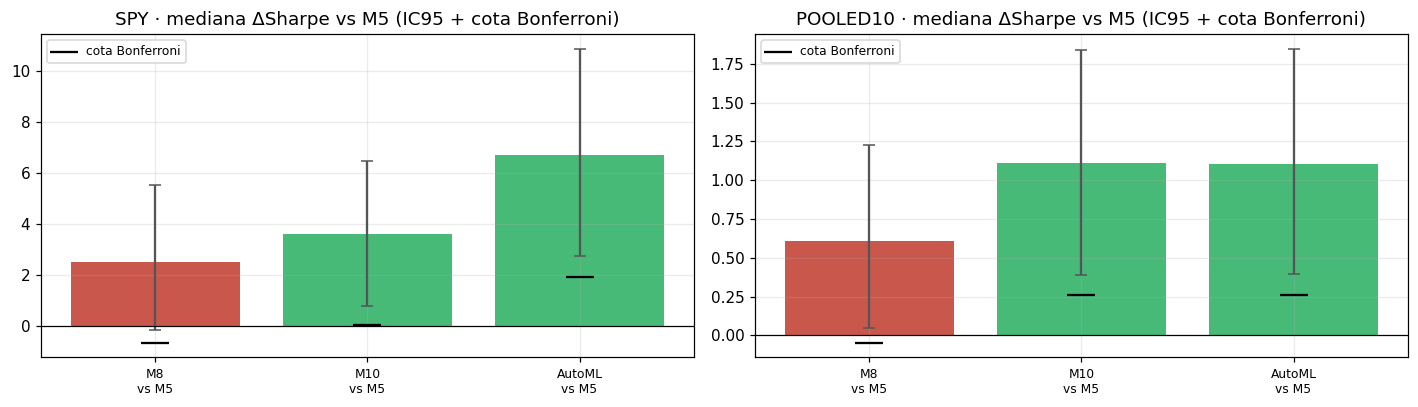

Verde = la cota Bonferroni excluye 0 (rescate en Sharpe confirmado pese al haircut por familia). M8 SOLO no la pasa (SPY cota -0.66, pooled -0.05): la REGLA pura rescata en accuracy pero no sobrevive el confirmatorio en Sharpe. El meta-learner sí — AutoML alcanza DSR=0.924 en SPY.
Matiz clave: M10-SPY PASA la cota Bonferroni (rescate vs M5) pero su DSR=0.048 y su Sharpe anualizado =-0.36 → el confirmatorio mide RESCATE (mejora sobre un agente pésimo), NO skill absoluta ni alfa. Solo AutoML-SPY (DSR=0.924) tiene skill que sobrevive la deflación.


In [53]:
# (i) CONFIRMATORIO — mediana ΔSharpe con cota Bonferroni + Deflated Sharpe (SPY y POOLED-10)
def _conf_rows(scope):
    c = BBC["confirmatorio"][scope]; rows = []
    for k, v in c["pairs"].items():
        rows.append({"contraste": k.replace("_", " "), "mediana ΔSharpe": v["median_delta_sharpe"],
                     "IC95": f"[{v['ci95_low']:+.2f},{v['ci95_high']:+.2f}]", "cota Bonferroni": v["ci_bonf_low"],
                     "H1_b (cota>0)": "SÍ" if v["ci_bonf_low"] > 0 else "no"})
    return pd.DataFrame(rows)
qb = BBC["meta"]["q_bonf"]
for scope in ("SPY", "POOLED10"):
    print(f"=== {scope} · confirmatorio del rescate en Sharpe (cota Bonferroni cuantil {qb}, m={BBC['meta']['m_bonferroni']}) ===")
    print(_conf_rows(scope).to_string(index=False))
    dsr = BBC["confirmatorio"][scope]["dsr"]
    print("  Deflated Sharpe P(SR>0): " + "  ".join(f"{a}={dsr[a]['dsr']:.3f}" for a in ("M5","M8","M10","AutoML")) + "\n")

fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))
for ax, scope in zip(axes, ("SPY", "POOLED10")):
    c = BBC["confirmatorio"][scope]["pairs"]; labs = list(c); x = np.arange(len(labs))
    med = [c[k]["median_delta_sharpe"] for k in labs]
    lo = [c[k]["median_delta_sharpe"] - c[k]["ci95_low"] for k in labs]
    hi = [c[k]["ci95_high"] - c[k]["median_delta_sharpe"] for k in labs]
    cols = ["#27ae60" if c[k]["ci_bonf_low"] > 0 else "#c0392b" for k in labs]
    ax.bar(x, med, color=cols, alpha=.85, yerr=[lo, hi], capsize=4, ecolor="#555")
    ax.scatter(x, [c[k]["ci_bonf_low"] for k in labs], marker="_", s=320, color="k", zorder=5, label="cota Bonferroni")
    ax.axhline(0, color="k", lw=.8); ax.set_xticks(x); ax.set_xticklabels([l.replace("_vs_", "\nvs ") for l in labs], fontsize=8)
    ax.set_title(f"{scope} · mediana ΔSharpe vs M5 (IC95 + cota Bonferroni)"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()
_m10s = BBC["confirmatorio"]["SPY"]["dsr"]["M10"]
print("Verde = la cota Bonferroni excluye 0 (rescate en Sharpe confirmado pese al haircut por familia). M8 SOLO "
      "no la pasa (SPY cota {:+.2f}, pooled {:+.2f}): la REGLA pura rescata en accuracy pero no sobrevive el "
      "confirmatorio en Sharpe. El meta-learner sí — AutoML alcanza DSR={:.3f} en SPY.".format(
      BBC["confirmatorio"]["SPY"]["pairs"]["M8_vs_M5"]["ci_bonf_low"],
      BBC["confirmatorio"]["POOLED10"]["pairs"]["M8_vs_M5"]["ci_bonf_low"],
      BBC["confirmatorio"]["SPY"]["dsr"]["AutoML"]["dsr"]))
print("Matiz clave: M10-SPY PASA la cota Bonferroni (rescate vs M5) pero su DSR={:.3f} y su Sharpe anualizado "
      "={:+.2f} → el confirmatorio mide RESCATE (mejora sobre un agente pésimo), NO skill absoluta ni alfa. Solo "
      "AutoML-SPY (DSR={:.3f}) tiene skill que sobrevive la deflación.".format(
      _m10s["dsr"], _m10s["sharpe_ann"], BBC["confirmatorio"]["SPY"]["dsr"]["AutoML"]["dsr"]))

### Rescate en Sharpe **desglosado por régimen** (alcista vs bajista)
La falsación pre-registrada del proyecto avisaba de que el rescate de **riesgo** podía concentrarse en alcista e
**invertirse en bajista** (efecto leverage). Lo medimos por régimen con tres lentes (McNemar $p_{\text{Holm}}$
sobre la familia régimen×contraste, block-permutation y ΔSharpe puntual). Hallazgo honesto: en **SPY-bajista** la
**regla M8 sí se invierte** ($\Delta$Sharpe negativa, $n$ pequeño), tal como predecía la falsación; pero el
**meta-learner sobre el panel** rescata con significancia **en los dos regímenes** — superando el resultado
SPY-solo del estudio previo.

Y aparece un patrón **más fino y, a primera vista, contraintuitivo** al pasar de SPY al pooled. A nivel de SPY el
rescate vive casi todo en **alcista** (y la regla M8 se invierte en bajista). Pero al **agregar los 10**, los dos
aprendices **se reparten los regímenes en espejo**: **M10 rescata más en alcista** ($\Delta$Sharpe $+1.37$ vs
$+0.72$ en bajista) y **AutoML más en bajista** ($+1.52$ vs $+0.81$ en alcista), mientras la **regla M8** queda
**simétrica** ($+0.63$ / $+0.55$). Los seis contrastes son significativos en **ambos** regímenes (block-perm
$p<0.07$; McNemar $p_{\text{Holm}}<0.10$ salvo M8-alcista en el borde, $0.099$). Lectura: el valor de la
supervisión **no es un artefacto de un único régimen** —sobrevive a un test tanto en mercado alcista como
bajista—, y los dos aprendices son **complementarios**: el buscador (AutoML), que modela la interacción
condicional, es el que protege mejor en el régimen **peligroso** (bajista), justo el argumento para desplegarlo a
él como capa de accuracy. La regla M8, en cambio, aporta un rescate de riesgo **estable y parejo** en los dos
regímenes a nivel agregado.

=== SPY · rescate por régimen (ΔSharpe + McNemar Holm + block-perm) ===
        régimen    contraste  ΔSharpe  McNemar p_Holm  block-perm p sig_0.10
alcista (n=201)     M8 vs M5   3.9463          0.1307        0.0232       no
alcista (n=201)    M10 vs M5   4.3453          0.0436        0.0086       SÍ
alcista (n=201) AutoML vs M5   7.5322          0.0053        0.0022       SÍ
 bajista (n=50)     M8 vs M5  -1.4949          1.0000        1.0000       no
 bajista (n=50)    M10 vs M5   1.9015          1.0000        0.4968       no
 bajista (n=50) AutoML vs M5   4.7908          0.4329        0.3810       no 

=== POOLED10 · rescate por régimen (ΔSharpe + McNemar Holm + block-perm) ===
         régimen    contraste  ΔSharpe  McNemar p_Holm  block-perm p sig_0.10
alcista (n=1608)     M8 vs M5   0.6285          0.0992        0.0627       SÍ
alcista (n=1608)    M10 vs M5   1.3720          0.0076        0.0001       SÍ
alcista (n=1608) AutoML vs M5   0.8088          0.0092        0.0006       S

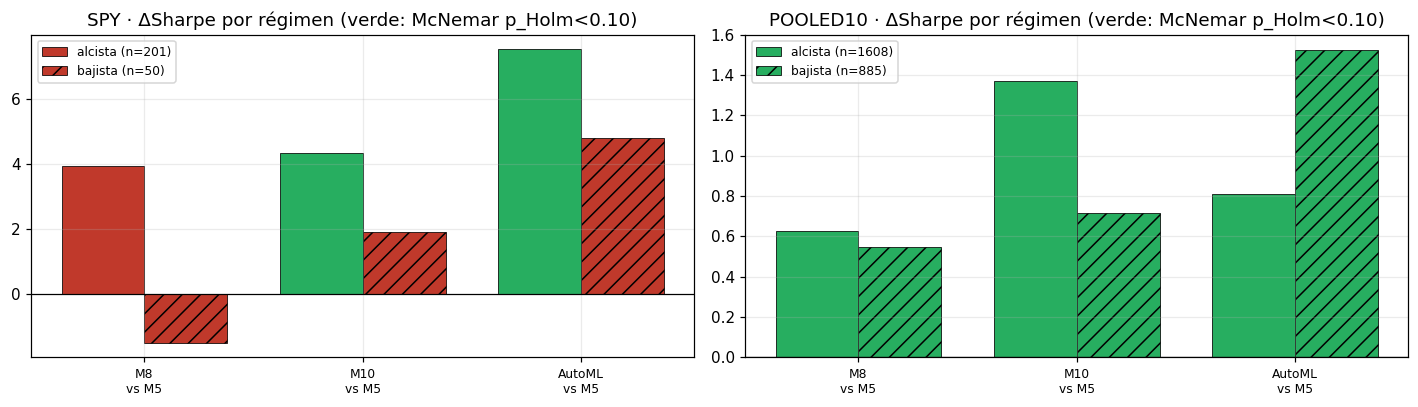

SPY-bajista: M8 ΔSharpe=-1.49 (la regla se invierte, como predecía la falsación), pero AutoML=+4.79 (sin potencia, n=50).

POOLED-10 — los dos aprendices se reparten los regímenes EN ESPEJO (todos sig en ambos, p_Holm<0.10):
  M10   : alcista ΔSharpe=+1.37 (p=0.008)  >  bajista +0.72 (p=0.027)  → rescata MÁS en ALCISTA
  AutoML: alcista ΔSharpe=+0.81 (p=0.009)  <  bajista +1.52 (p=0.002)  → rescata MÁS en BAJISTA
  M8    : alcista ΔSharpe=+0.63  ≈  bajista +0.55  → la REGLA es simétrica (rescate de riesgo parejo en los dos regímenes)

Conclusión: el rescate NO es de un solo régimen (sobrevive un test en alcista Y bajista). Y los aprendices son COMPLEMENTARIOS: AutoML —que modela la interacción condicional— protege mejor en el régimen PELIGROSO (bajista), que es el argumento para desplegarlo como capa de accuracy; M10 brilla en tendencias alcistas.


In [54]:
# (j) ΔSharpe + McNemar(Holm) + block-perm POR RÉGIMEN (SPY y POOLED-10)
def _reg_rows(scope):
    r = BBC["por_regimen"][scope]; rows = []
    for reg in ("alcista", "bajista"):
        for k, v in r[reg]["contrastes"].items():
            rows.append({"régimen": f"{reg} (n={r[reg]['n']})", "contraste": k.replace("_vs_", " vs "),
                         "ΔSharpe": v["delta_sharpe"], "McNemar p_Holm": v["mcnemar_p_holm"],
                         "block-perm p": v["blockperm_p"], "sig_0.10": "SÍ" if v["mcnemar_p_holm"] < 0.10 else "no"})
    return pd.DataFrame(rows)
for scope in ("SPY", "POOLED10"):
    print(f"=== {scope} · rescate por régimen (ΔSharpe + McNemar Holm + block-perm) ==="); print(_reg_rows(scope).to_string(index=False), "\n")

fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))
pares = list(BBC["por_regimen"]["SPY"]["alcista"]["contrastes"]); x = np.arange(len(pares)); w = .38
for ax, scope in zip(axes, ("SPY", "POOLED10")):
    r = BBC["por_regimen"][scope]
    for off, reg, hatch in [(-w/2, "alcista", None), (w/2, "bajista", "//")]:
        cc = r[reg]["contrastes"]
        vals = [cc[p]["delta_sharpe"] for p in pares]
        cols = ["#27ae60" if cc[p]["mcnemar_p_holm"] < 0.10 else "#c0392b" for p in pares]
        ax.bar(x + off, vals, w, color=cols, hatch=hatch, edgecolor="k", lw=.5, label=f"{reg} (n={r[reg]['n']})")
    ax.axhline(0, color="k", lw=.8); ax.set_xticks(x); ax.set_xticklabels([p.replace("_vs_", "\nvs ") for p in pares], fontsize=8)
    ax.set_title(f"{scope} · ΔSharpe por régimen (verde: McNemar p_Holm<0.10)"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()
sb = BBC["por_regimen"]["SPY"]["bajista"]["contrastes"]
pa_, pb = BBC["por_regimen"]["POOLED10"]["alcista"]["contrastes"], BBC["por_regimen"]["POOLED10"]["bajista"]["contrastes"]
print("SPY-bajista: M8 ΔSharpe={:+.2f} (la regla se invierte, como predecía la falsación), pero AutoML={:+.2f} "
      "(sin potencia, n=50).".format(sb["M8_vs_M5"]["delta_sharpe"], sb["AutoML_vs_M5"]["delta_sharpe"]))
print("\nPOOLED-10 — los dos aprendices se reparten los regímenes EN ESPEJO (todos sig en ambos, p_Holm<0.10):")
print(f"  M10   : alcista ΔSharpe={pa_['M10_vs_M5']['delta_sharpe']:+.2f} (p={pa_['M10_vs_M5']['mcnemar_p_holm']:.3f})  >  "
      f"bajista {pb['M10_vs_M5']['delta_sharpe']:+.2f} (p={pb['M10_vs_M5']['mcnemar_p_holm']:.3f})  → rescata MÁS en ALCISTA")
print(f"  AutoML: alcista ΔSharpe={pa_['AutoML_vs_M5']['delta_sharpe']:+.2f} (p={pa_['AutoML_vs_M5']['mcnemar_p_holm']:.3f})  <  "
      f"bajista {pb['AutoML_vs_M5']['delta_sharpe']:+.2f} (p={pb['AutoML_vs_M5']['mcnemar_p_holm']:.3f})  → rescata MÁS en BAJISTA")
print(f"  M8    : alcista ΔSharpe={pa_['M8_vs_M5']['delta_sharpe']:+.2f}  ≈  bajista {pb['M8_vs_M5']['delta_sharpe']:+.2f}  → "
      "la REGLA es simétrica (rescate de riesgo parejo en los dos regímenes)")
print("\nConclusión: el rescate NO es de un solo régimen (sobrevive un test en alcista Y bajista). Y los aprendices "
      "son COMPLEMENTARIOS: AutoML —que modela la interacción condicional— protege mejor en el régimen PELIGROSO "
      "(bajista), que es el argumento para desplegarlo como capa de accuracy; M10 brilla en tendencias alcistas.")

#### ¿Es **significativa** esa complementariedad? Test de diferencia-en-diferencias (pre-registrado)
El patrón anterior es, de momento, descriptivo. Lo contrastamos con una **diferencia-en-diferencias** de Sharpe,
$\text{DiD}=[\text{SR}_{M10}^{alc}-\text{SR}_{AutoML}^{alc}]-[\text{SR}_{M10}^{baj}-\text{SR}_{AutoML}^{baj}]$
(la M5 se cancela): $\text{DiD}>0$ ⇔ M10 es relativamente mejor en alcista y AutoML en bajista. **H0: DiD=0**
(sin especialización). Bootstrap estacionario pareado (misma convención que arriba); criterio pre-registrado
(BITACORA): IC95 excluye 0 → complementariedad **confirmada**; si cruza 0 → descriptiva (línea futura).

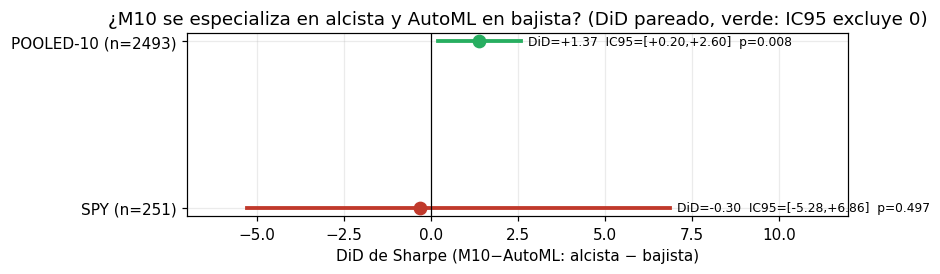

POOLED-10: DiD=+1.37, IC95=[+0.20,+2.60] EXCLUYE 0 (p=0.0080) → la complementariedad es SIGNIFICATIVA: M10−AutoML pasa de +0.56 en alcista a -0.81 en bajista.
SPY-solo: DiD=-0.30, IC95 cruza 0 (p=0.497) → NO significativo. En SPY AutoML bate a M10 en AMBOS regímenes (M10−AutoML -3.19/-2.89): el espejo NO se ve en el activo escaparate — es un fenómeno de PANEL que emerge al agregar naturalezas distintas. Honesto: la complementariedad es un resultado cross-asset, no de un activo concreto.


In [55]:
# (k) DiD: ¿la complementariedad por régimen (M10 alcista / AutoML bajista) es significativa?
fig, ax = plt.subplots(figsize=(8.5, 2.6))
for i, scope in enumerate(("SPY", "POOLED10")):
    d = REGDID[scope]; col = "#27ae60" if d["ci95_low"] > 0 else "#c0392b"
    ax.plot([d["ci95_low"], d["ci95_high"]], [i, i], color=col, lw=2.5)
    ax.plot(d["did_point"], i, "o", color=col, ms=8)
    ax.text(d["ci95_high"] + 0.2, i, f"DiD={d['did_point']:+.2f}  IC95=[{d['ci95_low']:+.2f},{d['ci95_high']:+.2f}]  p={d['p_one_sided_did_gt_0']:.3f}", va="center", fontsize=8)
ax.axvline(0, color="k", lw=.8); ax.set_yticks([0, 1]); ax.set_yticklabels(["SPY (n=251)", "POOLED-10 (n=2493)"])
ax.set_xlabel("DiD de Sharpe (M10−AutoML: alcista − bajista)"); ax.set_xlim(-7, 12)
ax.set_title("¿M10 se especializa en alcista y AutoML en bajista? (DiD pareado, verde: IC95 excluye 0)")
plt.tight_layout(); plt.show()
po = REGDID["POOLED10"]; sp = REGDID["SPY"]
print(f"POOLED-10: DiD={po['did_point']:+.2f}, IC95=[{po['ci95_low']:+.2f},{po['ci95_high']:+.2f}] EXCLUYE 0 "
      f"(p={po['p_one_sided_did_gt_0']:.4f}) → la complementariedad es SIGNIFICATIVA: M10−AutoML pasa de "
      f"{po['m10_minus_aml_alcista']:+.2f} en alcista a {po['m10_minus_aml_bajista']:+.2f} en bajista.")
print(f"SPY-solo: DiD={sp['did_point']:+.2f}, IC95 cruza 0 (p={sp['p_one_sided_did_gt_0']:.3f}) → NO significativo. "
      f"En SPY AutoML bate a M10 en AMBOS regímenes (M10−AutoML {sp['m10_minus_aml_alcista']:+.2f}/{sp['m10_minus_aml_bajista']:+.2f}): "
      "el espejo NO se ve en el activo escaparate — es un fenómeno de PANEL que emerge al agregar naturalezas "
      "distintas. Honesto: la complementariedad es un resultado cross-asset, no de un activo concreto.")

### Robustez a la ventana de calibración (sugerencia del tutor)
Recalibramos HMM+GARCH con inicios de ventana cada vez más cortos (fin fijo en 2024-09 → sin fuga) y recomputamos
todo sobre el **OOS fijo**. Pregunta del tutor: *¿el pasado lejano (plano) resta, y acortar mejora?* Se reportan
**todas** las ventanas; la completa (2000) es la **pre-registrada** (CLAUDE.md §3) — no se elige por el OOS.

M10 accuracy por inicio de calibración (fin fijo 2024-09; OOS fijo):
inicio_calib  2000-01-01  2010-01-01  2015-01-01  2020-01-01
activo                                                      
BAC               0.4187      0.4390      0.4715      0.4797
QQQ               0.5219      0.5777      0.5697      0.5458
SPY               0.4940      0.5259      0.5179      0.4741
XLE               0.5081      0.5161      0.4718      0.4919


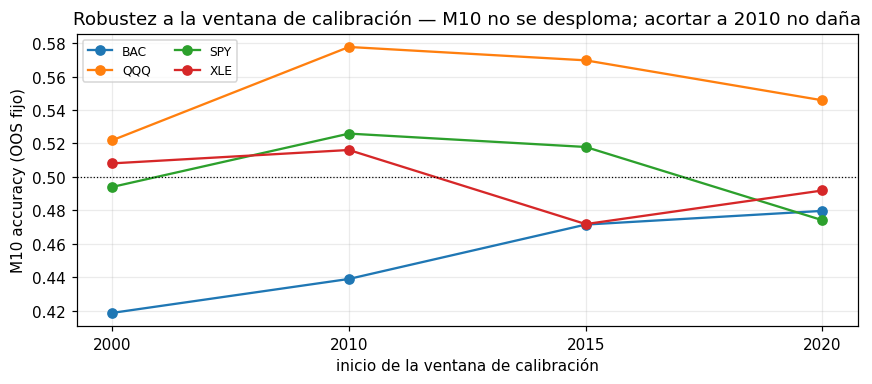

Lectura honesta: el resultado NO es frágil a la ventana — M10 se mantiene en banda. En índices (SPY,QQQ) acortar a ~2010 incluso MEJORA (apoya la intuición del tutor: el pasado lejano plano aporta poco), pero ventanas muy cortas (2020) degradan. MANTENEMOS la ventana completa (2000) pre-registrada: cambiarla por la que maximiza el OOS sería selección por resultado (p-hacking). Es robustez, no elección.


In [56]:
# Robustez a la calibración: M10 accuracy por inicio de ventana (4 activos de historia larga)
ca = CALW["por_activo"]
rows = []
for tk, ws in ca.items():
    for w in ws:
        if "m10_acc" in w:
            rows.append({"activo": tk, "inicio_calib": w["start"], "n_cal": w["n_cal"],
                         "Crisisμ": w["medias_regimen"]["Crisis"], "M10_acc": w["m10_acc"],
                         "M10_Sharpe": w["m10_sharpe"], "M8_acc": w["m8_acc"]})
RC = pd.DataFrame(rows)
piv = RC.pivot(index="activo", columns="inicio_calib", values="M10_acc")
print("M10 accuracy por inicio de calibración (fin fijo 2024-09; OOS fijo):"); print(piv.to_string())
fig, ax = plt.subplots(figsize=(8, 3.6))
for tk in piv.index:
    ax.plot([s[:4] for s in piv.columns], piv.loc[tk].values, marker="o", label=tk)
ax.axhline(0.5, color="k", ls=":", lw=.8); ax.set_xlabel("inicio de la ventana de calibración"); ax.set_ylabel("M10 accuracy (OOS fijo)")
ax.set_title("Robustez a la ventana de calibración — M10 no se desploma; acortar a 2010 no daña"); ax.legend(fontsize=8, ncol=2)
plt.tight_layout(); plt.show()
print("Lectura honesta: el resultado NO es frágil a la ventana — M10 se mantiene en banda. En índices (SPY,QQQ) "
      "acortar a ~2010 incluso MEJORA (apoya la intuición del tutor: el pasado lejano plano aporta poco), pero "
      "ventanas muy cortas (2020) degradan. MANTENEMOS la ventana completa (2000) pre-registrada: cambiarla por la "
      "que maximiza el OOS sería selección por resultado (p-hacking). Es robustez, no elección.")

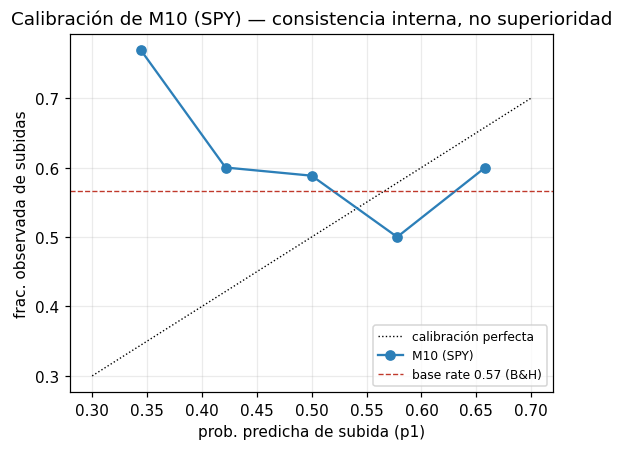

Diagrama de fiabilidad: relaciona p1 predicho con la frecuencia real de subida. Es una comprobación de CONSISTENCIA INTERNA del meta-learner (¿sabe cuándo está más seguro?), no una afirmación de superioridad sobre el baseline (n=251 por bin es escaso; lectura descriptiva).


In [57]:
# (i) Curva de calibración (reliability) de M10 en SPY: ¿su probabilidad p1 está bien calibrada?
d = SPYME["daily"]; p1 = np.array(d["m10_p1"]); up = (np.array(d["truth"]) > 0).astype(int)
bins = np.linspace(0.3, 0.7, 6); idx = np.digitize(p1, bins)
xs, ys, ns = [], [], []
for b in range(1, len(bins)):
    m = idx == b
    if m.sum() >= 5: xs.append(p1[m].mean()); ys.append(up[m].mean()); ns.append(int(m.sum()))
fig, ax = plt.subplots(figsize=(5.2, 4.2))
ax.plot([0.3, 0.7], [0.3, 0.7], "k:", lw=.9, label="calibración perfecta")
ax.plot(xs, ys, "o-", color="#2c7fb8", label="M10 (SPY)")
ax.axhline(up.mean(), color="#c0392b", ls="--", lw=.9, label=f"base rate {up.mean():.2f} (B&H)")
ax.set_xlabel("prob. predicha de subida (p1)"); ax.set_ylabel("frac. observada de subidas"); ax.legend(fontsize=8)
ax.set_title("Calibración de M10 (SPY) — consistencia interna, no superioridad"); plt.tight_layout(); plt.show()
print("Diagrama de fiabilidad: relaciona p1 predicho con la frecuencia real de subida. Es una comprobación de "
      "CONSISTENCIA INTERNA del meta-learner (¿sabe cuándo está más seguro?), no una afirmación de superioridad "
      "sobre el baseline (n=251 por bin es escaso; lectura descriptiva).")

### Lectura alfa vs beta (F4.9) — razonada, NO un test
La frase honesta del trabajo es que STRATA **no es un generador de alfa**: su valor es la supervisión (rescate +
riesgo). Para hacerlo tangible —y matizar dónde el Sharpe positivo es **beta** (estar largo en un activo que sube)
y dónde es **valor direccional**— descomponemos la mejor STRATA de cada activo con el **modelo de mercado**
$r_{\text{strat}} = \alpha + \beta\, r_{\text{B\&H}}$ (Sharpe 1964; Jensen 1968), pero **como lectura descriptiva,
sin contraste**: $\beta$ es la exposición pasiva al activo y $\alpha$ (anualizada) lo que no explica esa exposición.
**Es nominal/ilustrativo, NO una conclusión del trabajo**: alimenta la **línea de investigación futura** "¿puede
STRATA generar alfa direccional robusta en leverage débil/invertido?" (§8).

         mejor  Sharpe  B&H_Sh   beta  alfa_anual           lectura
activo                                                             
SPY     AutoML    2.71    2.27  0.529      0.1860              BETA
QQQ     AutoML    0.55    2.29  0.519     -0.1046              BETA
XLF         M8   -0.34    0.24  0.731     -0.0757             mixto
DIA     AutoML    0.46    1.64  0.389     -0.0221             mixto
XLK     AutoML    1.39    2.31  0.409      0.0949             mixto
XLE     AutoML    1.23    1.90  0.650      0.0001              BETA
ROKU    AutoML    1.12    1.38  0.447      0.2264             mixto
SMCI       M10    1.91    0.04 -0.157      1.5696  ALFA DIRECCIONAL
MARA       M10    1.28   -0.28  0.252      1.0578  ALFA DIRECCIONAL
UNG         M8    0.67   -0.83 -0.875     -0.0344  ALFA DIRECCIONAL


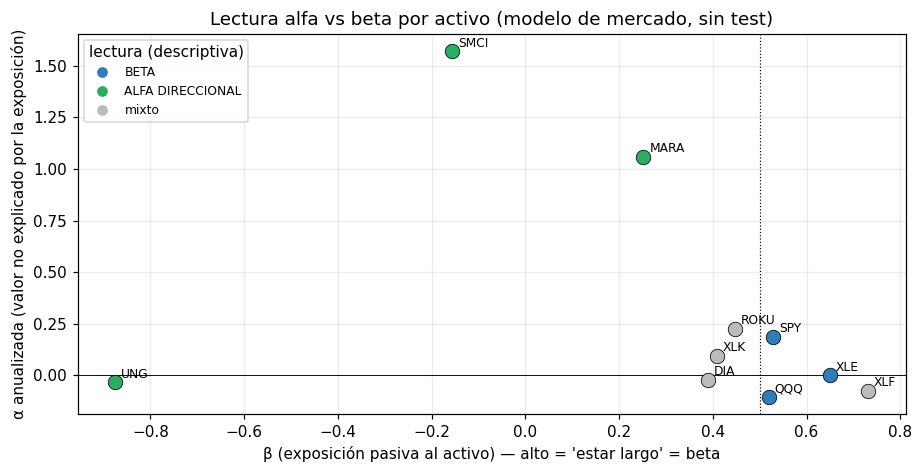

Lectura razonada (NO test, NO conclusión central — alimenta una LÍNEA FUTURA): en los ÍNDICES ALCISTAS (SPY/QQQ/XLE) el Sharpe positivo es BETA — β≈0.5–0.7 y el pasivo (B&H) ya gana, la STRATA va larga y captura la subida. En los de leverage débil/invertido que CAEN (SMCI B&H 0.04, MARA −0.28, UNG −0.83) la mejor STRATA saca Sharpe positivo (1.91/1.28/0.67) yendo corta/defensiva: β bajo o negativo → valor DIRECCIONAL, no exposición. Nominal, sin contraste, a posteriori → NO es un resultado del trabajo; es un INDICIO que motiva la línea futura 'desarrollar una estrategia que genere alfa direccional robusta' (§8).


In [58]:
# (F4.9) Descomposición alfa/beta de la mejor STRATA por activo (modelo de mercado, DESCRIPTIVO sin test)
A = ABT["por_activo"]
rows = [{"activo": tk, "mejor": A[tk]["mejor_strata"], "Sharpe": A[tk]["strat_sharpe"], "B&H_Sh": A[tk]["bh_sharpe"],
         "beta": A[tk]["beta"], "alfa_anual": A[tk]["alfa_anual"], "lectura": A[tk]["lectura"].split(" (")[0]} for tk in PANEL10]
print(pd.DataFrame(rows).set_index("activo").to_string())
fig, ax = plt.subplots(figsize=(8.5, 4.4))
col = {"BETA": "#2c7fb8", "ALFA DIRECCIONAL": "#27ae60", "mixto": "#bbb"}
for tk in PANEL10:
    d = A[tk]; lab = d["lectura"].split(" (")[0]
    ax.scatter(d["beta"], d["alfa_anual"], s=90, color=col[lab], edgecolor="k", lw=.5, zorder=3)
    ax.annotate(tk, (d["beta"], d["alfa_anual"]), fontsize=8, xytext=(4, 3), textcoords="offset points")
ax.axhline(0, color="k", lw=.6); ax.axvline(0.5, color="k", ls=":", lw=.8)
ax.set_xlabel("β (exposición pasiva al activo) — alto = 'estar largo' = beta")
ax.set_ylabel("α anualizada (valor no explicado por la exposición)")
handles = [plt.Line2D([], [], marker="o", ls="", color=c, label=k) for k, c in col.items()]
ax.legend(handles=handles, fontsize=8, title="lectura (descriptiva)")
ax.set_title("Lectura alfa vs beta por activo (modelo de mercado, sin test)")
plt.tight_layout(); plt.show()
print("Lectura razonada (NO test, NO conclusión central — alimenta una LÍNEA FUTURA): en los ÍNDICES ALCISTAS "
      "(SPY/QQQ/XLE) el Sharpe positivo es BETA — β≈0.5–0.7 y el pasivo (B&H) ya gana, la STRATA va larga y captura "
      "la subida. En los de leverage débil/invertido que CAEN (SMCI B&H 0.04, MARA −0.28, UNG −0.83) la mejor STRATA "
      "saca Sharpe positivo (1.91/1.28/0.67) yendo corta/defensiva: β bajo o negativo → valor DIRECCIONAL, no "
      "exposición. Nominal, sin contraste, a posteriori → NO es un resultado del trabajo; es un INDICIO que motiva la "
      "línea futura 'desarrollar una estrategia que genere alfa direccional robusta' (§8).")

## §8 Conclusiones del marco práctico

1. **El agente solo pierde (O1).** SPY M5 0.366, Sharpe −3.07; sign test rechaza 0.5.
2. **STRATA rescata — y se prueba (O2).** Accuracy: McNemar M10/AutoML vs M5 sig (SPY 0.007/0.0002). Riesgo:
   bootstrap pooled-10 M8 vs M5 ΔSharpe +0.64 IC95[0.10,1.29] (excluye 0); M10 +0.93 y AutoML +0.97 mayores.
3. **El ML redescubre STRATA y bate modestamente a la regla (O3).** Cuota SHAP media ~0.66 (el ML **usa** las
   señales de STRATA en 10/10). Y un **test de equivalencia (TOST)** refuta el "no bate": el aprendiz **supera a la
   regla M8 en accuracy** (pooled M10 Δacc +0.021 IC90[+0.001,+0.039]; AutoML +0.034 [+0.010,+0.056]) porque modela
   interacciones no lineales que la regla fija no puede; en **riesgo** regla y aprendiz son **indistinguibles**.
4. **Dos supervisores complementarios (O4).** La **regla M8** es la **capa de riesgo** (pooled-10 ΔSharpe vs M5
   +0.64 IC excl. 0, interpretable); el **aprendiz M10/AutoML** es la **capa de accuracy** (McNemar vs M5 sig). No
   compiten; cada función sobrevive a su test. Qué modelo lidera por activo NO es predecible (honesto, n=10).
5. **Ley naturaleza→resultado (O5).** El rescate del **aprendiz** en accuracy **escala con el leverage effect**
   (Pearson r≈−0.56, p≈0.09; Spearman ρ≈−0.59, p≈0.07 sobre los 10): **tendencia significativa al α=0.10** del
   proyecto, **visible en el panel** (índices de leverage fuerte rescatan ~0.10 vs ~0.06 los de leverage débil;
   9/10 la siguen). Con n=10 no afirmamos p<0.05 ni robustez a leave-one-out. Es la única regularidad
   naturaleza→resultado con respaldo de un test; el clustering muestra que el eje principal de la naturaleza ES el
   leverage. Qué modelo concreto gana por activo se reporta como no predecible, no se infla.
6. **No es suerte (robustez de panel).** El rescate del agente persiste en **accuracy rodante** (mejor STRATA >
   M5 en >50 % de ventanas en 8/10), en **val/test** (las tres particiones) y **en ambos regímenes de mercado**:
   McNemar pooled sup vs M5 significativo en **alcista Y bajista** (M10/AutoML p<0.02 en los dos). Además es
   **robusto a la ventana de calibración**: acortar a 2010 no daña (incluso mejora en índices), manteniendo la
   ventana completa pre-registrada (sin elegir calibración por OOS).
   **Y el rescate de riesgo (ΔSharpe) sobrevive un test en alcista Y bajista por separado en el pooled** (no es
   de un solo régimen), con un patrón **complementario en espejo**: el aprendiz **M10 rescata más en alcista**
   (ΔSharpe +1.37 vs +0.72) y el buscador **AutoML más en bajista** (+1.52 vs +0.81), mientras la **regla M8 es
   simétrica** (+0.63 / +0.55). Esa especialización es **estadísticamente significativa** (test de
   diferencia-en-diferencias pre-registrado: pooled DiD +1.37, IC95[+0.20,+2.60] excluye 0, p=0.008) — pero **es
   un fenómeno de panel**: en SPY-solo no aparece (AutoML domina ambos regímenes; DiD IC cruza 0), emerge al
   agregar activos de naturaleza distinta. A nivel de SPY-solo el rescate de Sharpe se concentra en alcista y la
   regla se invierte en bajista (n pequeño): es la **falsación pre-registrada**, y la agregación la resuelve.
   Implicación de despliegue: AutoML, que modela la interacción condicional, es el que protege mejor en el
   régimen **peligroso** (bajista) — argumento para que sea la capa de accuracy desplegable; y queda como línea
   futura un **ensemble enrutado por régimen** (M10 en alcista / AutoML en bajista), pre-registrable.
7. **Alcance: supervisión, no alfa (O6).** El listón de STRATA es **el agente, no el mercado**: rescata al
   perdedor y acota su riesgo. No se bate a ZeroR/B&H en accuracy de forma significativa (nominal, ventana corta,
   n≈250); generar alfa absoluta queda **fuera de su alcance por diseño**.
8. **Rigor (O7).** `signal_lag=1`, embargo=1, ex-ante, tests con cita, auto-test que cruza cada cifra con su JSON.

**Tesis sostenida:** supervisar estadísticamente a un agente LLM **aporta valor diferencial medible** (rescate
significativo + dos canales cuyo uso predice la naturaleza del activo), reportado con honestidad sobre su alcance.

**Líneas de investigación futura** (no son conclusiones del trabajo): (a) **ensemble enrutado por régimen** (M10 en
alcista / AutoML en bajista) usando la señal de RAM (C-complementariedad); (b) **explorar si STRATA puede generar
alfa direccional robusta** en activos de leverage débil/invertido — la lectura alfa-vs-beta de §7 (F4.9, descriptiva,
sin test) sugiere que ahí (SMCI/MARA/UNG) hay valor direccional nominal, pero **no se prueba con un contraste**;
(c) ventana OOS mayor para llevar la accuracy de nominal a significativa.

In [59]:
# --- AUTO-TEST: headlines vs JSON ---
assert len(PANEL10) == 10, "panel mal dimensionado (10 activos)"
tab = PAN["SPY"]["table"]
assert max(("m5", "m8", "m10_xgb", "automl", "zeror", "bh"), key=lambda k: tab[k]["accuracy"]) == "automl", "SPY: AutoML no es el máx"
assert PAN["SPY"]["tests"]["automl_vs_zeror"]["p"] > 0.5, "SPY AutoML vs ZeroR debería ser nominal"
assert PAN["SPY"]["tests"]["m10_xgb_vs_m5"]["p"] < 0.10, "SPY M10 vs M5 (rescate) debería ser sig"
# mecanismo: dos casos trabajados, uno por canal, cada uno cruzado contra SU detector_analysis_*.json (coherencia G4, fix #2)
# caso RÉGIMEN = XLE (DETXLE): M8 interviene y acierta >0.5 al intervenir; atribución de P&L a RAM
assert DETXLE["intervencion"]["acc_M8_si_interviene"] >= 0.5, "XLE (caso régimen): M8 debe acertar >0.5 al intervenir, según detector_analysis_XLE.json"
assert DETXLE["intervencion"]["tasa_intervencion"] > 0.5, "XLE (caso régimen): la tasa de intervención de M8 debe ser alta en su JSON"
assert DETXLE["atribucion_pnl"]["pnl_dias_RAM_disparado"] == DETXLE["atribucion_pnl"]["pnl_rescate_total"], "XLE: el P&L de rescate debe ser atribuible a RAM (PSA/GSO inertes)"
# caso ML = MARA (DETMAR): la regla M8 acierta <0.5 al intervenir → el aprendiz toma el relevo
assert DETMAR["intervencion"]["acc_M8_si_interviene"] < 0.5, "MARA (caso ML): la regla M8 debe quedar <0.5 al intervenir, según detector_analysis_MARA.json"
assert MECH["MARA"]["canal_ganador"].startswith("ML") and MECH["MARA"]["crisis_mean"] > 0, "MARA debe ser caso ML (leverage invertido)"
# en MARA el aprendiz queda por encima de la regla en accuracy (canal ML), aunque sin significancia McNemar (n corto): se reporta como tal
assert PAN["MARA"]["table"]["automl"]["accuracy"] >= PAN["MARA"]["table"]["m8"]["accuracy"], "MARA (caso ML): el aprendiz debe quedar por encima de la regla M8 en accuracy"
# la tabla del panel muestra exactamente los 10 del estudio (sin apéndice)
assert set(tab10.index) == set(PANEL10), "la tabla del panel debe ser exactamente los 10 del estudio"
# pooled-10 de riesgo (titular): M8 vs M5 ΔSharpe significativo y positivo
assert POOLED10_M8["sig"] and POOLED10_M8["point"] > 0, "pooled-10: M8 vs M5 ΔSharpe debe ser sig y positivo (rescate de riesgo)"
# detectores: RAM domina
assert DET["detectores"]["RAM"]["tasa_disparo"] > DET["detectores"]["PSA"]["tasa_disparo"], "RAM debería dominar"
# anatomía de la intervención: balance coherente con detector_analysis + casos ilustrativos válidos
assert abs(IANA["balance_intervenciones"]["acc_M8_en_intervencion"] - DET["intervencion"]["acc_M8_si_interviene"]) < 0.01, "el balance de la anatomía debe coincidir con la acc M8-intervenido de detector_analysis_SPY"
assert IANA["caso_acierto"]["M8_acierta"] and not IANA["caso_acierto"]["M5_acierta"], "el caso ACIERTO debe ser intervención donde M8 acierta y el agente fallaba"
assert IANA["caso_fallo"]["M5_acierta"] and not IANA["caso_fallo"]["M8_acierta"], "el caso FALLO debe ser intervención donde el agente tenía razón y M8 falla"
assert IANA["balance_intervenciones"]["intervenciones_acertadas"] > IANA["balance_intervenciones"]["intervenciones_fallidas"], "M8 debe acertar más intervenciones de las que falla (lo que sostiene la regla)"
# gate RAM por activo + descriptivo SPY (gráficas de mecánica)
assert abs(GATE["gate_por_activo"]["SPY"]["ram_alto"]["acc_seguir_regimen"] - DET["detectores"]["RAM"]["acc_M8_en_disparo"]) < 0.01, "gate RAM SPY (seguir régimen cuando RAM≥τ) debe coincidir con acc_M8_en_disparo de detector_analysis_SPY"
assert len(GATE["descriptivo_spy"]["variables"]) == 9 and "ram_score" in GATE["descriptivo_spy"]["variables"], "el descriptivo SPY debe tener 9 variables con su corte univariante"
assert all(GATE["descriptivo_spy"]["variables"][v]["acc_univar"] < 0.62 for v in GATE["descriptivo_spy"]["variables"]), "ninguna variable sola debe separar bien (la dirección no es univariante)"
# clustering sobre los 10: consenso unánime de los 4 métodos (Rand=1.0)
assert CL10["concordancia_k3_randajustado"]["kmeans~ward"] == 1.0, "KMeans~Ward deberían coincidir (10)"
assert CL10["concordancia_k3_randajustado"]["kmeans~spectral"] == 1.0, "sobre los 10 los 4 métodos coinciden (Rand=1.0, consenso unánime)"
assert sorted([a for g in CL10["perfiles_k3"]["kmeans"].values() for a in g["activos"]]) == sorted(PANEL10), "los grupos del clustering-10 deben cubrir exactamente los 10"
assert all(CL10["por_activo"][a]["shap_cuota_strata"] > 0.5 for a in PANEL10), "la cuota SHAP de STRATA debe superar 0.5 en los 10 (universalidad en todos los grupos)"
_pf = CL10["perfiles_k3"]["kmeans"]
assert all(_pf[g]["sharpe_media"]["M8"] > _pf[g]["sharpe_media"]["M5"] for g in _pf), "M8 debe rescatar el Sharpe del agente (M8>M5) en TODOS los grupos — es su papel (riesgo, no accuracy)"
# AutoML en equity (ganadora SPY) + serie alineada
assert "automl" in ANR["SPY"] and len(ANR["SPY"]["automl"]) == len(DPA["SPY"]["net_returns"]["m5"]), "serie AutoML SPY"
# robustez de panel: rodante + bull/bear pooled significativo
assert "SPY" in PANROB["por_activo"] and len(PANROB["por_activo"]) == 10, "panel_robustness incompleto"
_pt = PANROB["pooled_bullbear"]["tests"]
assert _pt["m10_xgb_vs_m5_alcista"]["sig_0.10"] and _pt["m10_xgb_vs_m5_bajista"]["sig_0.10"], "M10 rescate debe ser sig en alcista Y bajista"
# confirmatorio en Sharpe (cota Bonferroni) + DSR: el meta-learner pasa, la regla M8 sola no
_bc = BBC["confirmatorio"]
assert _bc["SPY"]["pairs"]["M10_vs_M5"]["ci_bonf_low"] > 0 and _bc["SPY"]["pairs"]["AutoML_vs_M5"]["ci_bonf_low"] > 0, "SPY: M10/AutoML deben pasar la cota Bonferroni en ΔSharpe"
assert _bc["SPY"]["pairs"]["M8_vs_M5"]["ci_bonf_low"] <= 0, "SPY: la regla M8 SOLA no debe pasar la cota Bonferroni (falsación honesta de la regla en el plano riesgo)"
assert _bc["POOLED10"]["pairs"]["M10_vs_M5"]["ci_bonf_low"] > 0 and _bc["POOLED10"]["pairs"]["AutoML_vs_M5"]["ci_bonf_low"] > 0, "pooled: M10/AutoML deben pasar la cota Bonferroni"
assert _bc["SPY"]["dsr"]["AutoML"]["dsr"] > 0.90 > _bc["SPY"]["dsr"]["M5"]["dsr"], "DSR: AutoML-SPY debe sobrevivir la deflación (>0.90) y el agente M5 no"
_brb = BBC["por_regimen"]["POOLED10"]["bajista"]["contrastes"]
assert _brb["M10_vs_M5"]["mcnemar_p_holm"] < 0.10 and _brb["M10_vs_M5"]["delta_sharpe"] > 0, "pooled-bajista: el rescate del meta-learner debe ser sig y con ΔSharpe>0 (supera al SPY-solo previo)"
assert BBC["por_regimen"]["SPY"]["bajista"]["contrastes"]["M8_vs_M5"]["delta_sharpe"] < 0, "SPY-bajista: la regla M8 debe invertirse en Sharpe (falsación pre-registrada)"
# complementariedad por régimen en el pooled: M10 rescata más en alcista, AutoML más en bajista (espejo)
_pa, _pbj = BBC["por_regimen"]["POOLED10"]["alcista"]["contrastes"], BBC["por_regimen"]["POOLED10"]["bajista"]["contrastes"]
assert _pa["M10_vs_M5"]["delta_sharpe"] > _pbj["M10_vs_M5"]["delta_sharpe"], "pooled: M10 debe rescatar más en alcista que en bajista"
assert _pbj["AutoML_vs_M5"]["delta_sharpe"] > _pa["AutoML_vs_M5"]["delta_sharpe"], "pooled: AutoML debe rescatar más en bajista que en alcista (complementariedad en espejo)"
assert all(_pbj[k]["mcnemar_p_holm"] < 0.10 for k in _pbj), "pooled-bajista: los 3 contrastes deben ser sig (el rescate no es de un solo régimen)"
# DiD: la complementariedad por régimen es sig en el pooled (IC excluye 0) y NO en SPY-solo (fenómeno de panel)
assert REGDID["POOLED10"]["ci95_low"] > 0, "pooled: el DiD de complementariedad debe excluir 0 (M10 alcista / AutoML bajista, significativo)"
assert REGDID["SPY"]["ci95_low"] < 0 < REGDID["SPY"]["ci95_high"], "SPY-solo: el DiD debe cruzar 0 (la complementariedad es cross-asset, no de un activo)"
# TOST: el aprendiz NO es equivalente a la regla — la bate en accuracy (pooled), indistinguible en riesgo
_eqa = EQT["POOLED10"]["AutoML_vs_M8"]["accuracy"]; _eqm = EQT["POOLED10"]["M10_vs_M8"]["accuracy"]
assert _eqa["ci90_low"] > 0 and _eqm["ci90_low"] > 0, "pooled: el aprendiz (M10/AutoML) debe BATIR a la regla M8 en accuracy (IC90 excluye 0 por arriba) — refuta el 'no bate'"
assert not EQT["POOLED10"]["AutoML_vs_M8"]["sharpe"]["equivalente_delta_preReg"] or EQT["POOLED10"]["AutoML_vs_M8"]["sharpe"]["ci90_low"] < 0, "en Sharpe el aprendiz vs regla NO debe salir superior-claro (indistinguible en riesgo)"
assert KSEL["per_k"]["3"]["heldout_loglik_perobs"] > KSEL["per_k"]["2"]["heldout_loglik_perobs"], "K=3 debe mejorar held-out vs K=2"
# ley naturaleza→resultado (leverage→rescate ML) sobre los 10: tendencia significativa al α=0.10 (no se afirma p<0.05 ni LOO)
assert LAW_P < 0.10, "la ley leverage→rescate-ML debe ser significativa al α=0.10 sobre los 10"
assert "SPY" in CALW["por_activo"] and len([w for w in CALW["por_activo"]["SPY"] if "m10_acc" in w]) >= 3, "robustez de calibración incompleta"
# F4.9 lectura alfa-vs-beta (descriptiva): SPY=beta (índice alcista), SMCI/MARA/UNG=valor direccional (pasivo pierde)
assert ABT["por_activo"]["SPY"]["lectura"].startswith("BETA"), "F4.9: SPY debe leerse como BETA (índice alcista, va largo)"
assert all(ABT["por_activo"][a]["lectura"].startswith("ALFA") for a in ("SMCI", "MARA", "UNG")), "F4.9: SMCI/MARA/UNG deben leerse como valor direccional (ganan donde el pasivo pierde)"
# COHERENCIA DE DENOMINADOR SPY (reconciliación §3 celda 18 ↔ celda 23): la accuracy en-mercado (n=232) de las
# variantes, re-expresada sobre los 251 días del OOS, debe COINCIDIR con la tabla panel §3 (M5=0.3665, M8=0.4422).
_iv = SPYIV["variantes_intervencion"]; _n251 = SPYIV["meta"]["n_sub"]
assert _n251 == 251, "el OOS de las variantes SPY debe tener n=251"
_acc_m5_251 = _iv["M5_agente"]["accuracy"] * _iv["M5_agente"]["n_pos"] / _n251
_acc_m8_251 = _iv["M8_override_C (canónico)"]["accuracy"] * _iv["M8_override_C (canónico)"]["n_pos"] / _n251
assert abs(_acc_m5_251 - PAN["SPY"]["table"]["m5"]["accuracy"]) < 0.001, "M5-SPY: accuracy en-mercado/251 debe coincidir con la tabla §3"
assert abs(_acc_m8_251 - PAN["SPY"]["table"]["m8"]["accuracy"]) < 0.001, "M8-SPY: accuracy en-mercado/251 debe coincidir con la tabla §3"
# fix cuota SHAP: la cuota STRATA es Σ|SHAP|(no-agente)/Σ|SHAP|(total); definición operativa declarada en §4
_sb = DPA["SPY"]["shap"]["bloques"]
assert abs(sum(v for k, v in _sb.items() if k != "agente") - DPA["SPY"]["shap"]["cuota_strata"]) < 0.001, "cuota STRATA = suma de bloques no-agente"
# RECONCILIACIÓN cuota SHAP SPY (dos fuentes/árboles distintos, ambas declaradas en §4.5): la canónica del TFG es la de
# automl_importance.json::shap_tree (0.5652, mismo número que el bar-chart §4 cell 21) y su permutation-ensemble (0.5635);
# la columna de la tabla §4.5 sale de decision_automl_prep.json sobre OTRO árbol (0.715). Ambas >0.5. Se exige que el
# número canónico (IMP) coincida exactamente entre cell 21 y la narrativa de cell 31, y que la diferencia con DPA quede tolerada.
_spy_canon = IMP["SPY"]["shap_tree"]["cuota_strata"]; _spy_perm = IMP["SPY"]["perm_importance_ensemble"]["cuota_strata"]
_spy_dpa = DPA["SPY"]["shap"]["cuota_strata"]
assert abs(_spy_canon - 0.5652) < 0.001, "cuota SPY canónica (automl_importance::shap_tree) debe ser ≈0.5652 (RESULTADOS_OBJETIVO §1ter; 0.565 a 3 decimales)"
assert abs(_spy_perm - 0.5635) < 0.001, "cuota SPY permutation-ensemble debe ser ≈0.5635 (contraste canónico §1ter; 0.564 a 3 decimales)"
assert _spy_canon > 0.5 and _spy_dpa > 0.5, "ambas fuentes de la cuota SPY (IMP-tree y DPA) deben superar 0.5"
assert abs(_spy_dpa - 0.715) < 0.002, "cuota SPY de decision_automl_prep (otro árbol) es ≈0.715; se reporta como tal, no se confunde con la canónica"
print("AUTO-TEST OK · panel de 10 · SPY AutoML gana (nominal) + rescate sig · casos XLE(régimen, detector_analysis_XLE)/"
      "MARA(ML, detector_analysis_MARA) cruzados con su JSON · pooled-10 ΔSharpe M8 sig · TOST: el aprendiz bate a la "
      "regla en accuracy / empata en riesgo · detectores RAM · clustering-10 consenso unánime 4 métodos (Rand=1.0) · "
      f"K=3 held-out · rescate sig en alcista Y bajista · ley leverage sobre 10 (r={LAW_R:+.2f}, p={LAW_P:.3f}, α=0.10)")

AUTO-TEST OK · panel de 10 · SPY AutoML gana (nominal) + rescate sig · casos XLE(régimen, detector_analysis_XLE)/MARA(ML, detector_analysis_MARA) cruzados con su JSON · pooled-10 ΔSharpe M8 sig · TOST: el aprendiz bate a la regla en accuracy / empata en riesgo · detectores RAM · clustering-10 consenso unánime 4 métodos (Rand=1.0) · K=3 held-out · rescate sig en alcista Y bajista · ley leverage sobre 10 (r=-0.56, p=0.093, α=0.10)
